# Capítulo 4 — Atribuindo probabilidades e construindo likelihoods

Este notebook reúne os exemplos da Parte 1 dos slides, a partir do slide 96, e as discussões do capítulo 4 do Gregory. Vamos seguir a mesma ideia dos notebooks anteriores: estabelecer a notação, explicitar as hipóteses, desenvolver a conta e interpretar o que encontramos. O código entra para conferir e visualizar o raciocínio.

| Parte | Conteúdo | Pergunta que queremos responder |
|:--|:--|:--|
| **1 · Distribuições** | Binomial, multinomial, hipergeométrica, Poisson e aproximações gaussianas | Quais hipóteses levam a cada distribuição? Quais são os limites de cada distribuição? |
| **2 · Transformações** | Um ramo, várias variáveis, vários ramos e aplicações | Como preservar probabilidades quando mudamos as variáveis? Similar ao estudo do $f_k(\chi)$ |
| **3 · Likelihoods** | Sinal determinístico, dispersão intrínseca, entrada incerta e ambas | Como passar do modelo físico à Likilihood? |

Os dados adicionais são simulados com sementes fixas e estão identificados. As simulações ilustram as contas e a física; 

**Exemplos feitos.** Duas moedas: §1.1, slide 102. Grandes números: §1.2, slide 103. Moeda do jogador: §1.3, slides 104–105. Pesquisa eleitoral: §1.4, slides 106–107. Multinomial: §1.5, slides 108–109. Urna e intercambiabilidade: §1.6, slides 110–113. Astronautas: §1.7, slides 114–115. Poisson: §§1.8–1.9, slides 116–123. Transformações: Parte 2, slides 124–126, com uma aplicação aos slides 133–134. Likelihoods: Parte 3, slides 127–135, incluindo o *homework* do caso 3.

Os limites adicionais ampliam o capítulo 4 e antecipam tópicos do capítulo 5. Tentei fazer conexões com Peak sirens e meu tema de pesquisa ao longo do notebook, apenas de forma conceitual.

In [1]:
# Bibliotecas necessárias
from pathlib import Path
from itertools import product, permutations
from math import comb
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, simpson, cumulative_trapezoid
from scipy.special import gammaln, logsumexp
from scipy.stats import binom, multinomial, hypergeom, poisson, norm, beta, lognorm, ncx2
from scipy.stats import multivariate_normal
from IPython.display import display, Markdown

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# Identidade visual comum. Unidades ficam nos eixos; hipóteses, nas legendas.
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'legend.fontsize': 9, 'lines.linewidth': 2,
    'grid.alpha': 0.23, 'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 105, 'savefig.bbox': 'tight',
})
AZUL, VERDE, ROXO, LARANJA = '#2878B5', '#2A8C69', '#8055A3', '#CA7829'
CINZA = '#626971'
np.set_printoptions(precision=6, suppress=True)

# Cada exemplo usa seu próprio gerador. Reexecutar uma célula não muda outra simulação.
SEMENTE = 20260923
SALVAR_FIGURAS = False
PASTA_FIGURAS = Path('figuras_capitulo_4')
figuras_produzidas = []
verificacoes = []

def mostrar_figura(fig, nome):
    """Mostra a figura e, opcionalmente, exporta PDF/PNG sem arquivos auxiliares."""
    if SALVAR_FIGURAS:
        PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)
        fig.savefig(PASTA_FIGURAS / f'{nome}.pdf')
        fig.savefig(PASTA_FIGURAS / f'{nome}.png', dpi=180)
    figuras_produzidas.append(nome)
    display(fig)
    plt.close(fig)  # Evita acumular figuras abertas durante a execução completa.

def tabela(cabecalhos, linhas):
    """Exibe uma tabela Markdown. Os valores chegam já formatados com suas unidades."""
    texto = '| ' + ' | '.join(cabecalhos) + ' |\n'
    texto += '| ' + ' | '.join(['---'] * len(cabecalhos)) + ' |\n'
    texto += '\n'.join('| ' + ' | '.join(map(str, linha)) + ' |' for linha in linhas)
    display(Markdown(texto))

def conferir(nome, obtido, esperado, rtol=1e-7, atol=1e-10):
    """Confere uma identidade ou um cálculo por caminhos independentes."""
    np.testing.assert_allclose(obtido, esperado, rtol=rtol, atol=atol, err_msg=nome)
    verificacoes.append(nome)

def normalizar_logdensidade(grade, logdensidade):
    """Normaliza uma densidade contínua na grade, evitando underflow exponencial."""
    escala = np.max(logdensidade)
    relativa = np.exp(logdensidade - escala)
    integral = simpson(relativa, x=grade)
    return relativa / integral

def resumo_densidade(grade, densidade, massa=0.95):
    """Média, moda de grade e intervalo central de caudas iguais (não HPD)."""
    densidade = densidade / simpson(densidade, x=grade)
    cdf = cumulative_trapezoid(densidade, x=grade, initial=0)
    cdf /= cdf[-1]
    limites = np.interp([(1-massa)/2, (1+massa)/2], cdf, grade)
    media = simpson(grade * densidade, x=grade)
    return media, grade[np.argmax(densidade)], limites

## Notação e leitura das probabilidades

Vou usar maiúsculas para variáveis aleatórias e minúsculas para seus valores observados. Por exemplo, $R_n$ é a contagem possível de caras em $n$ lançamentos; $r$ é a contagem que observamos. Escrevo $P$ para probabilidades e $f$ ou $\pi$ para densidades quando isso ajuda a separar as ideias.

| Símbolo | Significado neste notebook |
|:--|:--|
| $p$ | Probabilidade de sucesso em um ensaio; não é automaticamente conhecida |
| $n,r$ | Número de tentativas e número observado de sucessos |
| $N,M$ | Tamanho de uma população finita e número de objetos com a propriedade de interesse |
| $\lambda$ | Taxa de um processo de Poisson, em eventos por unidade de tempo; é o $r$ do trecho de Poisson do livro |
| $\mu=\lambda T$ | Número esperado de eventos, adimensional |
| $I$ | Informação e hipóteses de fundo; |
| $\mathbb E[X]$, $\mathrm{Var}(X)$ | Esperança e variância de $X$;|

Uma probabilidade $P(K=k)$ é adimensional e somamos sobre os valores de $k$. Uma densidade $f_X(x)$ tem unidades de $1/x$ e integramos sobre $dx$. Os intervalos de credibilidade numéricos deste notebook são por meio de **caudas iguais**, salvo indicação explícita.

Outra distinção importante: $f(D\mid\theta)$ é normalizada nos dados. Com $D$ fixo, a mesma expressão é a likelihood $L(\theta;D)$, que não precisa integrar 1 nos parâmetros. A posterior é $\pi(\theta\mid D)\propto L(\theta;D)\pi(\theta)$.

## Parte 1 — Distribuições, informação e limites

As distribuições usadas abaixo são compartilhadas pela estatística frequentista e bayesiana. Na inferência frequentista usual, os parâmetros são fixos desconhecidos e avaliamos propriedades dos procedimentos em repetições. Na bayesiana, atribuímos uma distribuição à incerteza nos parâmetros e a atualizamos.

### 1.1 Binomial: Coin Problem

Considere $n$ ensaios independentes, com $P(Q_i\mid p,I)=p$. Uma sequência específica com $r$ sucessos possui probabilidade $p^r(1-p)^{n-r}$. Como existem $\binom nr$ sequências com essa contagem,

$$\boxed{P(R_n=r\mid p,I)=\binom nr p^r(1-p)^{n-r}},\qquad r=0,\ldots,n.$$

O coeficiente binomial aparece porque agrupamos todas as sequências possíveis com r repetições. Ele não estaria presente se o dado fosse uma única sequência ordenada especificada.

**Exemplo do slide 102 / Gregory §4.2.** Temos duas moedas visualmente iguais: $H_A$ tem $p_A=0.5$ e $H_B$ tem $p_B=0.2$. Observamos $D$: três caras em cinco lançamentos. Adotamos $P(H_A)=P(H_B)=1/2$, a chance de escolher uma moeda ao acaso é a mesma, explicitando a seleção inicial equiprovável.

$$L_A=\binom53(0.5)^3(0.5)^2,\quad L_B=\binom53(0.2)^3(0.8)^2,$$
$$P(H_A\mid D)=\frac{L_A P(H_A)}{L_A P(H_A)+L_B P(H_B)}.$$

Vamos primeiro conferir a contagem das sequências e depois calcular essa posterior. As duas colunas do gráfico mostram perguntas diferentes: resultados possíveis para cada moeda e hipóteses possíveis depois de observar o resultado.

| Caras em 3 lançamentos | Sequências possíveis |
| --- | --- |
| 0 | 1 |
| 1 | 3 |
| 2 | 3 |
| 3 | 1 |

| Hipótese | Likelihood | Prior | Posterior |
| --- | --- | --- | --- |
| A: p=0.5 | 0.312500 | 0.50 | 0.859225 |
| B: p=0.2 | 0.051200 | 0.50 | 0.140775 |

Fator de Bayes A/B = 6.103516


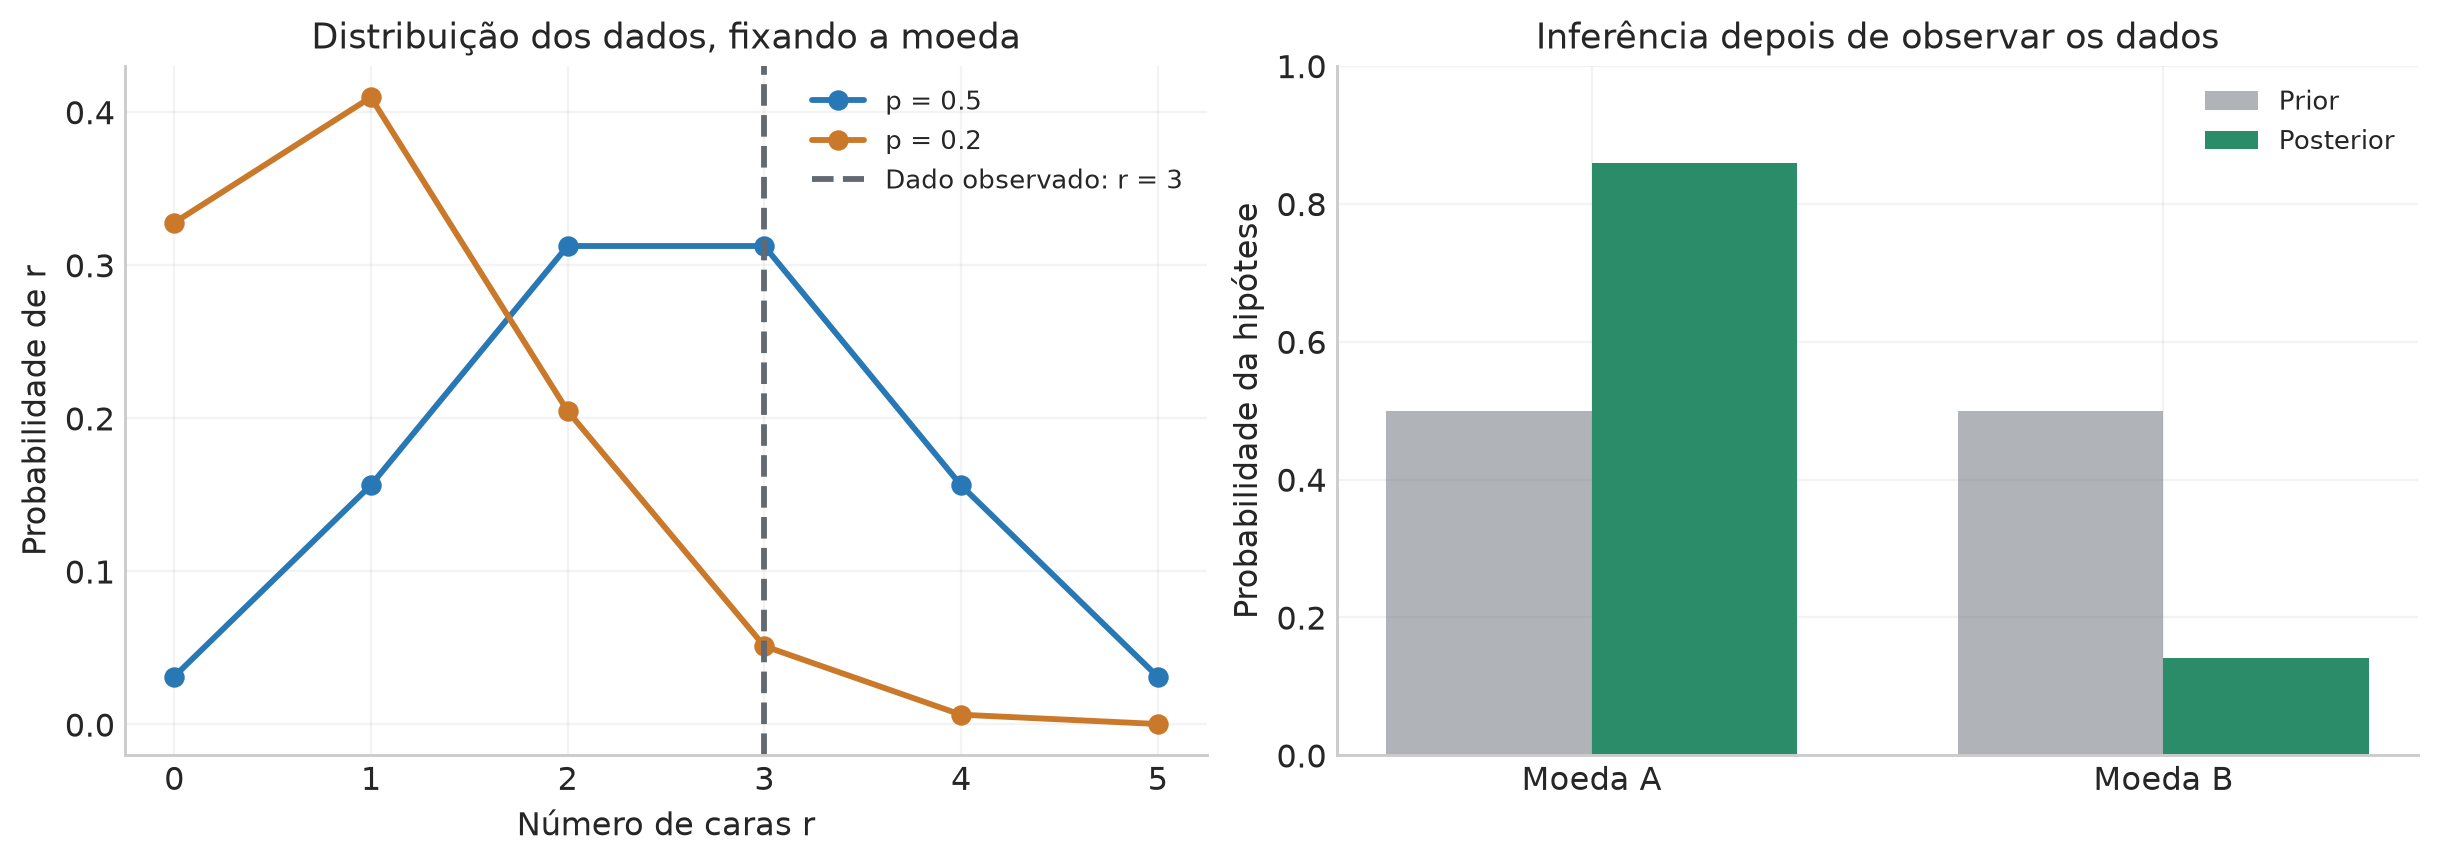

In [2]:
# Três lançamentos: as oito sequências são agrupadas pela contagem de caras.
sequencias = list(product([0, 1], repeat=3))
contagens = np.bincount([sum(seq) for seq in sequencias], minlength=4)
conferir('Multiplicidade binomial por enumeração', contagens, [comb(3, k) for k in range(4)])
tabela(['Caras em 3 lançamentos', 'Sequências possíveis'], list(enumerate(contagens)))

# Agora usamos os dados do exemplo, com priors iguais para as duas hipóteses.
n_moedas, r_moedas = 5, 3
p_moedas = np.array([0.5, 0.2])
prior_moedas = np.array([0.5, 0.5])
like_moedas = binom.pmf(r_moedas, n_moedas, p_moedas)
evidencia_moedas = np.dot(prior_moedas, like_moedas)
post_moedas = prior_moedas * like_moedas / evidencia_moedas
conferir('Posterior das moedas normalizada', post_moedas.sum(), 1)
tabela(['Hipótese', 'Likelihood', 'Prior', 'Posterior'],
       [[h, f'{l:.6f}', f'{pr:.2f}', f'{po:.6f}']
        for h, l, pr, po in zip(['A: p=0.5', 'B: p=0.2'], like_moedas, prior_moedas, post_moedas)])
print(f'Fator de Bayes A/B = {like_moedas[0]/like_moedas[1]:.6f}')

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4), layout='constrained')
k = np.arange(n_moedas+1)
for p, cor in zip(p_moedas, [AZUL, LARANJA]):
    ax[0].plot(k, binom.pmf(k, n_moedas, p), 'o-', color=cor, label=f'p = {p}')
ax[0].axvline(r_moedas, color=CINZA, ls='--', label='Dado observado: r = 3')
ax[0].set(xlabel='Número de caras r', ylabel='Probabilidade de r', title='Distribuição dos dados, fixando a moeda', xticks=k)
ax[0].legend()
xx = np.arange(2)
ax[1].bar(xx-0.18, prior_moedas, 0.36, color=CINZA, alpha=0.5, label='Prior')
ax[1].bar(xx+0.18, post_moedas, 0.36, color=VERDE, label='Posterior')
ax[1].set(xticks=xx, xticklabels=['Moeda A', 'Moeda B'], ylim=(0, 1), ylabel='Probabilidade da hipótese', title='Inferência depois de observar os dados')
ax[1].legend()
mostrar_figura(fig, '01_moedas')

**Interpretação.** Três caras em cinco lançamentos favorecem a moeda A, mas não eliminam B. A probabilidade de aproximadamente $86\%$ depende das priors equiprováveis.

### 1.2 Lei dos grandes números: Limite para muitas ensaios

Definimos $X_i=1$ para cara e $0$ para coroa. Então $R_n=\sum_iX_i$ e $F_n=R_n/n$. A contagem muda com $n$; não estamos mantendo um único $r$ observado fixo enquanto fazemos $n\to\infty$.

Para ensaios iid com probabilidade $p$,
$$\mathbb E[F_n]=p,\qquad \mathrm{Var}(F_n)=\frac{p(1-p)}n.$$
Pela desigualdade de Chebyshev, para qualquer $\varepsilon>0$,
$$P(|F_n-p|\ge\varepsilon)\le\frac{p(1-p)}{n\varepsilon^2}\longrightarrow0.$$
Esta é uma demonstração da **convergência em probabilidade**, a lei fraca. A lei forte estabelece $P(\lim F_n=p)=1$, sob essas hipóteses, mas sua prova exige um argumento adicional. Nenhuma das duas afirma que cada trajetória se aproxima monotonicamente de $p$.

Na própria fórmula binomial, o resultado é
$$\sum_{|k/n-p|\ge\varepsilon}\binom nk p^k(1-p)^{n-k}\longrightarrow0.$$

Vamos reproduzir $p=0.4$ e $n=20,100,1000$ do slide 103. Para comparar com uma densidade, cada probabilidade será dividida pela largura $\Delta f=1/n$: a altura equivalente é $nP(R_n=k)$. **A altura não é uma probabilidade pontual**; a área de cada retângulo é. O segundo painel mostra trajetórias simuladas, enquanto a tabela usa a soma exata da binomial.

| n | Desvio padrão de Fₙ | P(|Fₙ−p| ≥ 0.1), exata | Limite de Chebyshev |
| --- | --- | --- | --- |
| 20 | 0.10954 | 0.494673 | 1 |
| 100 | 0.04899 | 0.051882 | 0.24 |
| 1000 | 0.01549 | 1.3298e-10 | 0.024 |

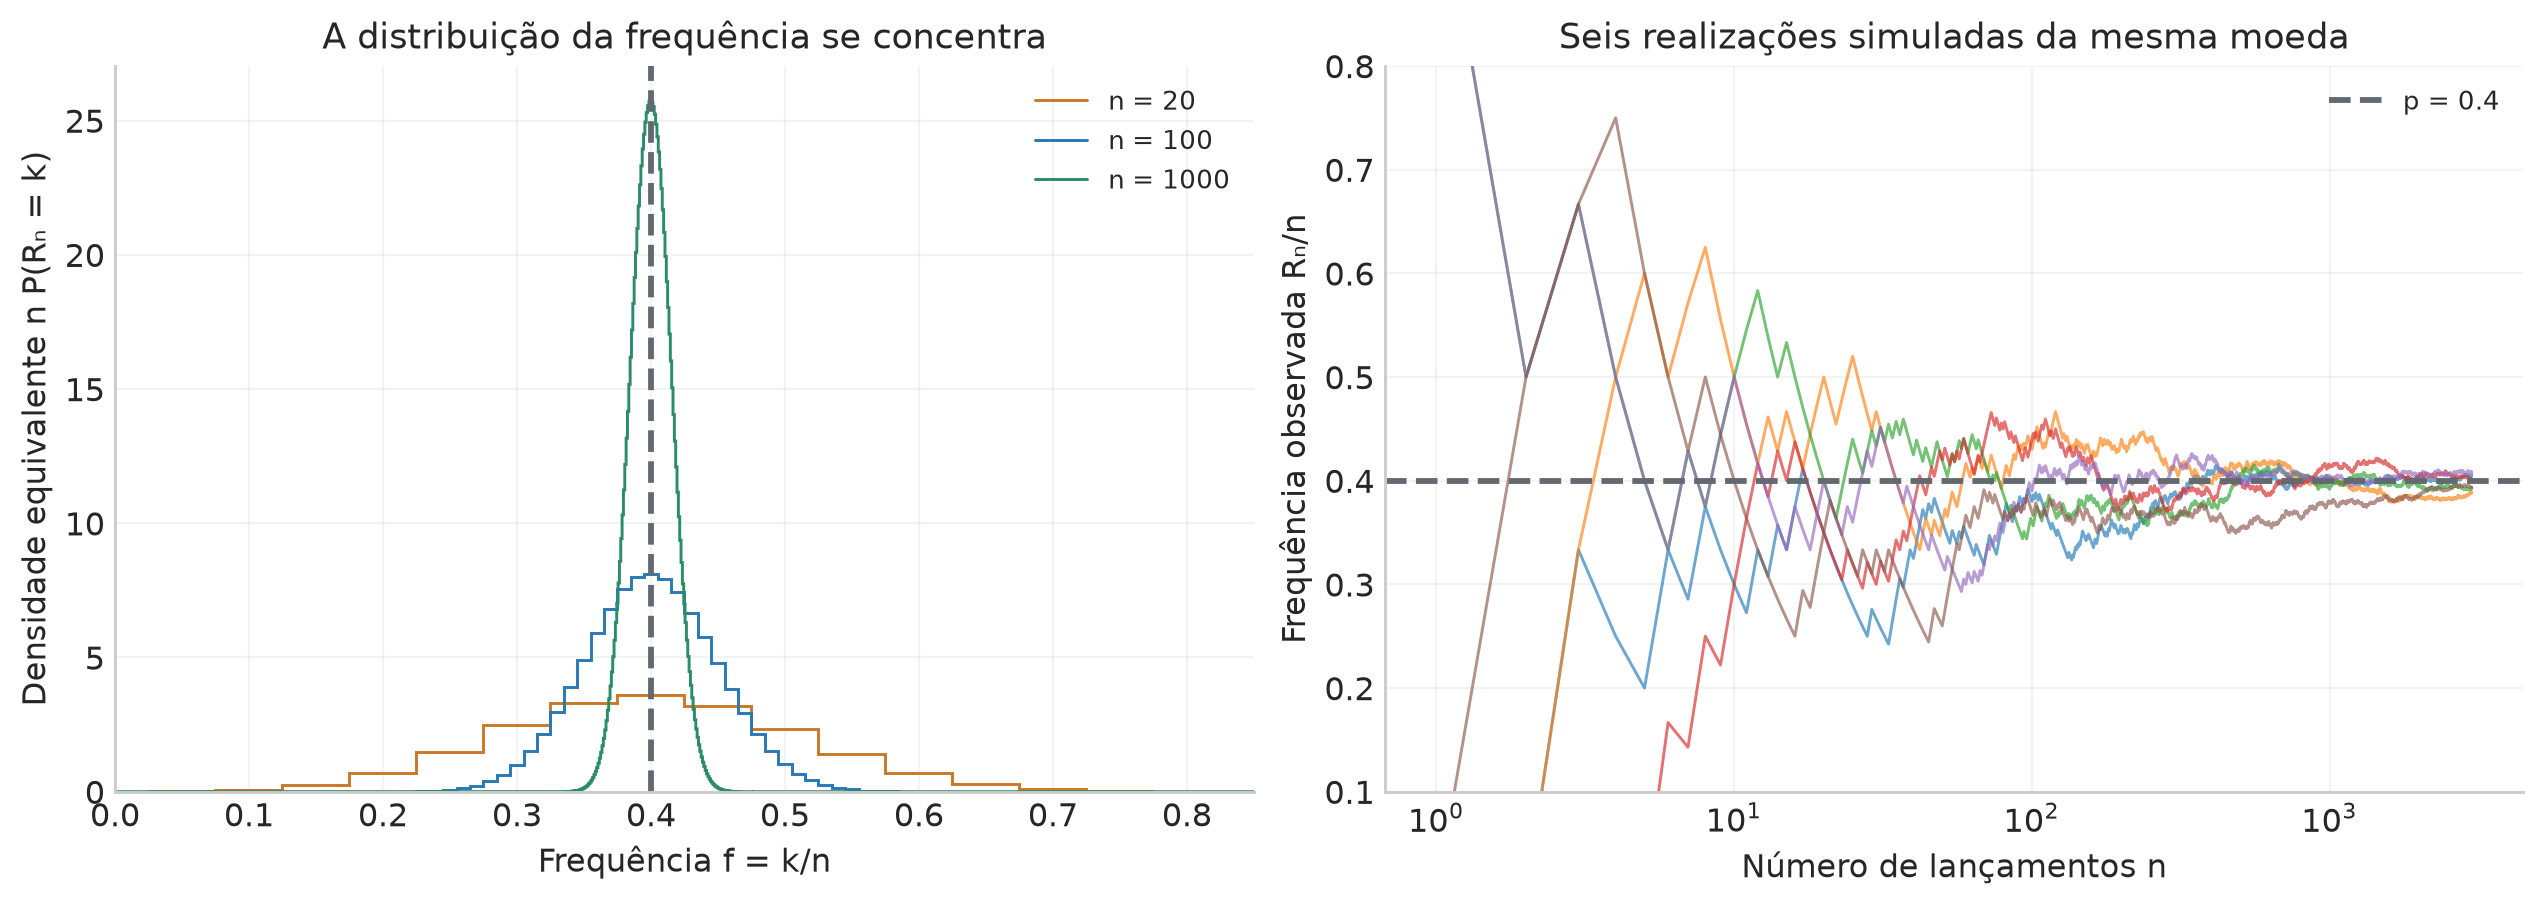

In [3]:
p_lln, tolerancia = 0.4, 0.1
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2), layout='constrained')
linhas = []
for n, cor in zip([20, 100, 1000], [LARANJA, AZUL, VERDE]):
    k = np.arange(n+1)
    massas = binom.pmf(k, n, p_lln)
    # Cada retângulo tem largura 1/n: sua área reproduz a massa discreta.
    bordas = (np.arange(n+2)-0.5)/n
    ax[0].stairs(n*massas, bordas, color=cor, label=f'n = {n}')
    fora = np.abs(k/n-p_lln) >= tolerancia - 1e-12
    prob_fora = massas[fora].sum()
    limite = min(1.0, p_lln*(1-p_lln)/(n*tolerancia**2))
    linhas.append([n, f'{np.sqrt(p_lln*(1-p_lln)/n):.5f}', f'{prob_fora:.6g}', f'{limite:.6g}'])
    conferir(f'Normalização binomial n={n}', massas.sum(), 1)
ax[0].axvline(p_lln, color=CINZA, ls='--')
ax[0].set(xlim=(0, 0.85), xlabel='Frequência f = k/n', ylabel='Densidade equivalente n P(Rₙ = k)', title='A distribuição da frequência se concentra')
ax[0].legend()

rng_lln = np.random.default_rng(SEMENTE+1)
ensaios = rng_lln.binomial(1, p_lln, size=(6, 3000))
n_traj = np.arange(1, ensaios.shape[1]+1)
frequencias = np.cumsum(ensaios, axis=1)/n_traj
for traj in frequencias:
    ax[1].plot(n_traj, traj, alpha=0.65, lw=1)
ax[1].axhline(p_lln, color=CINZA, ls='--', label='p = 0.4')
ax[1].set(xscale='log', ylim=(0.1, 0.8), xlabel='Número de lançamentos n', ylabel='Frequência observada Rₙ/n', title='Seis realizações simuladas da mesma moeda')
ax[1].legend()
tabela(['n', 'Desvio padrão de Fₙ', 'P(|Fₙ−p| ≥ 0.1), exata', 'Limite de Chebyshev'], linhas)
mostrar_figura(fig, '02_grandes_numeros')

### 1.3 Moeda do jogador: agora com o parâmetro desconhecido

**Slides 104–105 / Gregory §4.2.2.** Os dados acumulados são $(n,r)=(3,2),(10,7),(50,33)$. Fixamos cada conjunto observado e inferimos o viés $p$. Com prior uniforme em $[0,1]$,

$$\pi(p\mid r,n)=\frac{p^r(1-p)^{n-r}}{B(r+1,n-r+1)}=\mathrm{Beta}(p;r+1,n-r+1).$$

Para uma prior $\mathrm{Beta}(\alpha,\beta)$, a atualização geral é $\mathrm{Beta}(\alpha+r,\beta+n-r)$. O coeficiente $\binom nr$ é constante em $p$ e cancela na normalização da posterior. A média posterior e a previsão para o próximo lançamento são
$$\mathbb E[p\mid D]=P(\text{próxima cara}\mid D)=\frac{r+1}{n+2}.$$

A moda interior, nesse caso, é $r/n$. A previsão usa a média porque marginalizamos o parâmetro: $P(Q_{n+1}\mid D)=\int_0^1 p\,\pi(p\mid D)dp$.

**Cuidado com os dados acumulados.** A segunda atualização deve acrescentar 5 caras em 7 novos lançamentos; a terceira, 26 em 40. Multiplicar três likelihoods dos conjuntos acumulados contaria dados anteriores repetidamente. Vamos conferir a atualização por incrementos.

| n | r | Moda r/n | Média / previsão de cara | IC central de 95% |
| --- | --- | --- | --- | --- |
| 3 | 2 | 0.6667 | 0.6000 | [0.1941, 0.9324] |
| 10 | 7 | 0.7000 | 0.6667 | [0.3903, 0.8907] |
| 50 | 33 | 0.6600 | 0.6538 | [0.5208, 0.7757] |

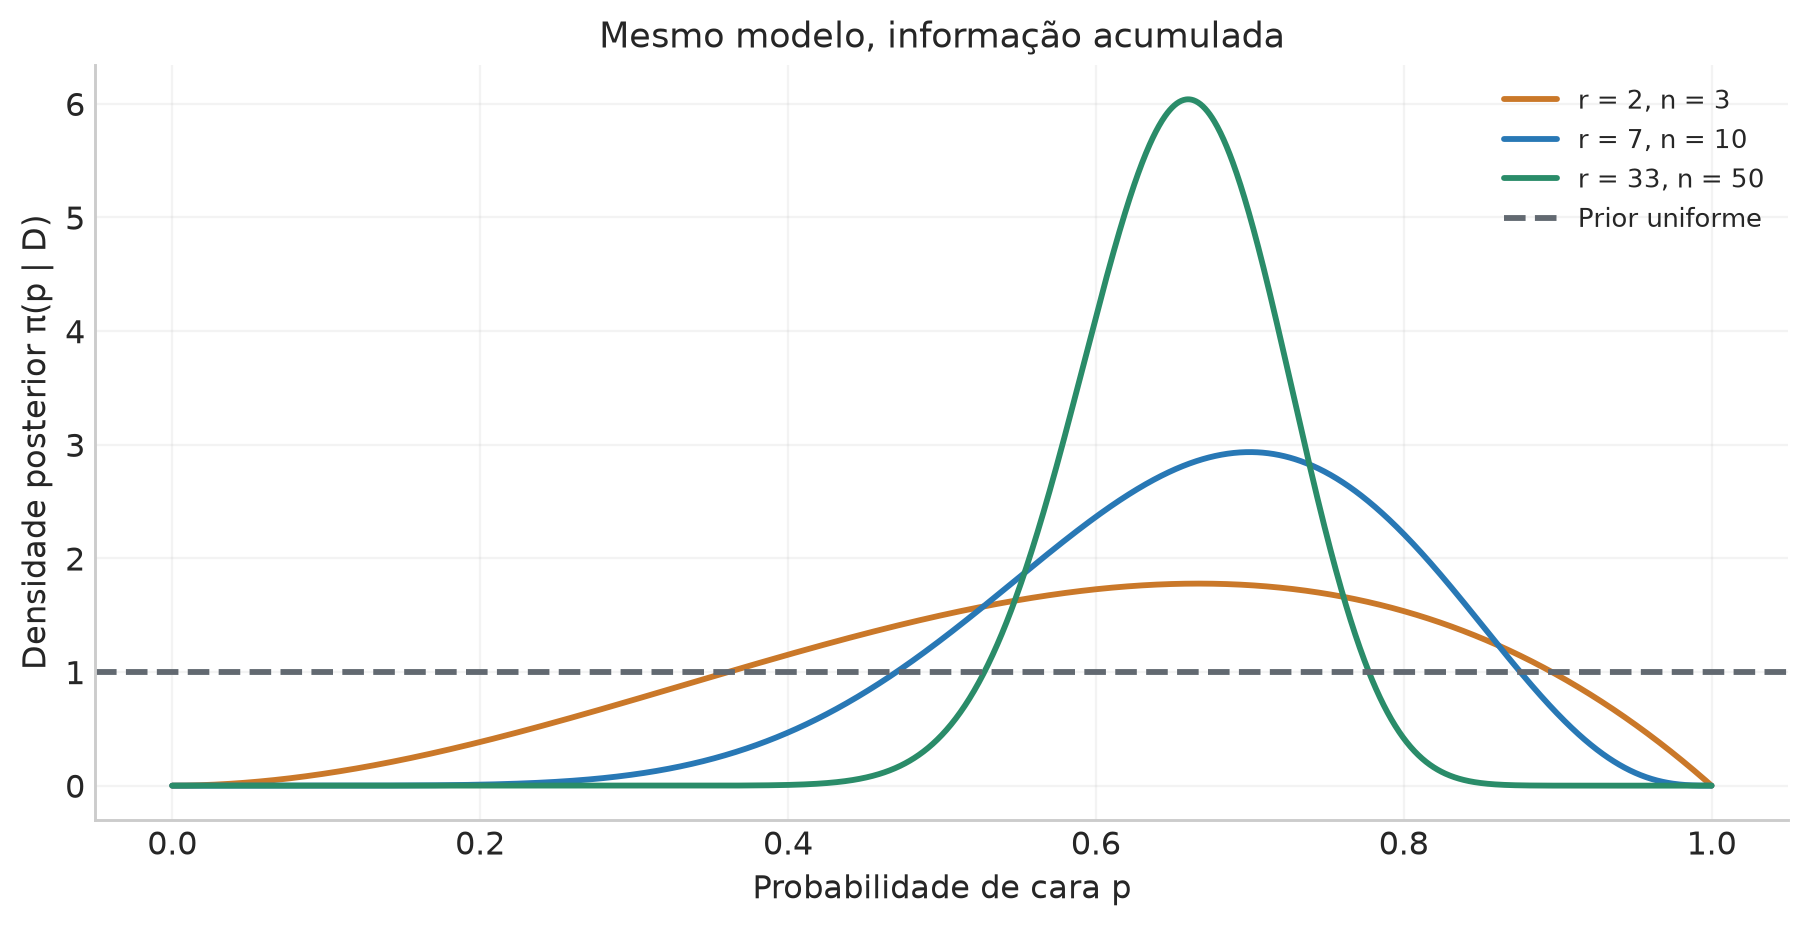

In [4]:
p_grade = np.linspace(0, 1, 2001)
dados_moeda = [(3, 2), (10, 7), (50, 33)]
fig, ax = plt.subplots(figsize=(8.5, 4.3), layout='constrained')
linhas = []
a_seq, b_seq, n_ant, r_ant = 1, 1, 0, 0
for (n, r), cor in zip(dados_moeda, [LARANJA, AZUL, VERDE]):
    a_seq += r-r_ant
    b_seq += (n-n_ant)-(r-r_ant)
    conferir(f'Atualização sequencial da moeda até n={n}', [a_seq, b_seq], [r+1, n-r+1])
    post = beta(a_seq, b_seq)
    lo, hi = post.ppf([0.025, 0.975])
    linhas.append([n, r, f'{r/n:.4f}', f'{post.mean():.4f}', f'[{lo:.4f}, {hi:.4f}]'])
    ax.plot(p_grade, post.pdf(p_grade), color=cor, label=f'r = {r}, n = {n}')
    n_ant, r_ant = n, r
ax.axhline(1, color=CINZA, ls='--', label='Prior uniforme')
ax.set(xlabel='Probabilidade de cara p', ylabel='Densidade posterior π(p | D)', title='Mesmo modelo, informação acumulada')
ax.legend()
tabela(['n', 'r', 'Moda r/n', 'Média / previsão de cara', 'IC central de 95%'], linhas)
mostrar_figura(fig, '03_moeda_jogador')

**Interpretação.** No gráfico dos grandes números, fixamos $p=0.4$ e variamos os resultados possíveis. Aqui, os dados ficam fixos e variamos $p$. São distribuições em espaços diferentes. O estreitamento da posterior representa informação sobre o parâmetro; não demonstra que a moeda se tornou fisicamente menos aleatória.


### 1.4 Pesquisa eleitoral: uma pergunta sobre a posterior

**Slides 106–107 / Gregory §4.2.3.** Entre 800 eleitores decididos, 18% apoiam A, 55% B, 19% C e 8% outros. Para a pergunta sobre B, agrupamos as demais respostas: $r_B=440$, $n-r_B=360$. Chamamos de $p_B$ a fração de apoio à legenda na população sob o modelo de amostragem.

Com prior uniforme para $p_B$,
$$\pi(p_B\mid D)=\mathrm{Beta}(441,361),$$
$$P(p_B\ge0.51\mid D)=\int_{0.51}^1\pi(p_B\mid D)\,dp_B.$$

Usamos a função de sobrevivência para calcular a cauda sem subtrair números muito próximos de 1. O modelo supõe amostragem representativa e ensaios aproximadamente independentes. A posterior não inclui automaticamente não resposta, desenho amostral, mudanças de preferência ou participação eleitoral. Portanto, a probabilidade calculada é sobre $p_B$ no modelo, não uma previsão completa da eleição futura.

| Quantidade | Valor |
| --- | --- |
| P(p_B ≥ 0.51 | D) | 0.98818270 (98.8183%) |
| Média posterior | 0.549875 |
| IC central de 95% | [0.515356, 0.584159] |

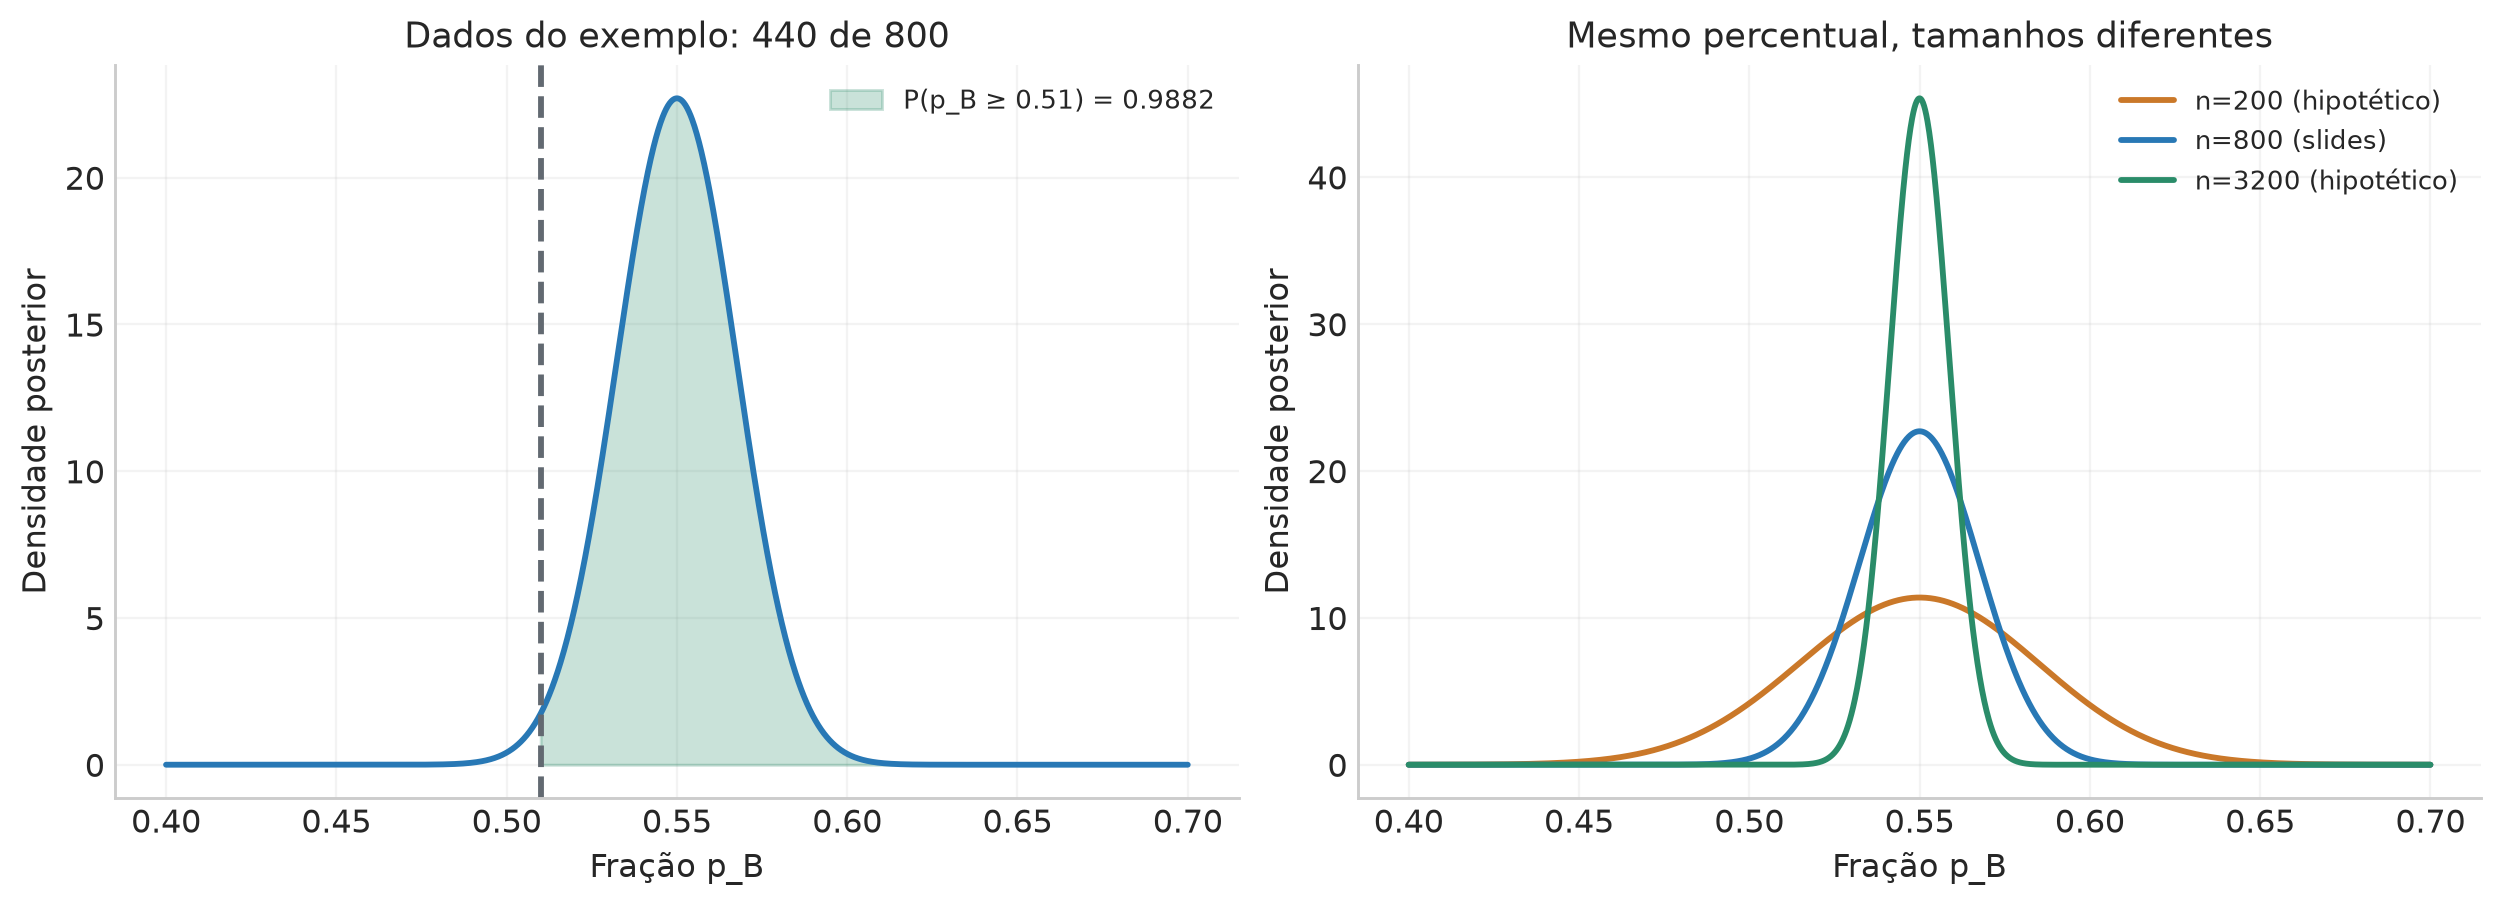

In [5]:
n_eleicao, r_eleicao = 800, 440
post_eleicao = beta(r_eleicao+1, n_eleicao-r_eleicao+1)
prob_51 = post_eleicao.sf(0.51)
cauda_quad = quad(post_eleicao.pdf, 0.51, 1, epsabs=1e-11)[0]
conferir('Cauda eleitoral: função de sobrevivência versus integral', prob_51, cauda_quad)
lo, hi = post_eleicao.ppf([0.025, 0.975])
tabela(['Quantidade', 'Valor'], [
    ['P(p_B ≥ 0.51 | D)', f'{prob_51:.8f} ({100*prob_51:.4f}%)'],
    ['Média posterior', f'{post_eleicao.mean():.6f}'],
    ['IC central de 95%', f'[{lo:.6f}, {hi:.6f}]'],
])

fig, ax = plt.subplots(1, 2, figsize=(11.8, 4.2), layout='constrained')
pg = np.linspace(0.40, 0.70, 1801)
ax[0].plot(pg, post_eleicao.pdf(pg), color=AZUL)
ax[0].fill_between(pg, post_eleicao.pdf(pg), where=pg>=0.51, color=VERDE, alpha=0.25, label=f'P(p_B ≥ 0.51) = {prob_51:.4f}')
ax[0].axvline(0.51, color=CINZA, ls='--')
ax[0].set(xlabel='Fração p_B', ylabel='Densidade posterior', title='Dados do exemplo: 440 de 800')
ax[0].legend()
for n, cor in zip([200, 800, 3200], [LARANJA, AZUL, VERDE]):
    # Somente n=800 é o dado dos slides. Os outros dois são cenários hipotéticos.
    r = round(0.55*n)
    etiqueta = f'n={n}' + (' (slides)' if n==800 else ' (hipotético)')
    ax[1].plot(pg, beta.pdf(pg, r+1, n-r+1), color=cor, label=etiqueta)
ax[1].set(xlabel='Fração p_B', ylabel='Densidade posterior', title='Mesmo percentual, tamanhos diferentes')
ax[1].legend()
mostrar_figura(fig, '04_pesquisa_eleitoral')

### 1.5 Multinomial: mais categorias e um total fixo

Agora mantemos as quatro categorias da pesquisa. Se $N_j$ conta respostas da categoria $j$, com probabilidades $p_j$ constantes e ensaios independentes,
$$P(N_1=n_1,\ldots,N_s=n_s\mid n,\mathbf p)
=\frac{n!}{\prod_j n_j!}\prod_jp_j^{n_j},\quad \sum_jn_j=n,\quad\sum_jp_j=1.$$

As contagens não são independentes entre si: o total está fixo. Podemos derivar os momentos somando indicadores $I_{aj}$, que valem 1 quando a resposta $a$ pertence à categoria $j$. Para uma mesma resposta, $I_{aj}I_{ak}=0$ se $j\ne k$. Assim,
$$\mathbb E[N_j]=np_j,\qquad \mathrm{Cov}(N_j,N_k)=n(p_j\delta_{jk}-p_jp_k).$$

Observe a diferença: independência entre **ensaios** não implica independência entre **totais por categoria**. Além disso, a marginal de uma categoria é binomial: $N_j\sim\mathrm{Binomial}(n,p_j)$.

Usaremos $\mathbf p=(0.18,0.55,0.19,0.08)$ como hipótese ilustrativa, não como valor verdadeiro conhecido da população. A figura conjunta usa $n=20$ para tornar as contagens visíveis; a tabela de likelihood usa as 800 respostas dos slides.

Se fizéssemos inferência conjunta com prior $\mathrm{Dirichlet}(1,1,1,1)$, a prior marginal de $p_B$ seria $\mathrm{Beta}(1,3)$, não a uniforme da seção anterior. Priors uniformes em espaços diferentes não precisam ter as mesmas marginais. Não misturaremos essas duas escolhas.

Log-probabilidade do vetor observado, fixando p = [0.18 0.55 0.19 0.08]: -9.536700


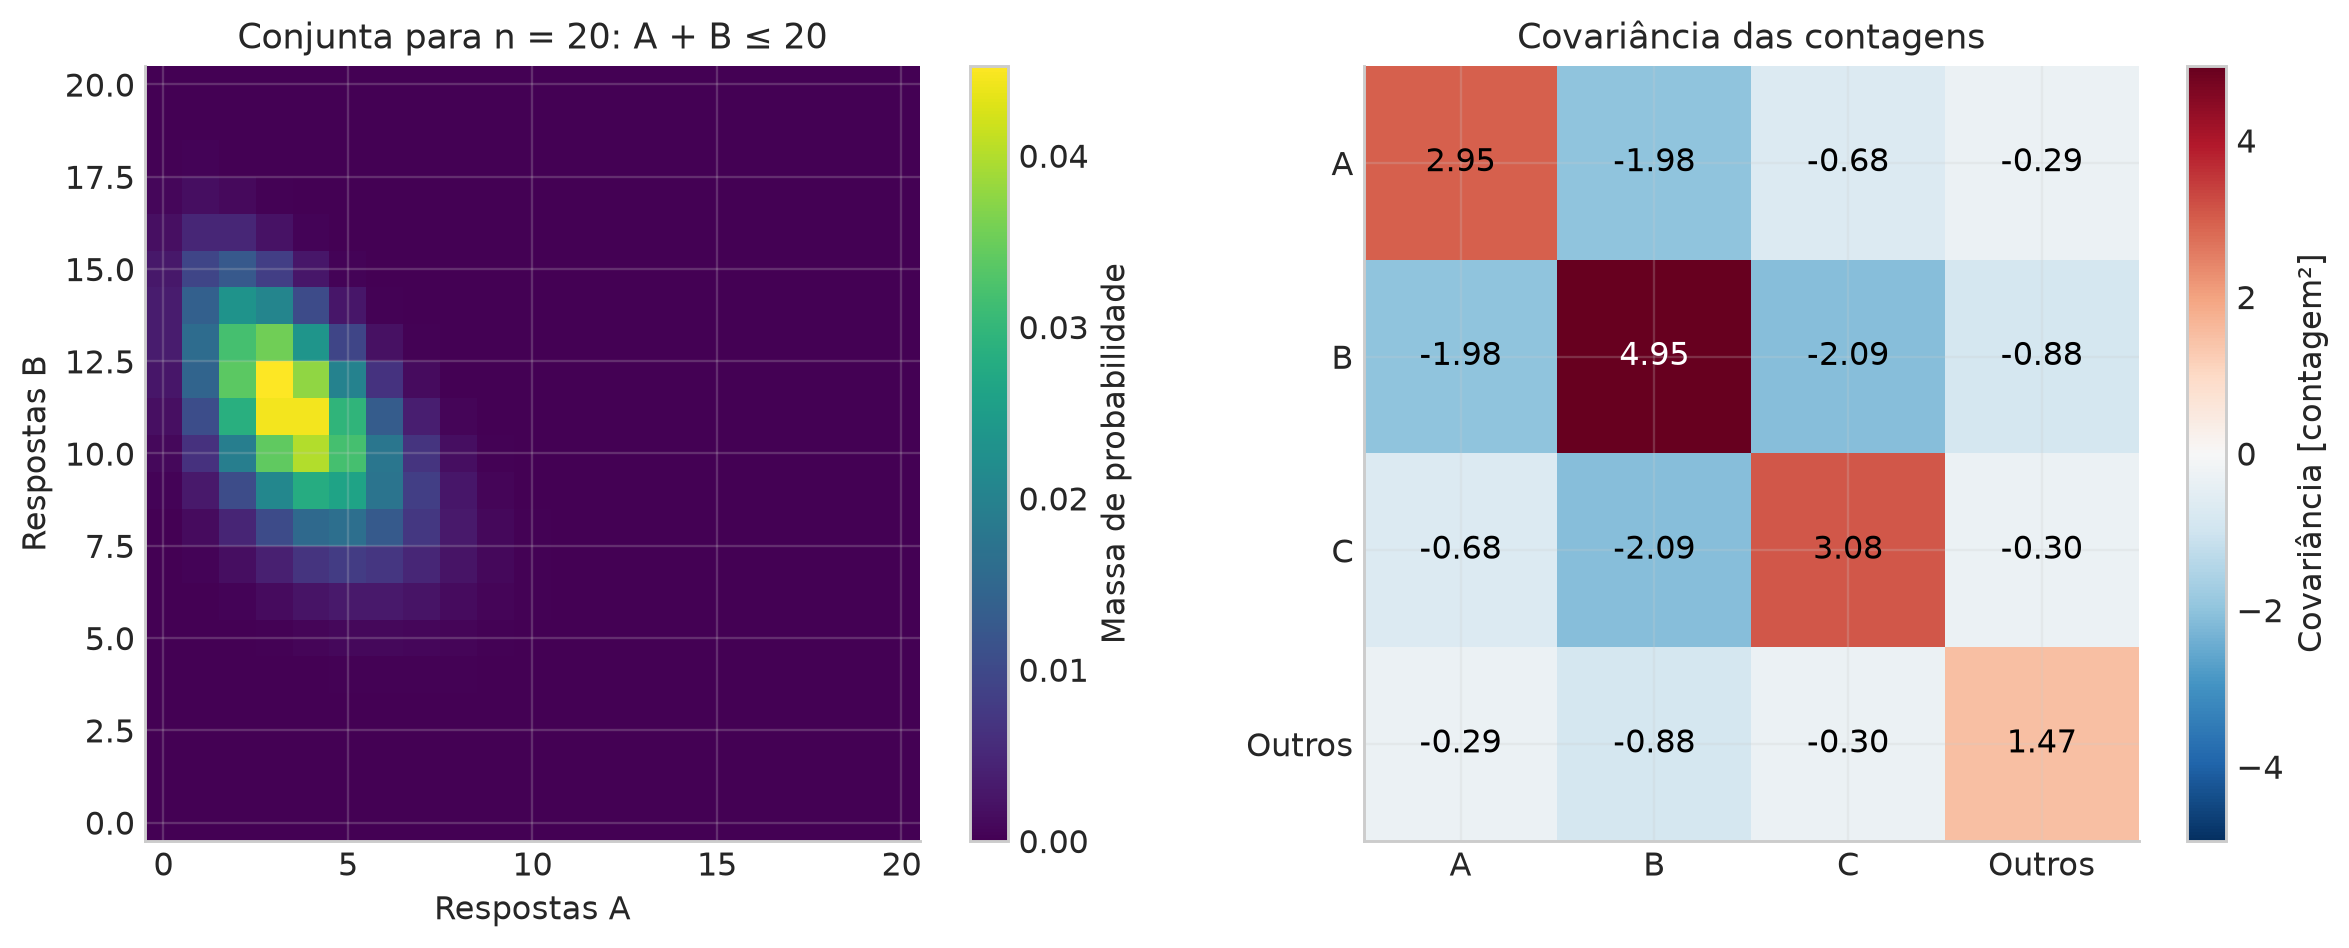

In [6]:
p_cat = np.array([0.18, 0.55, 0.19, 0.08])
rot_cat = ['A', 'B', 'C', 'Outros']
contagem_eleicao = np.array([144, 440, 152, 64])
log_prob_mult = (gammaln(801)-np.sum(gammaln(contagem_eleicao+1))
                 +np.dot(contagem_eleicao, np.log(p_cat)))
conferir('Multinomial por log-fatoriais versus SciPy', log_prob_mult,
         multinomial.logpmf(contagem_eleicao, 800, p_cat))
print(f'Log-probabilidade do vetor observado, fixando p = {p_cat}: {log_prob_mult:.6f}')

# O terceiro grupo reúne C e Outros. Somamos sobre a composição interna desse grupo.
n_mult = 20
na, nb = np.meshgrid(np.arange(n_mult+1), np.arange(n_mult+1))
nc_rest = n_mult-na-nb
valido = nc_rest >= 0
joint_ab = np.zeros_like(na, dtype=float)
vetores = np.column_stack([na[valido], nb[valido], nc_rest[valido]])
joint_ab[valido] = multinomial.pmf(vetores, n_mult, [p_cat[0], p_cat[1], p_cat[2:].sum()])
conferir('Conjunta multinomial normalizada', joint_ab.sum(), 1)
conferir('Marginal multinomial de B é binomial', joint_ab.sum(axis=1), binom.pmf(np.arange(n_mult+1), n_mult, p_cat[1]))
cov_mult = n_mult*(np.diag(p_cat)-np.outer(p_cat, p_cat))
conferir('Soma das contagens é fixa: covariância vezes vetor 1', cov_mult@np.ones(4), np.zeros(4))

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.4), layout='constrained')
im = ax[0].imshow(joint_ab, origin='lower', extent=(-0.5, 20.5, -0.5, 20.5), cmap='viridis', aspect='equal')
ax[0].set(xlabel='Respostas A', ylabel='Respostas B', title='Conjunta para n = 20: A + B ≤ 20')
fig.colorbar(im, ax=ax[0], label='Massa de probabilidade')
vmax = np.max(np.abs(cov_mult))
im2 = ax[1].imshow(cov_mult, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax[1].set(xticks=range(4), yticks=range(4), xticklabels=rot_cat, yticklabels=rot_cat, title='Covariância das contagens')
for i in range(4):
    for j in range(4):
        ax[1].text(j, i, f'{cov_mult[i,j]:.2f}', ha='center', va='center', color='white' if abs(cov_mult[i,j])>0.65*vmax else 'black')
fig.colorbar(im2, ax=ax[1], label='Covariância [contagem²]')
mostrar_figura(fig, '05_multinomial')

### 1.6 Urna, intercambiabilidade e limite hipergeométrica → binomial

**Slides 110–113 / Gregory §§4.4–4.6.** Uma urna possui $N$ objetos, $M$ pretos e $N-M$ brancos; todas as retiradas são uniformes e sem reposição. Escrevemos $Q_i$ para “o objeto da posição $i$ é preto”.

$$P(Q_i\mid I)=\frac MN,\qquad P(\overline Q_i\mid I)=\frac{N-M}{N}.$$
Se sabemos que o primeiro foi preto, $P(Q_2\mid Q_1,I)=(M-1)/(N-1)$. Se não sabemos sua cor, precisamos somar as duas possibilidades:
$$P(Q_2\mid I)=\frac MN\frac{M-1}{N-1}+\frac{N-M}{N}\frac M{N-1}=\frac MN.$$

**Intercambiabilidade** significa invariância da probabilidade conjunta por permutação dos resultados. Para a urna, sequências com as mesmas contagens têm a mesma probabilidade, mesmo que as retiradas sejam dependentes. O resultado é simétrico também na atualização:
$$P(Q_i\mid Q_j,I)=P(Q_j\mid Q_i,I)=\frac{M-1}{N-1},\quad i\ne j.$$
A descoberta de um resultado posterior muda o que sabemos sobre o anterior; não modifica fisicamente o passado. A ordem em que recebemos a informação não precisa coincidir com a ordem temporal dos eventos.

Para $K$ pretos em $n$ retiradas,
$$P(K=k\mid N,M,n)=\frac{\binom Mk\binom{N-M}{n-k}}{\binom Nn},$$
com $\max(0,n-N+M)\le k\le\min(n,M)$. O numerador conta amostras favoráveis e o denominador todas as amostras não ordenadas.

Para demonstrar o limite, introduzimos $(a)_{\underline j}=a(a-1)\cdots(a-j+1)$:
$$P(K=k)=\binom nk\frac{(M)_{\underline k}(N-M)_{\underline{n-k}}}{(N)_{\underline n}}$$
$$=\binom nk\frac{\prod_{a=0}^{k-1}(M/N-a/N)\prod_{b=0}^{n-k-1}(1-M/N-b/N)}{\prod_{c=0}^{n-1}(1-c/N)}.$$
Mantendo $n$ fixo e tomando $N\to\infty$ com $M/N\to p$, cada fator tende a $p$, $1-p$ ou 1. Portanto,
$$\boxed{P(K=k)\longrightarrow\binom nk p^k(1-p)^{n-k}.}$$

Não basta dizer “$N$ cresce”: se $M$ ficar fixo, $p\to0$. Para uma amostra pequena diante da população, a retirada altera pouco a composição, aproximando a situação com reposição. A variância quantifica isso:
$$\mathrm{Var}(K)=np(1-p)\frac{N-n}{N-1}.$$

| Informação disponível | Probabilidade de preto |
| --- | --- |
| Nenhum outro resultado conhecido | 0.400000 |
| Outra posição conhecida como preta | 0.333333 |
| Outra posição conhecida como branca | 0.444444 |

| N | M | Fração amostrada n/N | Variância exata | Distância à binomial (TV) |
| --- | --- | --- | --- | --- |
| 20 | 8 | 0.600 | 1.212632 | 0.216081 |
| 50 | 20 | 0.240 | 2.233469 | 0.066708 |
| 200 | 80 | 0.060 | 2.720804 | 0.014995 |
| 2000 | 800 | 0.006 | 2.864152 | 0.001456 |

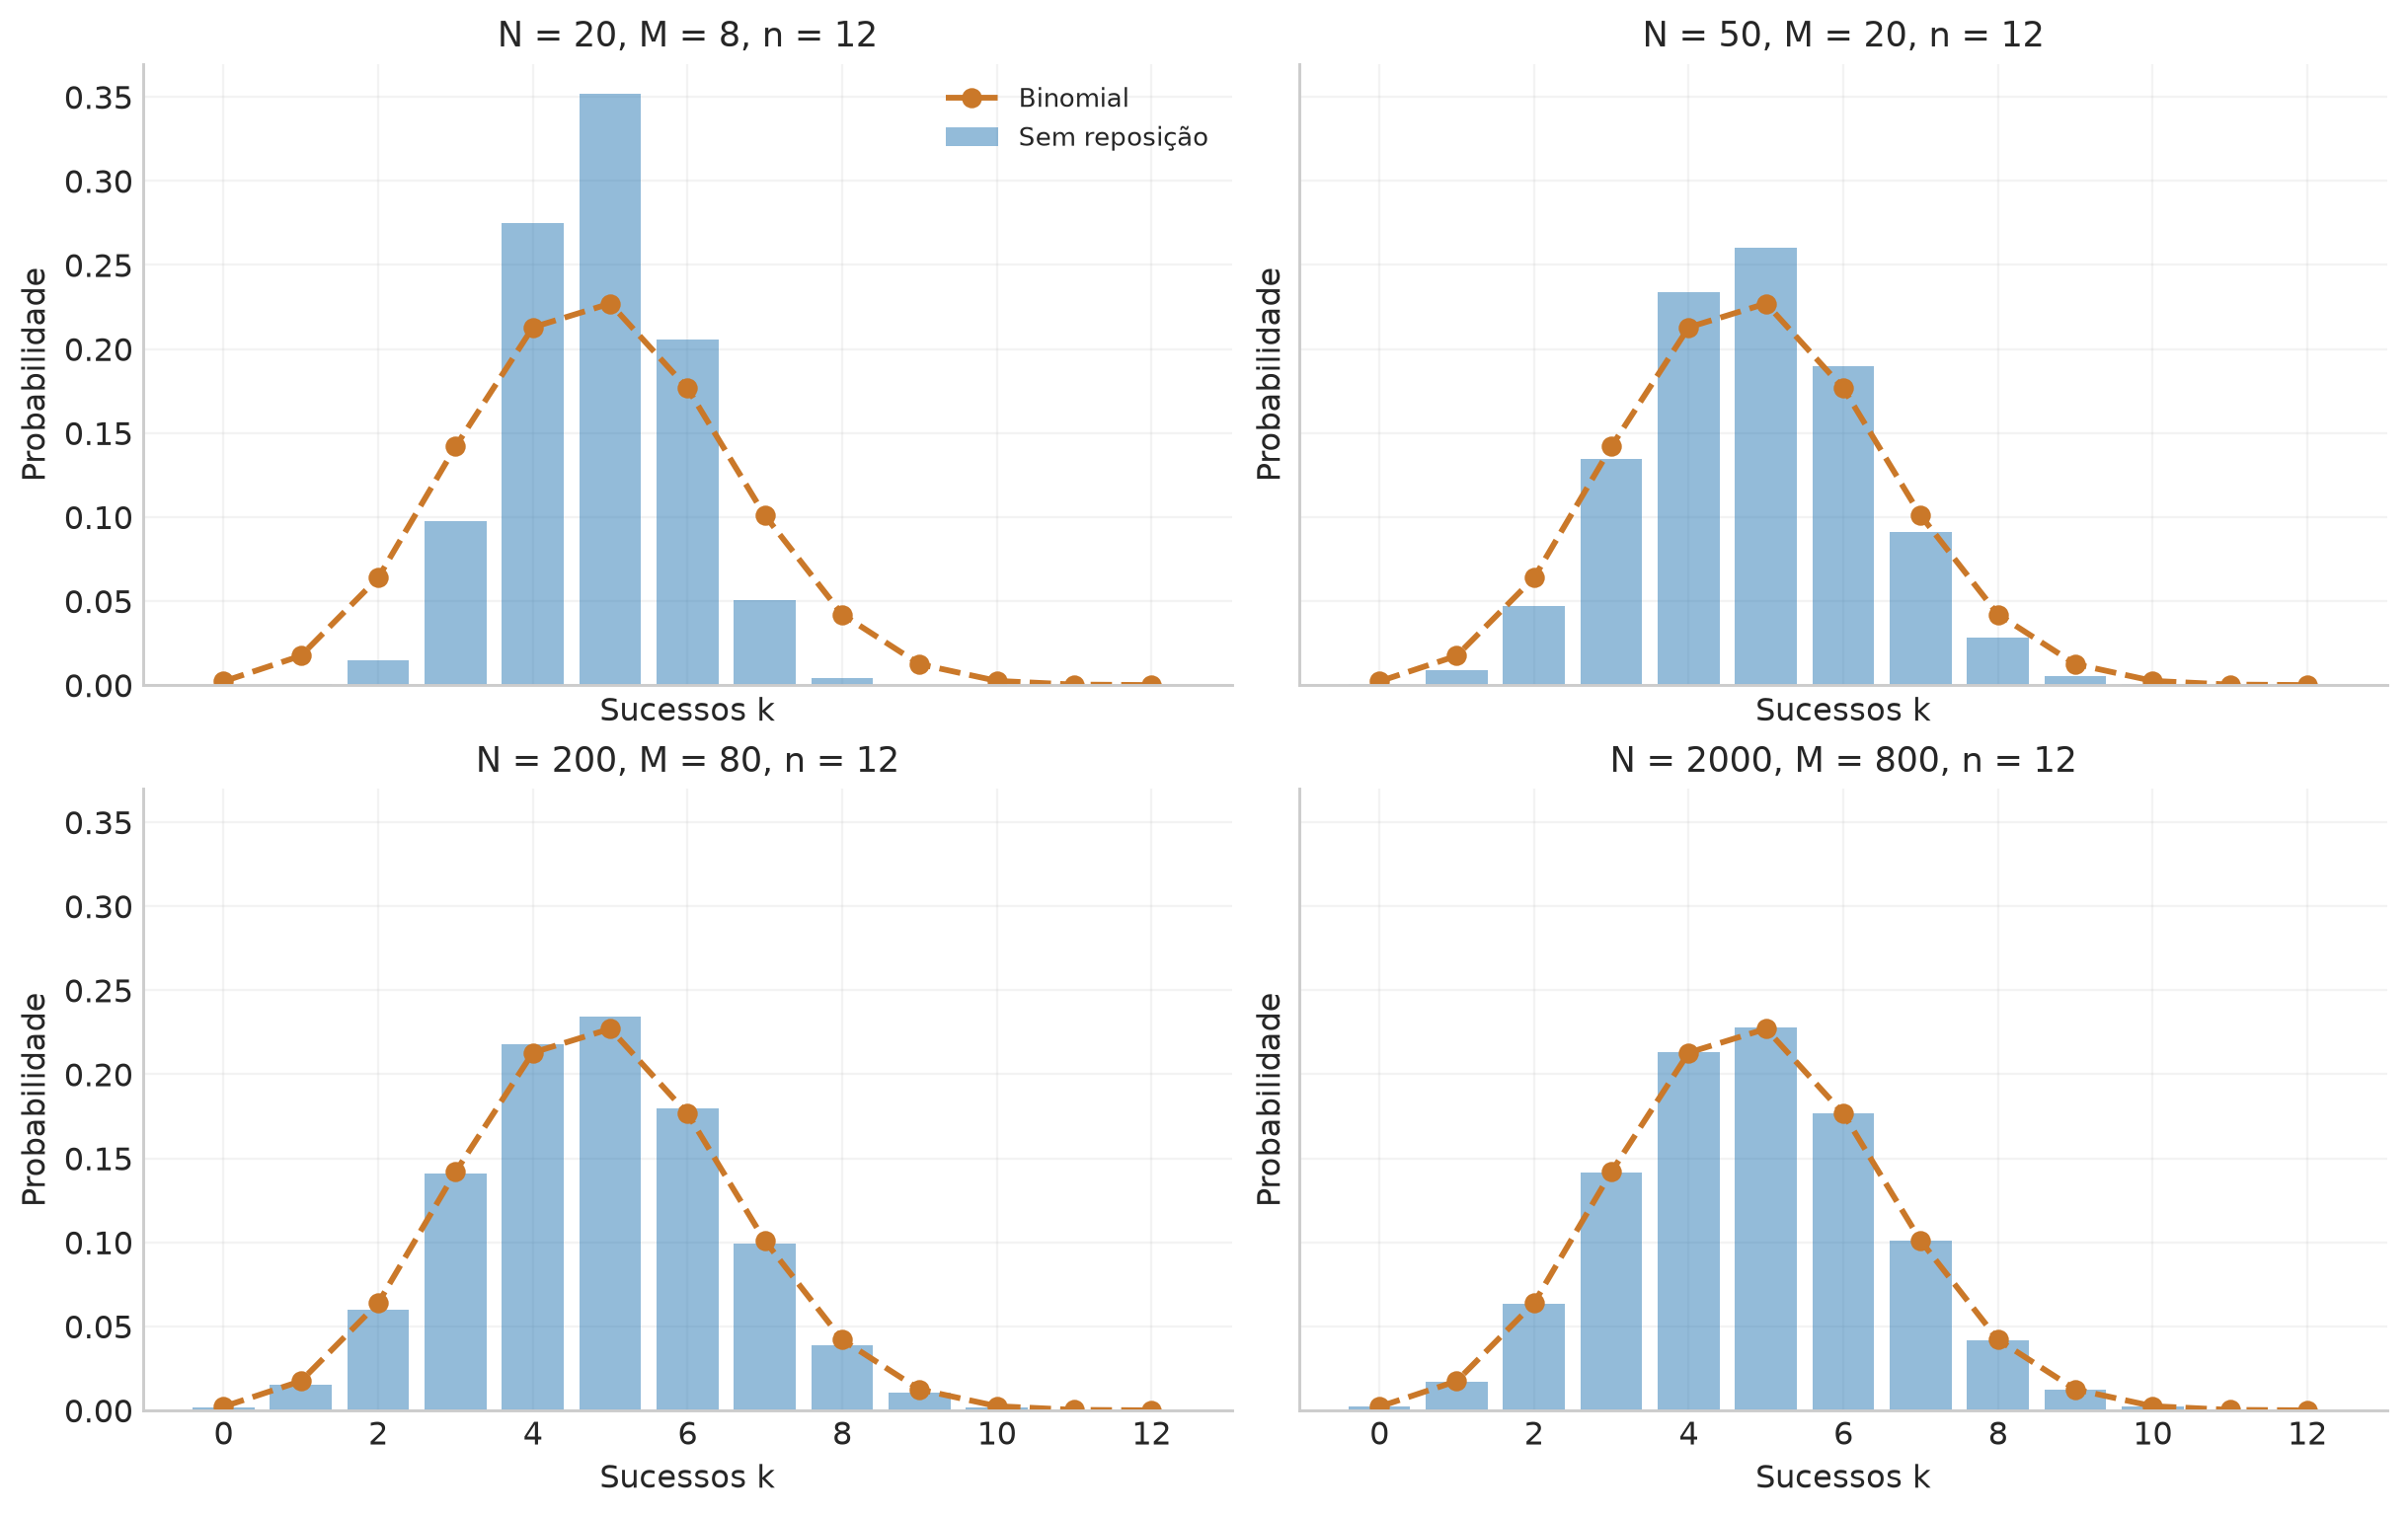

In [7]:
# Conferência da soma sobre a cor desconhecida da primeira retirada.
N_urna, M_urna = 10, 4
p_preto = M_urna/N_urna
p_segundo = p_preto*(M_urna-1)/(N_urna-1)+(1-p_preto)*M_urna/(N_urna-1)
conferir('Marginalização na urna', p_segundo, p_preto)
tabela(['Informação disponível', 'Probabilidade de preto'], [
    ['Nenhum outro resultado conhecido', f'{p_preto:.6f}'],
    ['Outra posição conhecida como preta', f'{(M_urna-1)/(N_urna-1):.6f}'],
    ['Outra posição conhecida como branca', f'{M_urna/(N_urna-1):.6f}'],
])

n_hiper, p_hiper = 12, 0.4
k = np.arange(n_hiper+1)
pmf_bin_ref = binom.pmf(k, n_hiper, p_hiper)
fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.2), sharex=True, sharey=True, layout='constrained')
linhas = []
for ax, N in zip(axes.flat, [20, 50, 200, 2000]):
    M = round(p_hiper*N)
    pmf_h = hypergeom.pmf(k, N, M, n_hiper)
    # Variação total: metade da soma das diferenças absolutas entre massas.
    tv = 0.5*np.abs(pmf_h-pmf_bin_ref).sum()
    var_h = n_hiper*p_hiper*(1-p_hiper)*(N-n_hiper)/(N-1)
    conferir(f'Variância hipergeométrica N={N}', hypergeom.var(N, M, n_hiper), var_h)
    linhas.append([N, M, f'{n_hiper/N:.3f}', f'{var_h:.6f}', f'{tv:.6f}'])
    ax.bar(k, pmf_h, color=AZUL, alpha=0.5, label='Sem reposição')
    ax.plot(k, pmf_bin_ref, 'o--', color=LARANJA, label='Binomial')
    ax.set(title=f'N = {N}, M = {M}, n = {n_hiper}', xlabel='Sucessos k', ylabel='Probabilidade')
axes[0, 0].legend()
tabela(['N', 'M', 'Fração amostrada n/N', 'Variância exata', 'Distância à binomial (TV)'], linhas)
mostrar_figura(fig, '06_hipergeometrica_binomial')

**Interpretação.** A amostragem sem reposição restringe flutuações: observar muitos pretos esgota essa parte da urna. Quando $n/N$ é pequeno, o fator de população finita se aproxima de 1 e essa restrição se torna pouco perceptível. A aproximação não exige que as retiradas se tornem exatamente independentes para um $N$ finito.

### 1.7 Astronautas: informação posterior e eventos compostos

**Slides 114–115 / Gregory §4.6.** Existem duas astronautas e três astronautas homens. Sorteamos, sem reposição, capitão e dois integrantes do apoio. Queremos $P(F_1\mid F_2\cup F_3)$, onde $F_i$ indica uma mulher na posição $i$. A informação é “pelo menos uma mulher no apoio”, não “uma integrante específica foi identificada como mulher”.

Chamando esse evento de $L$,
$$P(F_1)=\frac25,\qquad P(L\mid F_1)=1-\frac34\frac23=\frac12,$$
$$P(L)=1-P(\overline F_2,\overline F_3)=1-\frac35\frac24=\frac7{10}.$$
Logo,
$$\boxed{P(F_1\mid L)=\frac{(2/5)(1/2)}{7/10}=\frac27.}$$
Os três postos geram $5\times4\times3=60$ sorteios ordenados equiprováveis. Vamos enumerá-los para conferir Bayes. Contar apenas padrões F/M sem ponderação daria uma resposta errada, porque esses padrões não são equiprováveis.

| Pergunta | Resultado |
| --- | --- |
| P(capitã) | 2/5 = 0.400000 |
| P(capitã | mulher na posição 2) | 1/4 = 0.250000 |
| P(capitã | pelo menos uma mulher no apoio) | 2/7 = 0.285714 |
| Sorteios compatíveis com a informação / total | 42 / 60 |

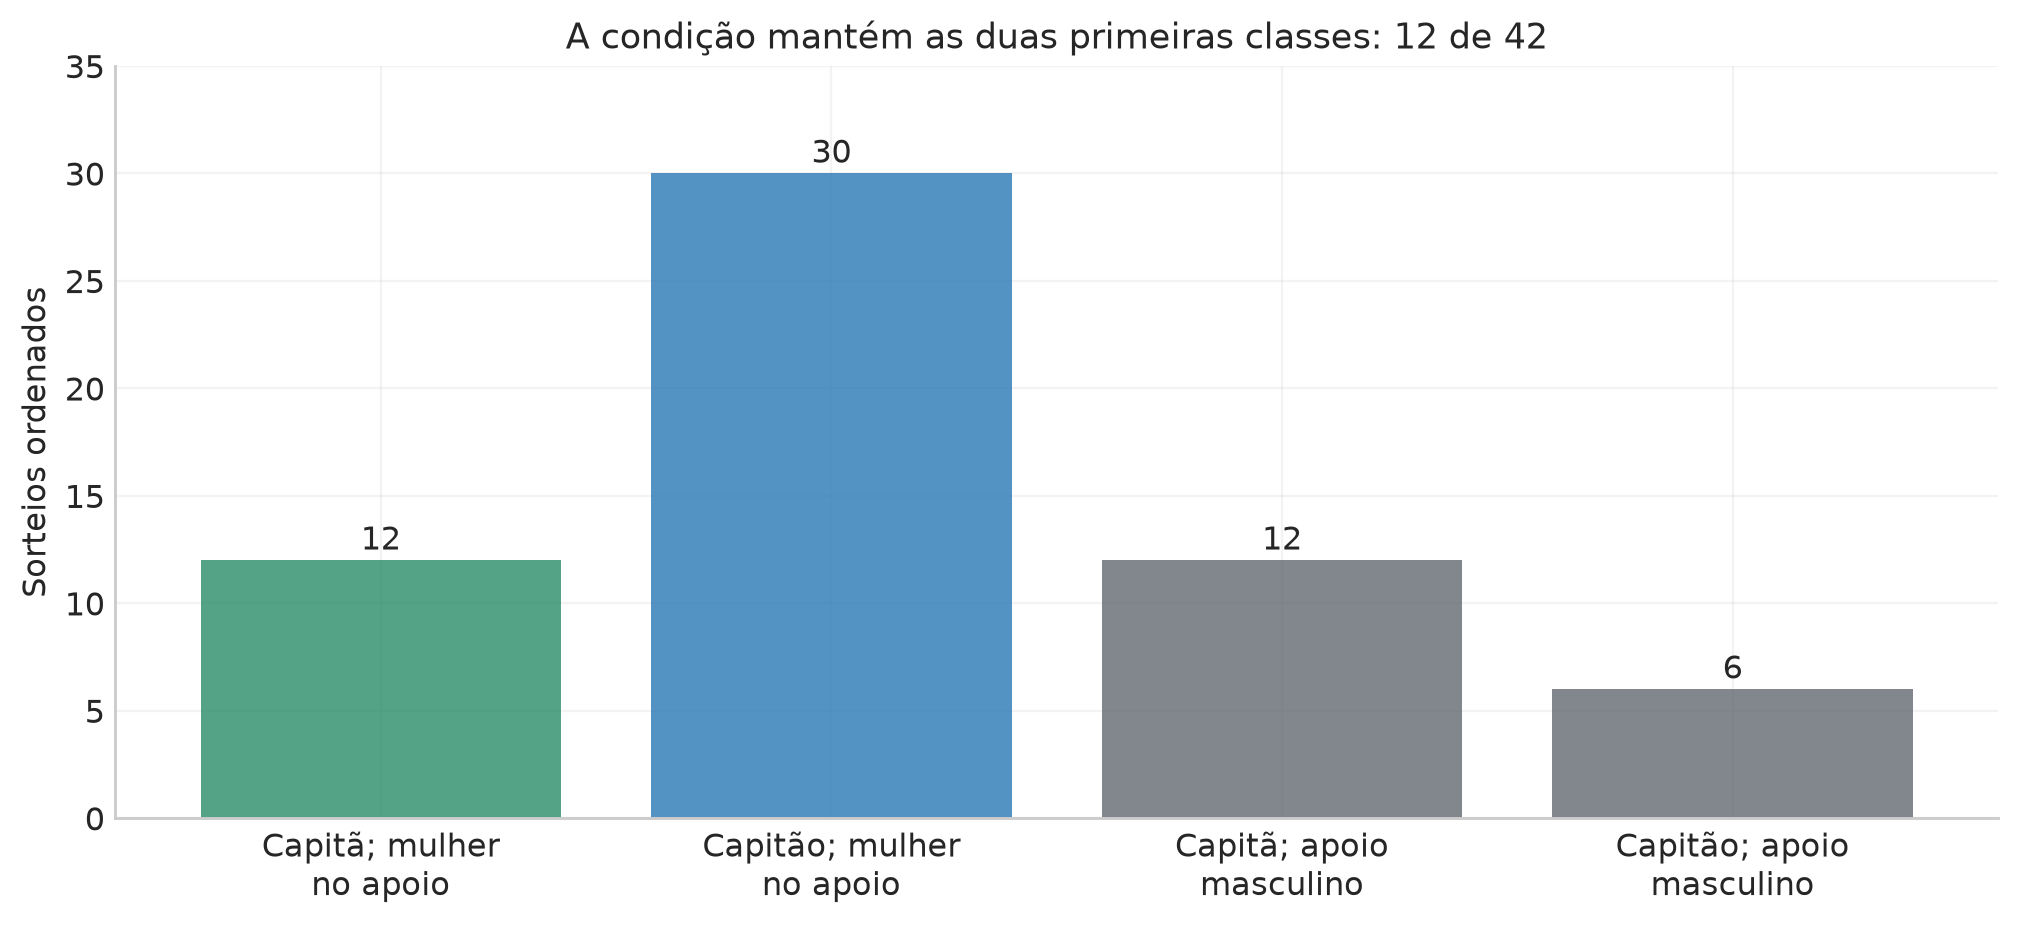

In [8]:
tripulacao = ['F1', 'F2', 'M1', 'M2', 'M3']
sorteios = list(permutations(tripulacao, 3))
cap_mulher = np.array([s[0].startswith('F') for s in sorteios])
apoio_mulher = np.array([s[1].startswith('F') or s[2].startswith('F') for s in sorteios])
prob_cap_cond = cap_mulher[apoio_mulher].mean()
conferir('Astronautas: enumeração versus Bayes', prob_cap_cond, 2/7)
classes = [
    np.sum(cap_mulher & apoio_mulher), np.sum(~cap_mulher & apoio_mulher),
    np.sum(cap_mulher & ~apoio_mulher), np.sum(~cap_mulher & ~apoio_mulher),
]
tabela(['Pergunta', 'Resultado'], [
    ['P(capitã)', '2/5 = 0.400000'],
    ['P(capitã | mulher na posição 2)', '1/4 = 0.250000'],
    ['P(capitã | pelo menos uma mulher no apoio)', f'2/7 = {prob_cap_cond:.6f}'],
    ['Sorteios compatíveis com a informação / total', f'{apoio_mulher.sum()} / {len(sorteios)}'],
])
fig, ax = plt.subplots(figsize=(9.5, 4.3), layout='constrained')
labels = ['Capitã; mulher\nno apoio', 'Capitão; mulher\nno apoio', 'Capitã; apoio\nmasculino', 'Capitão; apoio\nmasculino']
ax.bar(range(4), classes, color=[VERDE, AZUL, CINZA, CINZA], alpha=0.8)
for i, c in enumerate(classes):
    ax.text(i, c+0.5, str(c), ha='center')
ax.set(xticks=range(4), xticklabels=labels, ylabel='Sorteios ordenados', ylim=(0, 35), title='A condição mantém as duas primeiras classes: 12 de 42')
mostrar_figura(fig, '07_astronautas')

### 1.8 Processo de Poisson: das hipóteses locais à contagem

**Slides 116–119 / Gregory §4.7.** Seja $N(t)$ a contagem acumulada. Assumimos taxa constante $\lambda>0$, incrementos independentes em intervalos disjuntos e, para $dt$ pequeno,
$$P(\Delta N=1)=\lambda dt+o(dt),\qquad P(\Delta N\ge2)=o(dt).$$
Se $q(t)=P[N(t)=0]$, a independência dos incrementos fornece
$$q(t+dt)=q(t)[1-\lambda dt+o(dt)]\quad\Rightarrow\quad q'(t)=-\lambda q(t),$$
e $q(0)=1$ dá $q(t)=e^{-\lambda t}$.

Para $n$ eventos nos instantes ordenados $0<u_1<\cdots<u_n<T$, a densidade é $e^{-\lambda T}\lambda^n$. Integrando sobre esse simplex, cujo volume é $T^n/n!$,
$$\boxed{P[N(T)=n\mid\lambda]=e^{-\lambda T}\frac{(\lambda T)^n}{n!}.}$$
Assim, $\mathbb E[N(T)]=\mathrm{Var}[N(T)]=\lambda T$. O tempo de espera até o próximo evento tem distribuição exponencial de média $1/\lambda$. Vamos simular algumas sequências a partir desses tempos de espera e comparar a contagem com a PMF exata.

Média: teoria=6.000, simulação=6.004
Variância: teoria=6.000, simulação=6.059


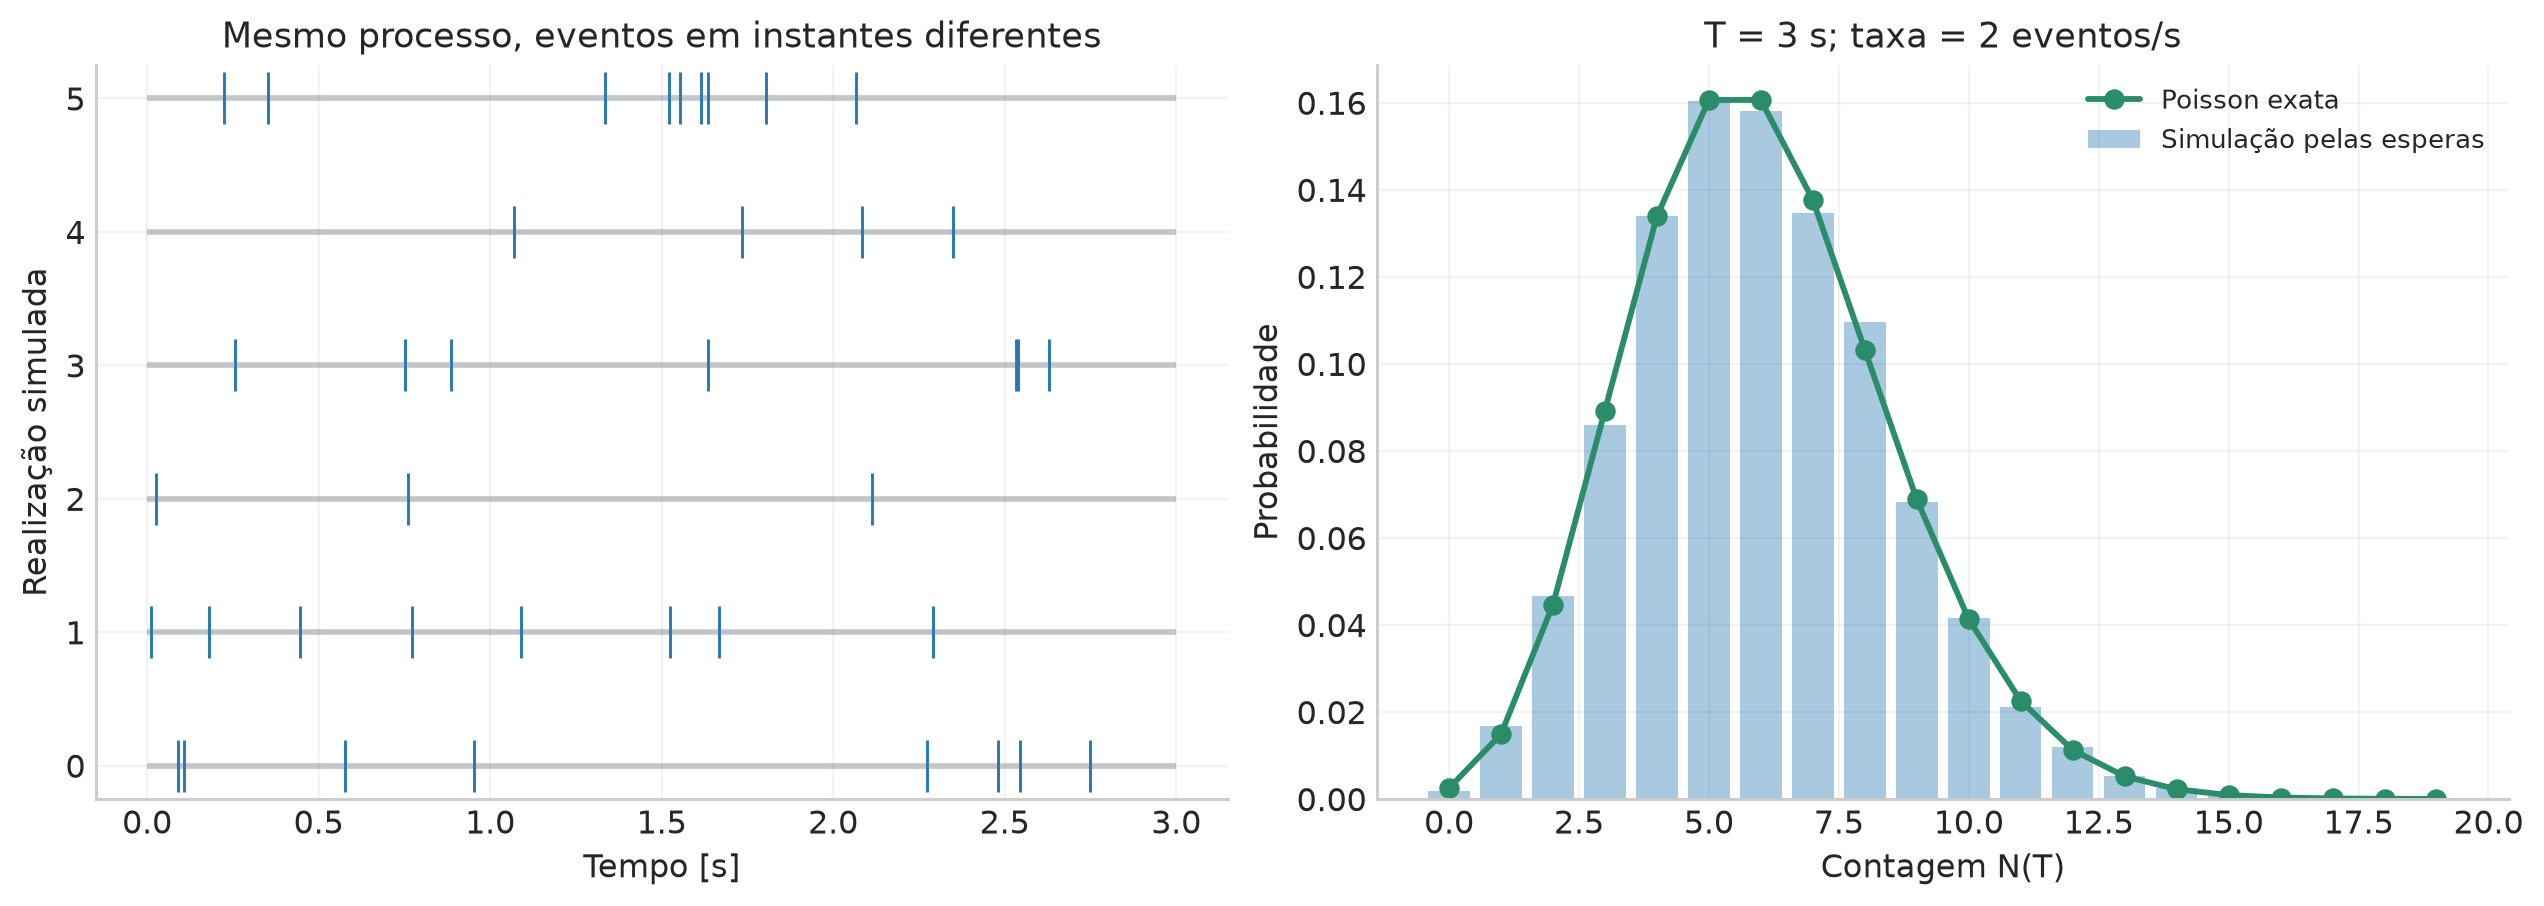

In [9]:
taxa_pois, T_pois = 2.0, 3.0  # eventos/s e s; o produto é adimensional.
rng_pois = np.random.default_rng(SEMENTE+2)

def eventos_poisson(taxa, duracao, rng):
    """Gera instantes de um processo homogêneo pela soma de esperas exponenciais."""
    tempos, atual = [], 0.0
    while True:
        atual += rng.exponential(1/taxa)
        if atual > duracao:
            return np.asarray(tempos)
        tempos.append(atual)

traj_pois = [eventos_poisson(taxa_pois, T_pois, rng_pois) for _ in range(6)]
# A simulação abaixo usa o processo de tempos, não sorteia a contagem pronta.
contagens_pois = np.array([len(eventos_poisson(taxa_pois, T_pois, rng_pois)) for _ in range(12000)])
mu_pois = taxa_pois*T_pois
print(f'Média: teoria={mu_pois:.3f}, simulação={contagens_pois.mean():.3f}')
print(f'Variância: teoria={mu_pois:.3f}, simulação={contagens_pois.var():.3f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2), layout='constrained')
for j, tempos in enumerate(traj_pois):
    ax[0].hlines(j, 0, T_pois, color=CINZA, alpha=0.35)
    ax[0].plot(tempos, np.full(len(tempos), j), '|', ms=18, color=AZUL)
ax[0].set(xlabel='Tempo [s]', ylabel='Realização simulada', title='Mesmo processo, eventos em instantes diferentes', yticks=range(6))
k = np.arange(0, max(20, contagens_pois.max()+1))
hist = np.bincount(contagens_pois, minlength=len(k))/len(contagens_pois)
ax[1].bar(k, hist[:len(k)], color=AZUL, alpha=0.4, label='Simulação pelas esperas')
ax[1].plot(k, poisson.pmf(k, mu_pois), 'o-', color=VERDE, label='Poisson exata')
ax[1].set(xlabel='Contagem N(T)', ylabel='Probabilidade', title='T = 3 s; taxa = 2 eventos/s')
ax[1].legend()
mostrar_figura(fig, '08_processo_poisson')

### 1.9 Condicionar no total: Poisson → binomial é uma identidade, não um limite

**Slides 120–123 / Gregory §4.7.1.** Definimos $N_1=N(t_1)$ e $N_2=N(t_2)$ para a **mesma realização**, com $t_1<t_2$. Temos $N_2=N_1+[N_2-N_1]$. A independência vale entre $N_1$ e o incremento restante, não entre as duas contagens acumuladas.

$$P(N_1=k\mid N_2=m,\lambda)=\frac{P(N_1=k\mid\lambda)P(N_2-N_1=m-k\mid\lambda)}{P(N_2=m\mid\lambda)}$$
$$=\frac{e^{-\lambda t_1}(\lambda t_1)^k/k!\;e^{-\lambda(t_2-t_1)}[\lambda(t_2-t_1)]^{m-k}/(m-k)!}{e^{-\lambda t_2}(\lambda t_2)^m/m!}$$
$$\boxed{=\binom mk q^k(1-q)^{m-k},\qquad q=\frac{t_1}{t_2},\quad k=0,\ldots,m.}$$

O total fixado transforma a pergunta em uma alocação temporal: cada um dos $m$ eventos, rotulado sem ordenar no tempo, tem probabilidade $q$ de cair no intervalo inicial. A taxa cancela porque já condicionamos em quantos eventos ocorreram. Para uma taxa não homogênea, a fração relevante envolve as intensidades integradas; a razão simples dos tempos usa homogeneidade.

**Ressalva sobre a comparação frequentista.** A binomial condicional é um resultado da teoria de probabilidade, disponível às duas abordagens. A Poisson com taxa estimada $m/t_2$ mostrada no slide não incorpora o total exato daquela realização. Permitir $N_1>m$ é inadequado para essa pergunta, mas não uma impossibilidade de a inferência frequentista condicionar corretamente. Mantemos o gráfico para entender o que muda ao usar informações diferentes, sem atribuir essa falha ao paradigma inteiro.

**Nossa dúvida com um intervalo muito curto.** Se $N(t_2)=2$,
$$P[N(dt)=1\mid N(t_2)=2]=2\frac{dt}{t_2}\left(1-\frac{dt}{t_2}\right),$$
enquanto, sem fixar o total, $P[N(dt)=1\mid\lambda]=\lambda dt\,e^{-\lambda dt}$. O pequeno parâmetro da primeira expressão é $dt/t_2$; o da segunda, $\lambda dt$. As condicionais são diferentes.

Somando novamente sobre os totais, recuperamos a Poisson original:
$$\sum_{m=k}^\infty\binom mk q^k(1-q)^{m-k}\frac{e^{-\lambda t_2}(\lambda t_2)^m}{m!}
=e^{-\lambda t_1}\frac{(\lambda t_1)^k}{k!}.$$

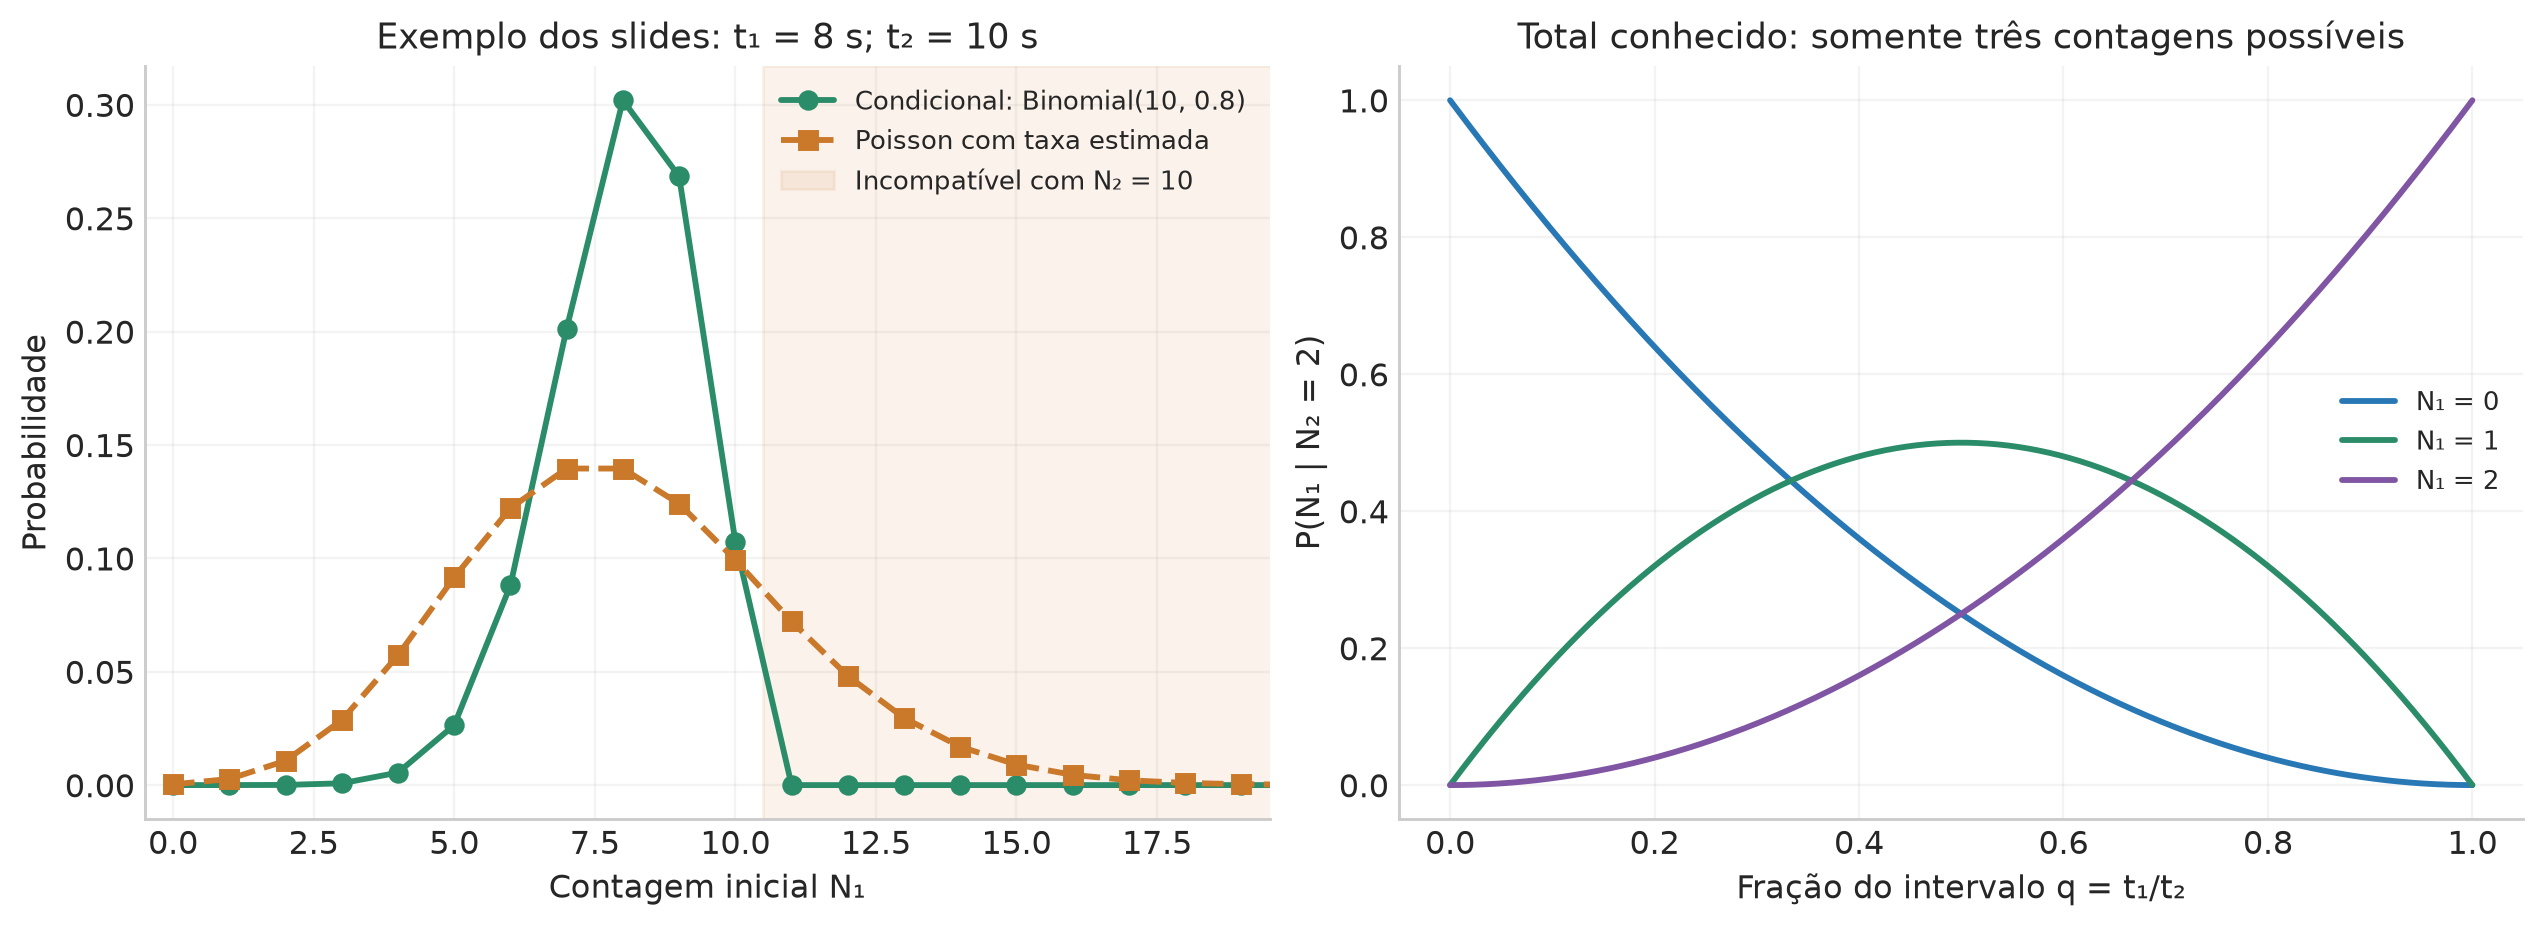

| Distribuição para o exemplo dos slides | Média | Variância | P(N₁ > 10) |
| --- | --- | --- | --- |
| Binomial condicional | 8 | 1.6 | 0 |
| Poisson plug-in | 8 | 8 | 0.184114 |

Com t₂=1 s e dt=0.01 s: P(N(dt)=1 | N(t₂)=2) = 0.019800


In [10]:
def poisson_condicionada(k, m, taxa, t1, t2):
    """Calcula a condicional pela razão de Poissons, em log, com suporte explícito."""
    k = np.asarray(k)
    resultado = np.zeros(k.shape, dtype=float)
    valido = (k >= 0) & (k <= m)
    kv = k[valido]
    logp = (poisson.logpmf(kv, taxa*t1)
            +poisson.logpmf(m-kv, taxa*(t2-t1))-poisson.logpmf(m, taxa*t2))
    resultado[valido] = np.exp(logp)
    return resultado

fig, ax = plt.subplots(1, 2, figsize=(12, 4.3), layout='constrained')
# Valores do gráfico dos slides. A aproximação plug-in mantém a média, mas muda a variância e o suporte.
m_total, t1, t2 = 10, 8.0, 10.0
k = np.arange(0, 21)
exata = binom.pmf(k, m_total, t1/t2)
plug_in = poisson.pmf(k, (m_total/t2)*t1)
ax[0].plot(k, exata, 'o-', color=VERDE, label='Condicional: Binomial(10, 0.8)')
ax[0].plot(k, plug_in, 's--', color=LARANJA, label='Poisson com taxa estimada')
ax[0].axvspan(10.5, 20.5, color=LARANJA, alpha=0.09, label='Incompatível com N₂ = 10')
ax[0].set(xlim=(-0.5, 19.5), xlabel='Contagem inicial N₁', ylabel='Probabilidade', title='Exemplo dos slides: t₁ = 8 s; t₂ = 10 s')
ax[0].legend()
for taxa in [0.1, 1.0, 7.0]:
    conferir(f'Cancelamento da taxa λ={taxa}', poisson_condicionada(k, m_total, taxa, t1, t2), exata)

# Dois eventos no intervalo total: variamos somente a fração inicial.
q_curto = np.linspace(0, 1, 501)
for j, cor in zip([0, 1, 2], [AZUL, VERDE, ROXO]):
    ax[1].plot(q_curto, binom.pmf(j, 2, q_curto), color=cor, label=f'N₁ = {j}')
ax[1].set(xlabel='Fração do intervalo q = t₁/t₂', ylabel='P(N₁ | N₂ = 2)', title='Total conhecido: somente três contagens possíveis')
ax[1].legend()
mostrar_figura(fig, '09_poisson_condicionada')
tabela(['Distribuição para o exemplo dos slides', 'Média', 'Variância', 'P(N₁ > 10)'], [
    ['Binomial condicional', '8', '1.6', '0'],
    ['Poisson plug-in', '8', '8', f'{poisson.sf(10, 8):.6f}'],
])
print(f'Com t₂=1 s e dt=0.01 s: P(N(dt)=1 | N(t₂)=2) = {binom.pmf(1, 2, 0.01):.6f}')

# Recuperamos uma probabilidade não condicionada somando sobre totais até uma cauda desprezível.
taxa_mix, T_mix, t_mix = 1.7, 2.0, 0.3
m_grade = np.arange(100)
recuperada = np.sum(binom.pmf(1, m_grade, t_mix/T_mix)*poisson.pmf(m_grade, taxa_mix*T_mix))
conferir('Marginalizar o total recupera a Poisson', recuperada, poisson.pmf(1, taxa_mix*t_mix))

Podemos ainda conferir a independência da taxa por um experimento numérico que **não sorteia a binomial condicional diretamente**: sorteamos duas Poissons independentes, uma para cada intervalo disjunto, somamos e selecionamos somente as realizações com total 2. A fração selecionada depende da taxa, mas a alocação condicional tem a mesma lei.

In [11]:
rng_cond = np.random.default_rng(SEMENTE+3)
dt_cond, T_cond, n_repeticoes = 0.01, 1.0, 400000
linhas = []
for taxa in [0.5, 2.0, 4.0]:
    primeiro = rng_cond.poisson(taxa*dt_cond, n_repeticoes)
    restante = rng_cond.poisson(taxa*(T_cond-dt_cond), n_repeticoes)
    selecionado = (primeiro+restante) == 2
    estimativa = np.mean(primeiro[selecionado] == 1)
    p_exato = binom.pmf(1, 2, dt_cond/T_cond)
    erro_mc = np.sqrt(p_exato*(1-p_exato)/selecionado.sum())
    linhas.append([taxa, int(selecionado.sum()), f'{estimativa:.5f} ± {erro_mc:.5f}', f'{p_exato:.5f}'])
tabela(['Taxa [1/s]', 'Realizações com total 2', 'P(N₁=1): simulação ± 1σ MC', 'Valor exato'], linhas)

| Taxa [1/s] | Realizações com total 2 | P(N₁=1): simulação ± 1σ MC | Valor exato |
| --- | --- | --- | --- |
| 0.5 | 30114 | 0.01953 ± 0.00080 | 0.01980 |
| 2.0 | 108394 | 0.01931 ± 0.00042 | 0.01980 |
| 4.0 | 58857 | 0.01990 ± 0.00057 | 0.01980 |

### 1.10 Limite binomial → Poisson: eventos raros e muitas oportunidades

Este é um limite assintótico, diferente do condicionamento anterior. Tomamos $n\to\infty$, $p\to0$, mantendo $np=\mu$ fixo. Para uma contagem $k$ fixa,
$$\binom nk\left(\frac\mu n\right)^k\left(1-\frac\mu n\right)^{n-k}
=\frac{\mu^k}{k!}\underbrace{\prod_{j=0}^{k-1}\left(1-\frac jn\right)}_{\to1}
\underbrace{\left(1-\frac\mu n\right)^n}_{\to e^{-\mu}}
\underbrace{\left(1-\frac\mu n\right)^{-k}}_{\to1}.$$
Portanto, $P(K=k)\to e^{-\mu}\mu^k/k!$. O que precisa ser raro é cada oportunidade individual, não necessariamente o total esperado $\mu$. Usaremos $\mu=3$.

Nas tabelas, a distância de variação total é $\tfrac12\sum_k|P(k)-Q(k)|$. Para comparar distribuições com suportes distintos, incluímos a cauda da Poisson além do suporte da binomial.

| n | p = 3/n | Variância binomial | TV para Poisson(3) |
| --- | --- | --- | --- |
| 10 | 0.3000 | 2.10000 | 0.0864089 |
| 50 | 0.0600 | 2.82000 | 0.0154224 |
| 500 | 0.0060 | 2.98200 | 0.0015051 |

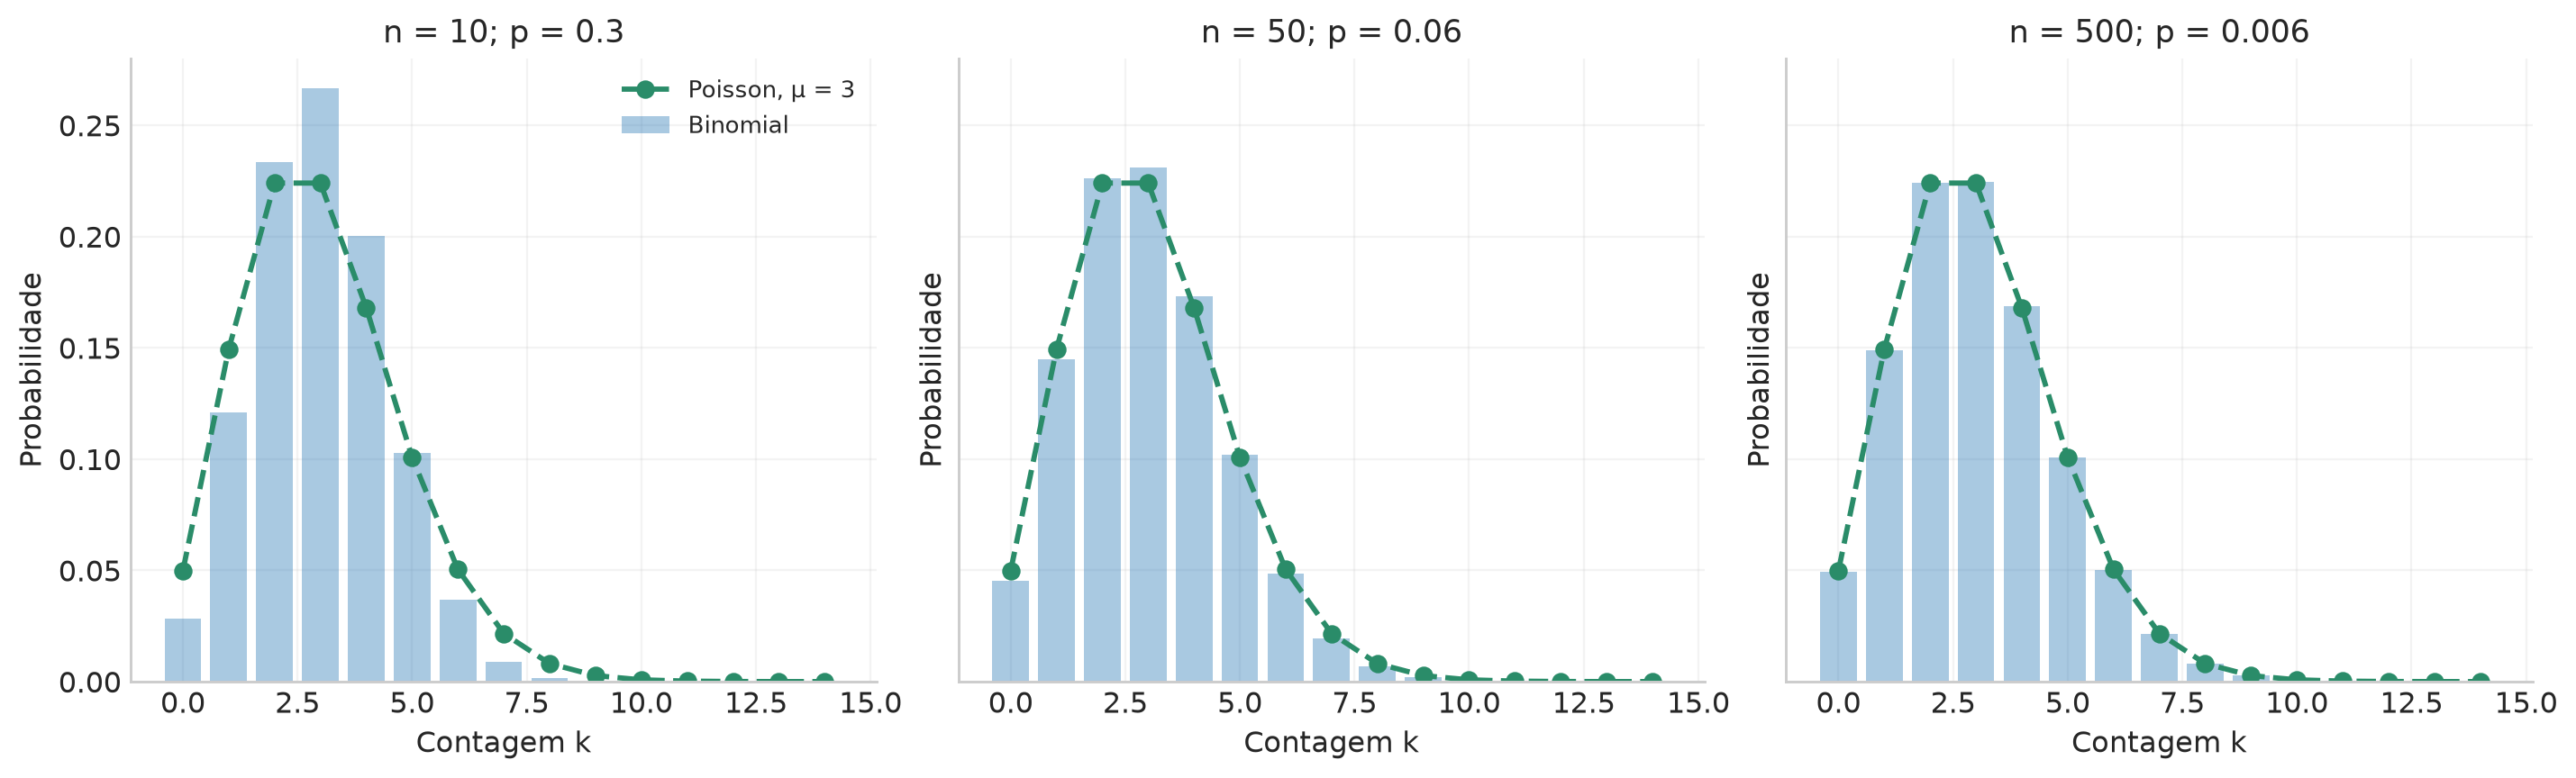

In [12]:
mu_limite = 3.0
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4), sharey=True, layout='constrained')
linhas = []
for ax, n in zip(axes, [10, 50, 500]):
    p = mu_limite/n
    ks = np.arange(n+1)
    tv = 0.5*(np.abs(binom.pmf(ks, n, p)-poisson.pmf(ks, mu_limite)).sum()+poisson.sf(n, mu_limite))
    linhas.append([n, f'{p:.4f}', f'{n*p*(1-p):.5f}', f'{tv:.7f}'])
    kp = np.arange(0, 15)
    ax.bar(kp, binom.pmf(kp, n, p), color=AZUL, alpha=0.4, label='Binomial')
    ax.plot(kp, poisson.pmf(kp, mu_limite), 'o--', color=VERDE, label='Poisson, μ = 3')
    ax.set(title=f'n = {n}; p = {p:.3g}', xlabel='Contagem k', ylabel='Probabilidade')
axes[0].legend()
tabela(['n', 'p = 3/n', 'Variância binomial', 'TV para Poisson(3)'], linhas)
mostrar_figura(fig, '10_binomial_poisson')

### 1.11 Aproximações gaussianas: padronizar é essencial

Para a binomial, com $p\in(0,1)$ fixo,
$$Z_n=\frac{R_n-np}{\sqrt{np(1-p)}}\xrightarrow{d}\mathcal N(0,1).$$
Uma forma de ver a matemática é escrever a função característica. Para $X\sim\mathrm{Bernoulli}(p)$, a expansão em torno de zero dá
$$\mathbb E[e^{it(X-p)/\sqrt{np(1-p)}}]=1-\frac{t^2}{2n}+O(n^{-3/2}).$$
O produto de $n$ fatores independentes tende a $e^{-t^2/2}$, a função característica normal. Na escala original, a aproximação é $\mathcal N(np,np(1-p))$. Ela pode falhar perto das bordas, sobretudo quando $np$ ou $n(1-p)$ é pequeno.

Para $K\sim\mathrm{Poisson}(\mu)$, sua função característica é $e^{\mu(e^{it}-1)}$. Portanto,
$$\log\mathbb E\left[e^{it(K-\mu)/\sqrt\mu}\right]
=\mu\left(e^{it/\sqrt\mu}-1-\frac{it}{\sqrt\mu}\right)
=-\frac{t^2}{2}+O(\mu^{-1/2}),$$
e $(K-\mu)/\sqrt\mu\xrightarrow{d}\mathcal N(0,1)$ quando $\mu\to\infty$.

**Comparação correta no gráfico.** Uma PMF não deve ser comparada diretamente a uma densidade sem observar a largura das classes. Usamos correção de continuidade:
$$P(K=k)\approx\Phi\!\left(\frac{k+1/2-\mu_K}{\sigma_K}\right)
-\Phi\!\left(\frac{k-1/2-\mu_K}{\sigma_K}\right).$$
As barras e os pontos serão ambos probabilidades por classe. Não renormalizamos a aproximação para esconder sua massa em valores fisicamente impossíveis.

| Distribuição | TV para normal discretizada | Massa normal fora do suporte |
| --- | --- | --- |
| Binomial(10,0.3) | 0.036849 | 0.00786 |
| Binomial(40,0.3) | 0.017282 | 8.06e-06 |
| Binomial(200,0.3) | 0.007776 | 5.03e-21 |
| Poisson(2) | 0.096822 | 0.0385 |
| Poisson(10) | 0.040234 | 0.000449 |
| Poisson(50) | 0.017814 | 4.61e-13 |

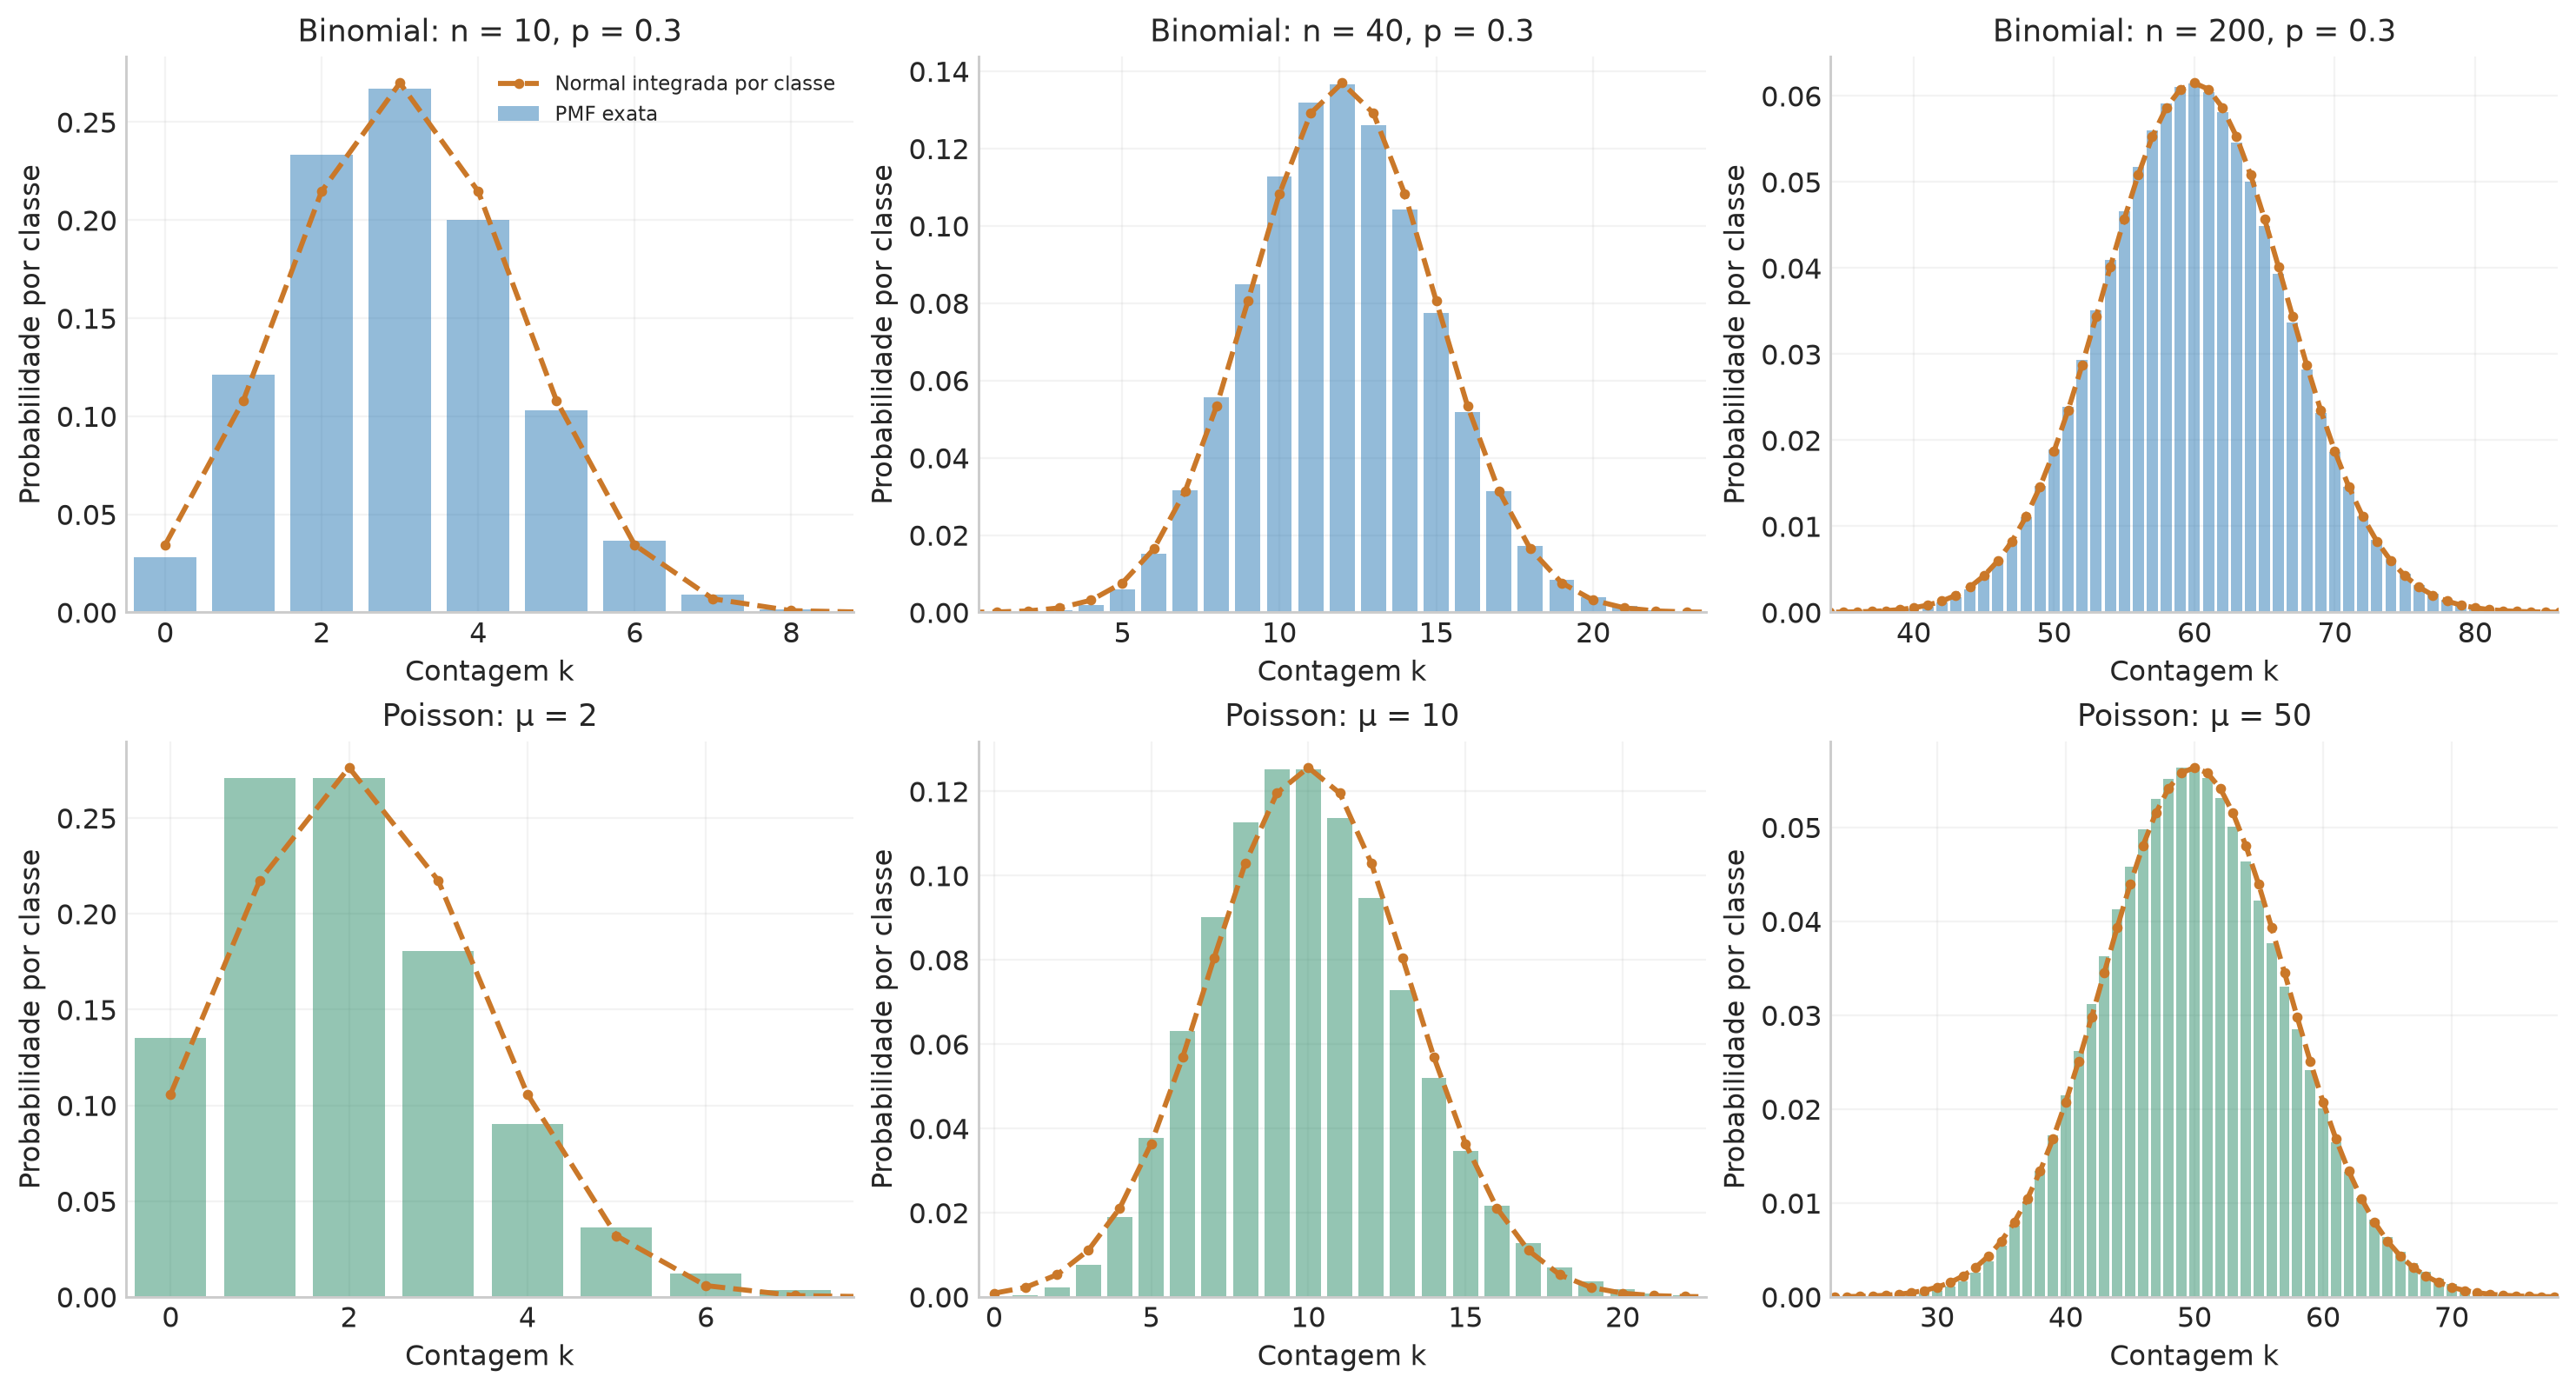

In [13]:
def massa_normal_por_classe(k, media, desvio):
    """Integra a normal no intervalo [k−1/2, k+1/2]."""
    return norm.cdf((k+0.5-media)/desvio)-norm.cdf((k-0.5-media)/desvio)

fig, axes = plt.subplots(2, 3, figsize=(14, 7.5), layout='constrained')
linhas = []
for ax, n in zip(axes[0], [10, 40, 200]):
    p = 0.3
    media, desvio = n*p, np.sqrt(n*p*(1-p))
    k = np.arange(n+1)
    exata = binom.pmf(k, n, p)
    aprox = massa_normal_por_classe(k, media, desvio)
    fora = norm.cdf((-0.5-media)/desvio)+norm.sf((n+0.5-media)/desvio)
    tv = 0.5*(np.abs(exata-aprox).sum()+fora)
    linhas.append([f'Binomial({n},0.3)', f'{tv:.6f}', f'{fora:.3g}'])
    ax.bar(k, exata, color=AZUL, alpha=0.5, label='PMF exata')
    ax.plot(k, aprox, 'o--', color=LARANJA, ms=3, label='Normal integrada por classe')
    ax.set(xlim=(max(-0.5, media-4*desvio), min(n+0.5, media+4*desvio)), title=f'Binomial: n = {n}, p = 0.3', xlabel='Contagem k', ylabel='Probabilidade por classe')
for ax, mu in zip(axes[1], [2.0, 10.0, 50.0]):
    k = np.arange(int(poisson.ppf(1-1e-12, mu))+1)
    exata = poisson.pmf(k, mu)
    aprox = massa_normal_por_classe(k, mu, np.sqrt(mu))
    fora = norm.cdf((-0.5-mu)/np.sqrt(mu))
    # As duas caudas superiores omitidas são < 10^-10 nesta grade.
    tv = 0.5*(np.abs(exata-aprox).sum()+fora)
    linhas.append([f'Poisson({mu:g})', f'{tv:.6f}', f'{fora:.3g}'])
    ax.bar(k, exata, color=VERDE, alpha=0.5)
    ax.plot(k, aprox, 'o--', color=LARANJA, ms=3)
    ax.set(xlim=(max(-0.5, mu-4*np.sqrt(mu)), mu+4*np.sqrt(mu)), title=f'Poisson: μ = {mu:g}', xlabel='Contagem k', ylabel='Probabilidade por classe')
axes[0, 0].legend(fontsize=8)
tabela(['Distribuição', 'TV para normal discretizada', 'Massa normal fora do suporte'], linhas)
mostrar_figura(fig, '11_limites_gaussianos')

### 1.12 Ponte com contagens de fontes e seleção

Há duas operações que aparecem em catálogos e não devem ser confundidas:

1. **Fixar o total.** Se $K_j$ são Poissons independentes com médias $\mu_j$, então, condicionadas em $\sum_jK_j=m$, as contagens têm distribuição multinomial com $p_j=\mu_j/\sum_k\mu_k$. A binomial temporal é o caso de duas categorias.
2. **Selecionar cada evento.** Se $N\sim\mathrm{Poisson}(\mu)$ e cada evento é detectado independentemente com probabilidade $s$, então $K\mid N\sim\mathrm{Binomial}(N,s)$ e, marginalizando $N$, $K\sim\mathrm{Poisson}(\mu s)$. Pela função geradora,
$$G_K(t)=G_N(1-s+st)=\exp[\mu s(t-1)].$$

Isso ajuda a pensar nas contagens de galáxias e de eventos GW. Entretanto, galáxias traçam um campo com estrutura: uma Poisson de intensidade fixa não descreve por si só a correlação espacial. A hipótese de amostragem Poisson pode ser **condicional ao campo de intensidade**, e máscaras, completude e seleção precisam entrar no modelo.

| Relação estudada | Natureza | O que mantivemos fixo |
|:--|:--|:--|
| Hipergeométrica → binomial | Limite de população grande | $n$ e $M/N\to p$ |
| Binomial → Poisson | Limite de eventos raros | $np=\mu$ |
| Binomial / Poisson → normal | Limite da variável padronizada | Escala definida pelos respectivos momentos |
| Contagens Poisson → binomial / multinomial | Condicionamento exato | Total observado |
| Poisson selecionada → Poisson | Marginalização exata | Probabilidade de detecção constante e independente |

**Para registrar com minhas palavras:** em qual etapa cada exemplo usa independência? O que muda se eu souber o total? Qual quantidade é parâmetro e qual é dado? Essas perguntas são mais importantes do que memorizar a forma de cada distribuição.

## Parte 2 — Transformações de variáveis

O objetivo é preservar a probabilidade dos eventos correspondentes. Para uma transformação invertível $Y=g(X)$,
$$f_Y(y)\,dy=f_X(x)\,|dx|,\qquad
\boxed{f_Y(y)=f_X(g^{-1}(y))\left|\frac{d g^{-1}}{dy}\right|.}$$

Em várias dimensões, multiplicamos pelo módulo do determinante do jacobiano inverso. Se houver vários ramos inversos, somamos suas contribuições. A fórmula de mudança de variável é exata sob as condições de regularidade; uma derivada aproximadamente constante só é necessária quando queremos substituir a transformação não linear por uma linearização.

Antes dos exemplos, precisamos separar duas operações:
$$\mathbb E[g(X)]=\int g(x)f_X(x)dx,\qquad
g(\mathbb E[X])=g\!\left(\int xf_X(x)dx\right).$$
Em geral elas não coincidem. Para $g(x)=x^2$, a diferença é a variância:
$$\mathbb E[X^2]-(\mathbb E[X])^2=\mathrm{Var}(X).$$
Na física, $\mathbb E[mv^2/2]=m[\mathbb E[v]^2+\mathrm{Var}(v)]/2$: velocidade média nula não significa energia cinética média nula. Uma transformação afim preserva a relação entre média e transformação; uma não linear exige mais cuidado.

### 2.1 Um ramo: de magnitude absoluta a distância

**Slides 124–125.** Chamaremos a magnitude aparente, conhecida, de $m_{\rm ap}$, e a magnitude absoluta incerta de $M$. Usando distância $D$ em Mpc,
$$m_{\rm ap}-M=5\log_{10}(D/\mathrm{Mpc})+25,$$
$$D(M)=10^{(m_{\rm ap}-M-25)/5}\,\mathrm{Mpc}.$$

Vamos supor $M\sim\mathcal N(\overline M,\sigma_M^2)$. A relação é monótona decrescente, com inversa $M(D)=m_{\rm ap}-25-5\log_{10}(D/\mathrm{Mpc})$ e jacobiano $|dM/dD|=5/(\ln10\,D)$. Definindo
$$a=\frac{\ln10}{5},\quad D_0=10^{(m_{\rm ap}-\overline M-25)/5}\,\mathrm{Mpc},\quad s=a\sigma_M,$$
temos $\ln(D/D_0)=-a(M-\overline M)$ e
$$\boxed{f_D(D)=\frac{1}{D\,s\sqrt{2\pi}}\exp\left[-\frac{\ln^2(D/D_0)}{2s^2}\right]},\quad D>0.$$

A distância é lognormal. Seus resumos são
$$\mathrm{mediana}(D)=D_0,\quad\mathbb E[D]=D_0e^{s^2/2},\quad\mathrm{moda}(D)=D_0e^{-s^2}.$$
Assim, transformar a magnitude média fornece a mediana da distância, não sua média. Este exemplo isola a transformação: não modela erros na magnitude aparente, extinção ou uma seleção por fluxo.

| Resumo da distância | Valor [Mpc] |
| --- | --- |
| D(E[M]) = mediana | 72.4436 |
| E[D], exata | 75.2625 |
| E[D], simulação | 75.1685 |
| Moda | 67.1186 |
| Intervalo correspondente a M média ± σ_M | [54.9541, 95.4993] |

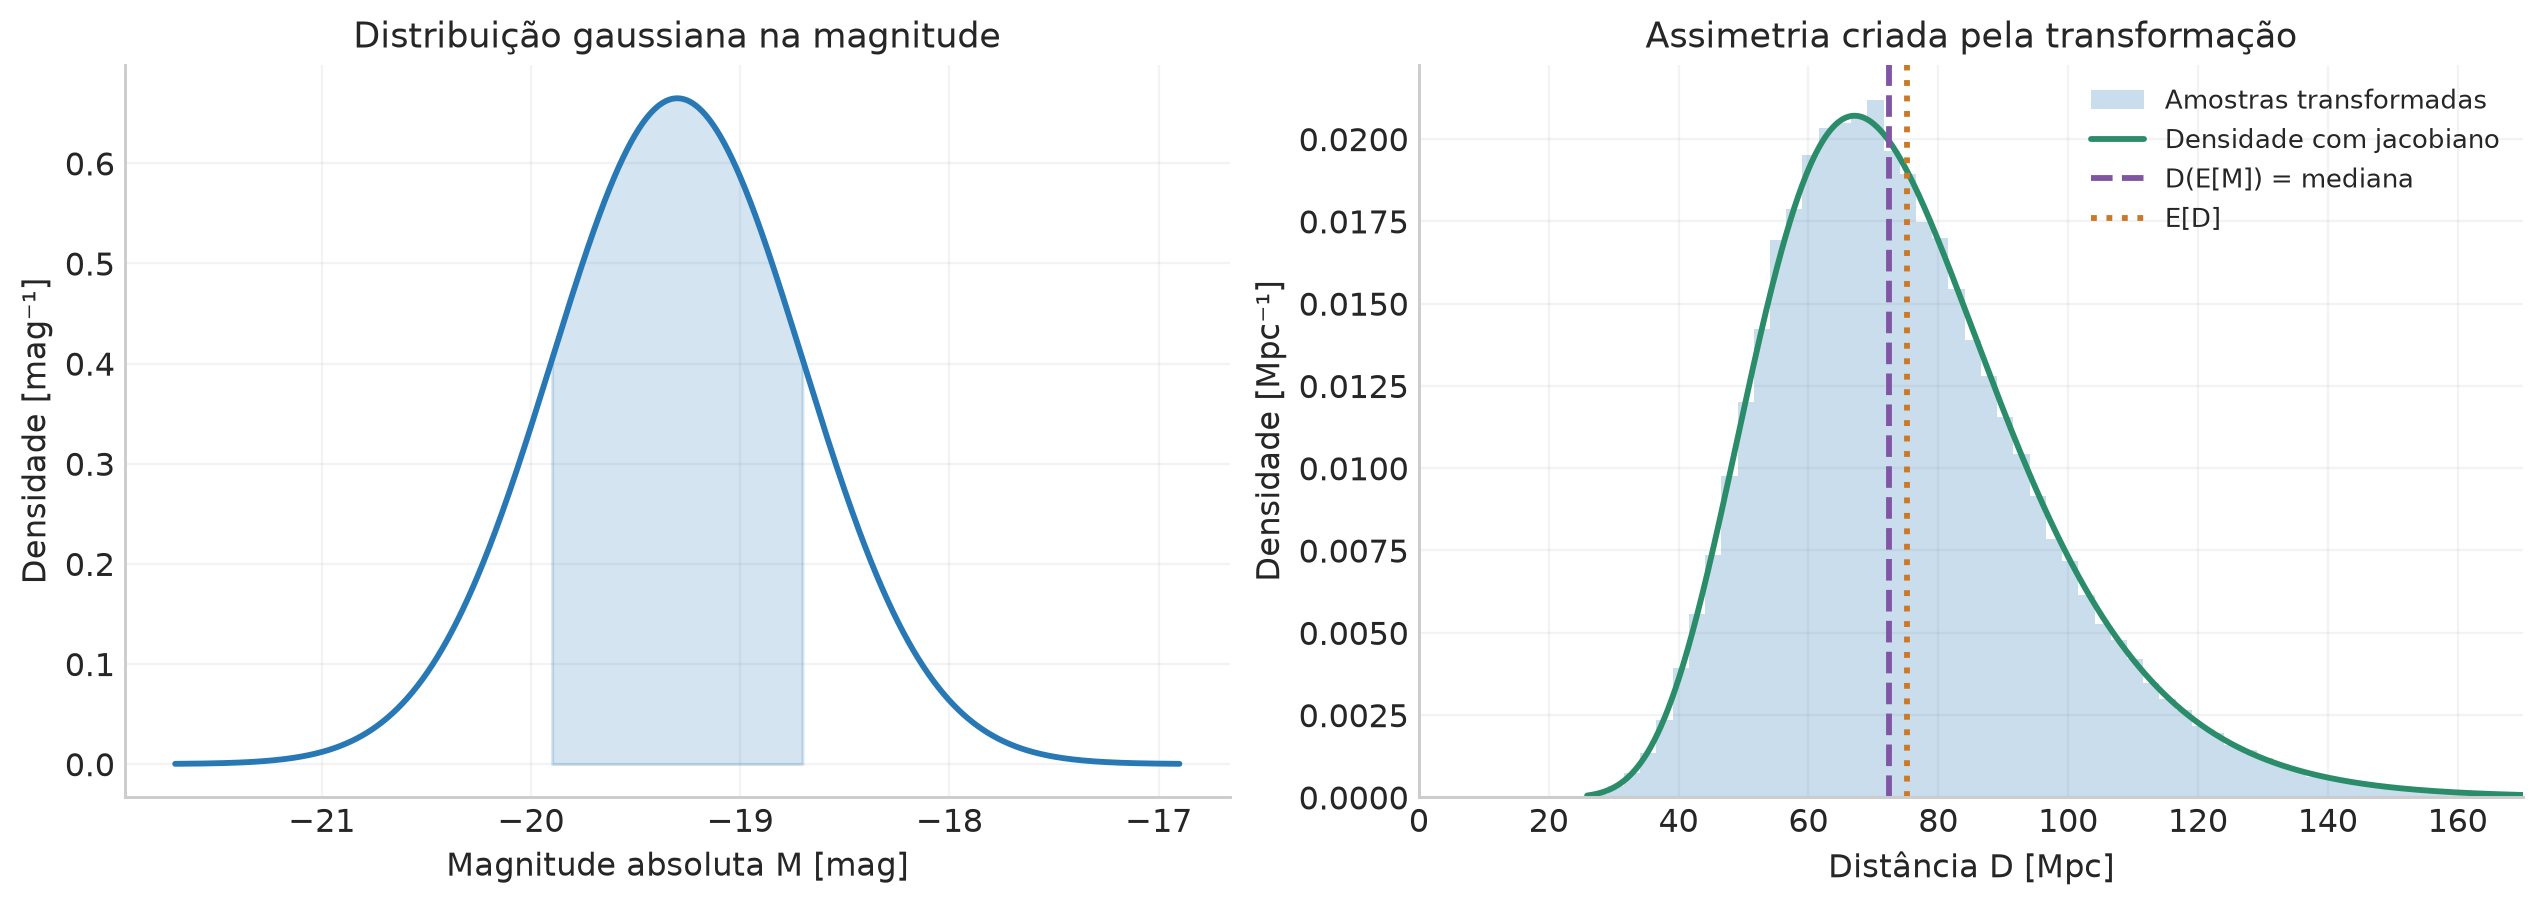

In [14]:
m_ap, M_media, sigma_M = 15.0, -19.3, 0.6
a_mag = np.log(10)/5
D0_mag = 10**((m_ap-M_media-25)/5)  # Valor numérico em Mpc.
s_mag = a_mag*sigma_M

def distancia_da_magnitude(M):
    return 10**((m_ap-np.asarray(M)-25)/5)

def pdf_distancia_mag(D):
    """Transformação exata da normal em M, incluindo o jacobiano inverso."""
    D = np.asarray(D, dtype=float)
    saida = np.zeros_like(D)
    positivo = D > 0
    M_inversa = m_ap-25-5*np.log10(D[positivo])
    saida[positivo] = norm.pdf(M_inversa, M_media, sigma_M)/(a_mag*D[positivo])
    return saida

post_Dmag = lognorm(s=s_mag, scale=D0_mag)
Dg = np.linspace(post_Dmag.ppf(0.0001), post_Dmag.ppf(0.9999), 1500)
conferir('Magnitude: jacobiano versus lognormal', pdf_distancia_mag(Dg), post_Dmag.pdf(Dg))
conferir('Magnitude: densidade normalizada', quad(lambda d: float(pdf_distancia_mag(d)), 0, np.inf)[0], 1)

# O intervalo em distância tem os extremos invertidos porque a função é decrescente.
D_lo = distancia_da_magnitude(M_media+sigma_M)
D_hi = distancia_da_magnitude(M_media-sigma_M)
prob_M_intervalo = norm.cdf(1)-norm.cdf(-1)
prob_D_intervalo = post_Dmag.cdf(D_hi)-post_Dmag.cdf(D_lo)
conferir('Magnitude: probabilidade do intervalo preservada', prob_D_intervalo, prob_M_intervalo)

rng_mag = np.random.default_rng(SEMENTE+4)
M_sim = rng_mag.normal(M_media, sigma_M, 100000)
D_sim = distancia_da_magnitude(M_sim)
tabela(['Resumo da distância', 'Valor [Mpc]'], [
    ['D(E[M]) = mediana', f'{D0_mag:.4f}'],
    ['E[D], exata', f'{post_Dmag.mean():.4f}'],
    ['E[D], simulação', f'{D_sim.mean():.4f}'],
    ['Moda', f'{D0_mag*np.exp(-s_mag**2):.4f}'],
    ['Intervalo correspondente a M média ± σ_M', f'[{D_lo:.4f}, {D_hi:.4f}]'],
])
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2), layout='constrained')
Mg = np.linspace(M_media-4*sigma_M, M_media+4*sigma_M, 1000)
ax[0].plot(Mg, norm.pdf(Mg, M_media, sigma_M), color=AZUL)
ax[0].fill_between(Mg, norm.pdf(Mg, M_media, sigma_M), where=abs(Mg-M_media)<=sigma_M, color=AZUL, alpha=0.2)
ax[0].set(xlabel='Magnitude absoluta M [mag]', ylabel='Densidade [mag⁻¹]', title='Distribuição gaussiana na magnitude')
ax[1].hist(D_sim, bins=80, density=True, color=AZUL, alpha=0.25, label='Amostras transformadas')
ax[1].plot(Dg, pdf_distancia_mag(Dg), color=VERDE, label='Densidade com jacobiano')
ax[1].axvline(D0_mag, color=ROXO, ls='--', label='D(E[M]) = mediana')
ax[1].axvline(post_Dmag.mean(), color=LARANJA, ls=':', label='E[D]')
ax[1].set(xlim=(0, post_Dmag.ppf(0.999)), xlabel='Distância D [Mpc]', ylabel='Densidade [Mpc⁻¹]', title='Assimetria criada pela transformação')
ax[1].legend()
mostrar_figura(fig, '12_magnitude_distancia')

**Interpretação.** A área sombreada em magnitude tem a mesma probabilidade no intervalo de distâncias transformado, mesmo que as alturas das densidades sejam diferentes. Os valores de $D$ altos ocupam intervalos mais largos; o fator $1/D$ ajusta essa mudança de escala.

### 2.2 Duas variáveis: soma, diferença e o determinante

Considere duas flutuações adimensionais correlacionadas,
$$\mathbf X=\begin{pmatrix}X_1\\X_2\end{pmatrix}\sim\mathcal N(\mathbf0,\Sigma_X),\qquad
\Sigma_X=\begin{pmatrix}1&\rho\\\rho&1\end{pmatrix},\quad\rho=0.6.$$
Definimos
$$\mathbf U=A\mathbf X,\qquad
A=\begin{pmatrix}1&1\\1&-1\end{pmatrix},\quad U_1=X_1+X_2,\quad U_2=X_1-X_2.$$
Logo, $X_1=(U_1+U_2)/2$, $X_2=(U_1-U_2)/2$ e $|\det A^{-1}|=1/2$:
$$\boxed{f_{\mathbf U}(\mathbf u)=\tfrac12 f_{\mathbf X}(A^{-1}\mathbf u).}$$
A covariância transforma como $\Sigma_U=A\Sigma_XA^T=\operatorname{diag}[2(1+\rho),2(1-\rho)]$. Neste caso **conjuntamente gaussiano**, a covariância diagonal implica independência entre soma e diferença. Para distribuições gerais, covariância zero não basta.

O determinante de $A$ tem módulo 2: áreas no novo espaço são duas vezes maiores. Sem o fator $1/2$, a densidade transformada integraria 2. Este exemplo é diferente de uma marginalização: mantivemos duas coordenadas e a transformação é invertível.

**Conexão com pesquisa.** Combinações lineares de campos ou estatísticas de dois traçadores alteram a covariância. O exemplo é uma representação gaussiana simplificada, não um modelo completo das contagens de galáxias e GW.

| Quantidade | Resultado |
| --- | --- |
| |det A| | 2.0 |
| |det A⁻¹| | 0.5 |
| Integral com jacobiano | 0.99999998 |
| Integral se esquecêssemos o jacobiano | 1.99999995 |
| Variâncias de U₁ e U₂ | [3.2 0.8] |

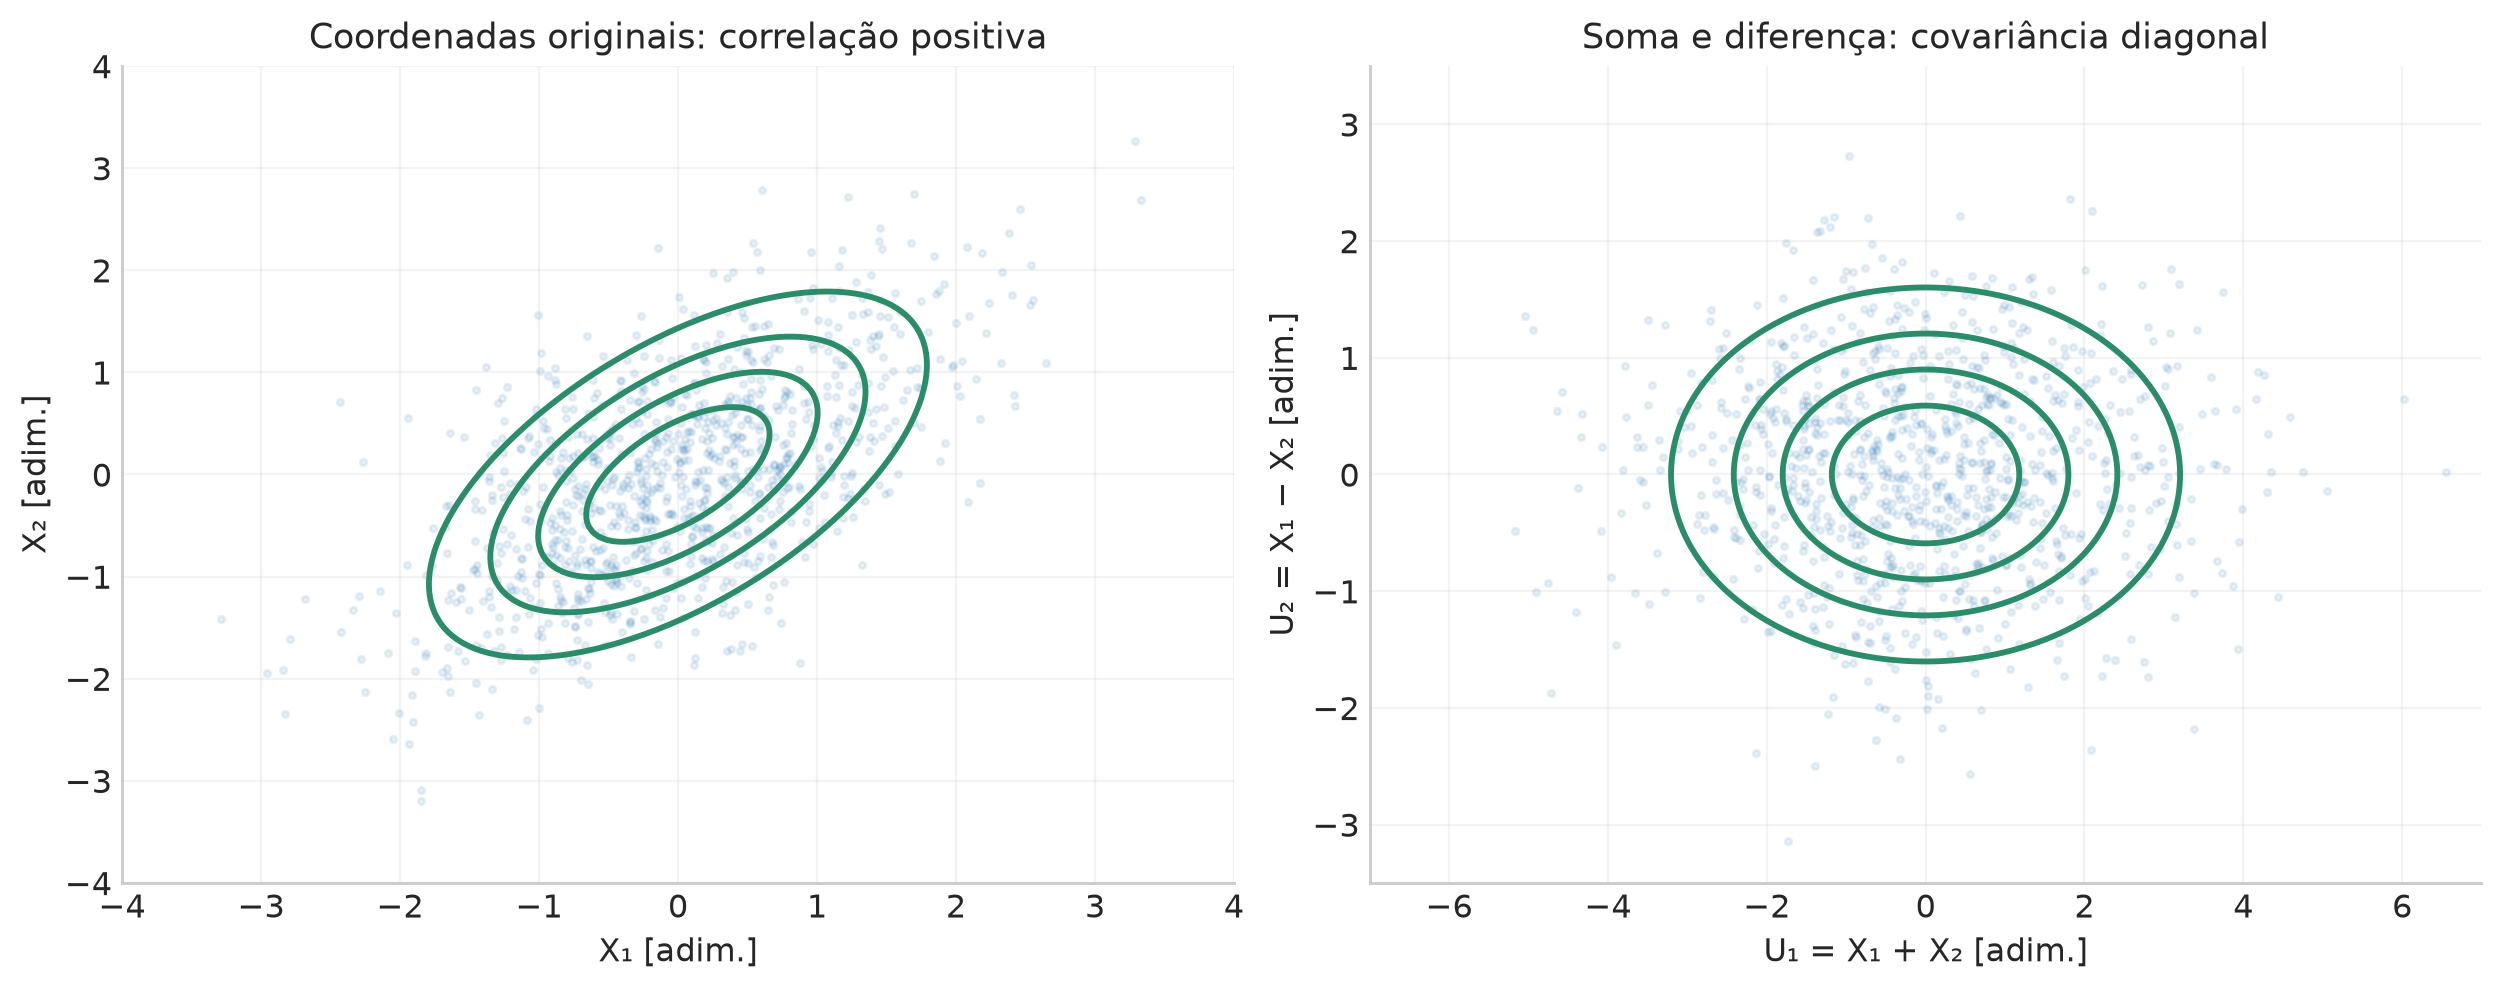

In [15]:
rho_2d = 0.6
Sigma_X = np.array([[1., rho_2d], [rho_2d, 1.]])
A_transf = np.array([[1., 1.], [1., -1.]])
A_inv = np.linalg.inv(A_transf)
jac_inverso = abs(np.linalg.det(A_inv))
Sigma_U = A_transf@Sigma_X@A_transf.T
normal_X = multivariate_normal(mean=[0, 0], cov=Sigma_X)
normal_U = multivariate_normal(mean=[0, 0], cov=Sigma_U)

def pdf_u_por_jacobiano(pontos_u):
    """Cada linha contém (u1,u2); o produto por A_inv.T recupera (x1,x2)."""
    pontos_x = np.asarray(pontos_u)@A_inv.T
    return normal_X.pdf(pontos_x)*jac_inverso

ug, vg = np.linspace(-10, 10, 601), np.linspace(-6, 6, 401)
UU, VV = np.meshgrid(ug, vg)
pontos_uv = np.stack([UU, VV], axis=-1)
pdf_uv = pdf_u_por_jacobiano(pontos_uv)
conferir('Transformação conjunta: duas expressões da densidade', pdf_uv, normal_U.pdf(pontos_uv))
norma_uv = simpson(simpson(pdf_uv, x=ug, axis=1), x=vg)
conferir('Normalização 2D em uma região contendo praticamente toda a massa', norma_uv, 1, atol=3e-7)
tabela(['Quantidade', 'Resultado'], [
    ['|det A|', f'{abs(np.linalg.det(A_transf)):.1f}'],
    ['|det A⁻¹|', f'{jac_inverso:.1f}'],
    ['Integral com jacobiano', f'{norma_uv:.8f}'],
    ['Integral se esquecêssemos o jacobiano', f'{norma_uv/jac_inverso:.8f}'],
    ['Variâncias de U₁ e U₂', str(np.diag(Sigma_U))],
])

rng_2d = np.random.default_rng(SEMENTE+5)
amostras_X = rng_2d.multivariate_normal([0, 0], Sigma_X, 5000)
amostras_U = amostras_X@A_transf.T
fig, ax = plt.subplots(1, 2, figsize=(11.8, 4.6), layout='constrained')
for eixo, amostras, modelo, limx, limy, nomes, titulo in [
    (ax[0], amostras_X, normal_X, (-4,4), (-4,4), ('X₁','X₂'), 'Coordenadas originais: correlação positiva'),
    (ax[1], amostras_U, normal_U, (-7,7), (-3.5,3.5), ('U₁ = X₁ + X₂','U₂ = X₁ − X₂'), 'Soma e diferença: covariância diagonal'),
]:
    gx, gy = np.linspace(*limx, 180), np.linspace(*limy, 180)
    xx, yy = np.meshgrid(gx, gy)
    ff = modelo.pdf(np.stack([xx, yy], axis=-1))
    eixo.scatter(amostras[::5,0], amostras[::5,1], s=5, alpha=0.10, color=AZUL)
    eixo.contour(xx, yy, ff, levels=5, colors=VERDE)
    eixo.set(xlim=limx, ylim=limy, xlabel=nomes[0]+' [adim.]', ylabel=nomes[1]+' [adim.]', title=titulo)
mostrar_figura(fig, '13_transformacao_conjunta')

### 2.3 Vários ramos: elevar uma variável ao quadrado

Vamos retomar a conexão com $\chi^2$, mas agora partindo de $X\sim\mathcal N(\mu_X,\sigma_X^2)$ com média diferente de zero. Definimos $Q=X^2$. Para $q>0$, há duas origens possíveis, $x=\pm\sqrt q$, ambas com jacobiano $1/(2\sqrt q)$:
$$\boxed{f_Q(q)=\frac{f_X(\sqrt q)+f_X(-\sqrt q)}{2\sqrt q}},\quad q>0.$$
Cada ramo carrega a probabilidade do semieixo correspondente:
$$\int_0^\infty f_{Q,+}(q)dq=P(X>0),\qquad
\int_0^\infty f_{Q,-}(q)dq=P(X<0).$$
Como a média não é zero, os ramos não contribuem igualmente. O sinal foi descartado; não conseguimos reconstruir $X$ conhecendo apenas $Q$.

Uma conferência independente vem da CDF:
$$F_Q(q)=P(-\sqrt q\le X\le\sqrt q)
=\Phi\!\left(\frac{\sqrt q-\mu_X}{\sigma_X}\right)-\Phi\!\left(\frac{-\sqrt q-\mu_X}{\sigma_X}\right).$$
Além disso, $Q/\sigma_X^2$ tem distribuição qui-quadrado não central com 1 grau de liberdade e não centralidade $(\mu_X/\sigma_X)^2$. Para $\mu_X=0$ e $\sigma_X=1$, recuperamos a $\chi^2_1$ estudada antes.

O comportamento $q^{-1/2}$ perto da origem é integrável: uma densidade pode divergir sem criar probabilidade pontual em zero. No gráfico das amostras, compararemos **densidades médias por classe**, calculadas com diferenças da CDF, para não confundir essa divergência com um histograma finito.

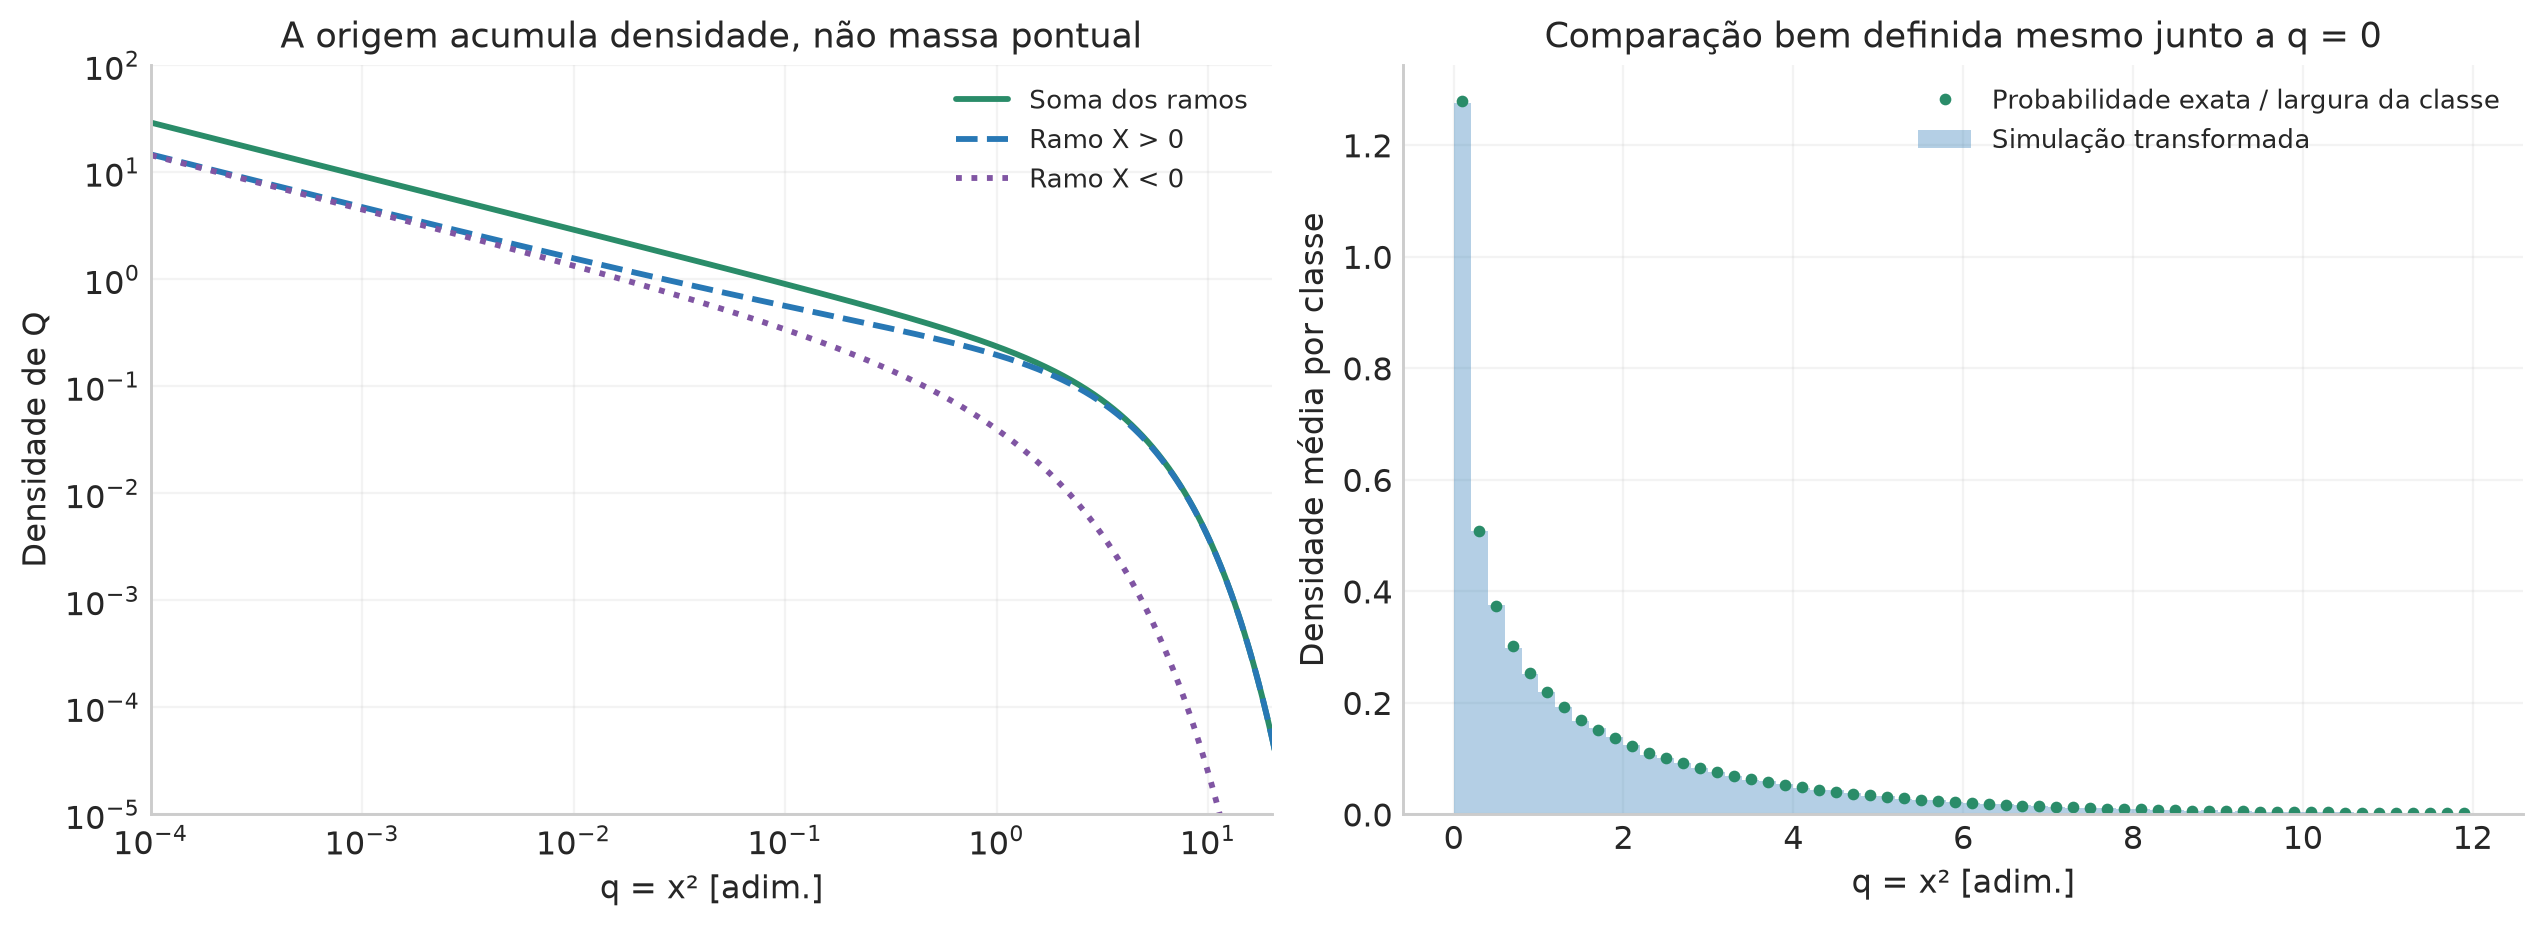

| Quantidade | Valor |
| --- | --- |
| Massa do ramo positivo | 0.788145 |
| Massa do ramo negativo | 0.211855 |
| (E[X])² | 0.640000 |
| E[X²], exata | 1.640000 |
| E[X²], simulação | 1.646738 |

In [16]:
mu_quad, sigma_quad = 0.8, 1.0

def pdf_quadrado(q, mu, sigma):
    """Densidade exata de Q=X² para X normal; soma os dois ramos inversos."""
    q = np.asarray(q, dtype=float)
    out = np.zeros_like(q)
    pos = q > 0
    raiz = np.sqrt(q[pos])
    out[pos] = (norm.pdf(raiz, mu, sigma)+norm.pdf(-raiz, mu, sigma))/(2*raiz)
    out[q == 0] = np.inf  # Valor da densidade no limite; a massa pontual é zero.
    return out

def cdf_quadrado(q, mu, sigma):
    raiz = np.sqrt(np.maximum(np.asarray(q, dtype=float), 0))
    return norm.cdf((raiz-mu)/sigma)-norm.cdf((-raiz-mu)/sigma)

qg = np.geomspace(1e-4, 25, 1500)
f_mais = norm.pdf(np.sqrt(qg), mu_quad, sigma_quad)/(2*np.sqrt(qg))
f_menos = norm.pdf(-np.sqrt(qg), mu_quad, sigma_quad)/(2*np.sqrt(qg))
referencia_ncx2 = ncx2.pdf(qg/sigma_quad**2, 1, (mu_quad/sigma_quad)**2)/sigma_quad**2
conferir('Quadrado: soma de ramos versus qui-quadrado não central', pdf_quadrado(qg, mu_quad, sigma_quad), referencia_ncx2)
integral_quad = quad(lambda q: float(pdf_quadrado(q, mu_quad, sigma_quad)), 0, np.inf, epsabs=1e-9)[0]
conferir('Quadrado: singularidade integrável e normalização', integral_quad, 1)

rng_quad = np.random.default_rng(SEMENTE+6)
X_quad = rng_quad.normal(mu_quad, sigma_quad, 150000)
Q_quad = X_quad**2
bordas_q = np.linspace(0, 12, 61)
larguras_q = np.diff(bordas_q)
centros_q = (bordas_q[:-1]+bordas_q[1:])/2
# Dividimos pelo número TOTAL de amostras: não renormalizamos a cauda fora do gráfico.
hist_q = np.histogram(Q_quad, bins=bordas_q)[0]/len(Q_quad)/larguras_q
media_classe_q = np.diff(cdf_quadrado(bordas_q, mu_quad, sigma_quad))/larguras_q

fig, ax = plt.subplots(1, 2, figsize=(12, 4.3), layout='constrained')
ax[0].loglog(qg, f_mais+f_menos, color=VERDE, label='Soma dos ramos')
ax[0].loglog(qg, f_mais, '--', color=AZUL, label='Ramo X > 0')
ax[0].loglog(qg, f_menos, ':', color=ROXO, label='Ramo X < 0')
ax[0].set(xlim=(1e-4, 20), ylim=(1e-5, 100), xlabel='q = x² [adim.]', ylabel='Densidade de Q', title='A origem acumula densidade, não massa pontual')
ax[0].legend()
ax[1].bar(centros_q, hist_q, width=larguras_q, alpha=0.35, color=AZUL, label='Simulação transformada')
ax[1].plot(centros_q, media_classe_q, 'o', ms=3, color=VERDE, label='Probabilidade exata / largura da classe')
ax[1].set(xlabel='q = x² [adim.]', ylabel='Densidade média por classe', title='Comparação bem definida mesmo junto a q = 0')
ax[1].legend()
mostrar_figura(fig, '14_transformacao_dois_ramos')
tabela(['Quantidade', 'Valor'], [
    ['Massa do ramo positivo', f'{norm.cdf(mu_quad/sigma_quad):.6f}'],
    ['Massa do ramo negativo', f'{norm.cdf(-mu_quad/sigma_quad):.6f}'],
    ['(E[X])²', f'{mu_quad**2:.6f}'],
    ['E[X²], exata', f'{mu_quad**2+sigma_quad**2:.6f}'],
    ['E[X²], simulação', f'{Q_quad.mean():.6f}'],
])

### 2.4 Ponte cosmológica: distância de luminosidade e redshift

Nos exemplos de likelihood do livro, $z_i$ designa o sinal latente. Aqui vou escrever **$z_{\rm cos}$ para redshift**, evitando confundir duas notações diferentes.

Fixando uma cosmologia plana $\Lambda$CDM, desprezando radiação nesta faixa,
$$D_L(z_{\rm cos};H_0,\Omega_m)=\frac{c}{H_0}(1+z_{\rm cos})\int_0^{z_{\rm cos}}\frac{du}{E(u)},$$
$$E(u)=\sqrt{\Omega_m(1+u)^3+1-\Omega_m}.$$
Sua derivada é
$$\frac{dD_L}{dz_{\rm cos}}=\frac{c}{H_0}\left[\int_0^{z_{\rm cos}}\frac{du}{E(u)}+\frac{1+z_{\rm cos}}{E(z_{\rm cos})}\right].$$

Para uma densidade **ilustrativa** de distância $f_D(D_L)$, a densidade induzida em redshift, nessa cosmologia fixa, é
$$\boxed{f_z(z_{\rm cos})=f_D[D_L(z_{\rm cos})]\left|\frac{dD_L}{dz_{\rm cos}}\right|.}$$
Note que usamos a derivada direta porque estamos transformando de distância para redshift. Vamos comparar com $D_L\simeq cz_{\rm cos}/H_0$, válida em baixo redshift.

**Ligação com Peak Sirens.** Galáxias são organizadas em faixas de redshift e GW em faixas de distância de luminosidade. A correspondência entre essas coordenadas depende da cosmologia. Esta transformação de uma única densidade não implementa Peak Sirens nem substitui a análise de correlações: serve para entender a correspondência radial.

Se $f_D$ fosse uma posterior de um evento obtida com uma prior específica, transformá-la continuaria produzindo uma posterior induzida. Isso não a converteria automaticamente em uma likelihood cosmológica; a prior usada na inferência original precisaria ser considerada.

| Mediana de redshift induzida por D_L mediana = 500 Mpc | Valor |
| --- | --- |
| ΛCDM fixa | 0.108044 |
| Aproximação linear | 0.116747 |

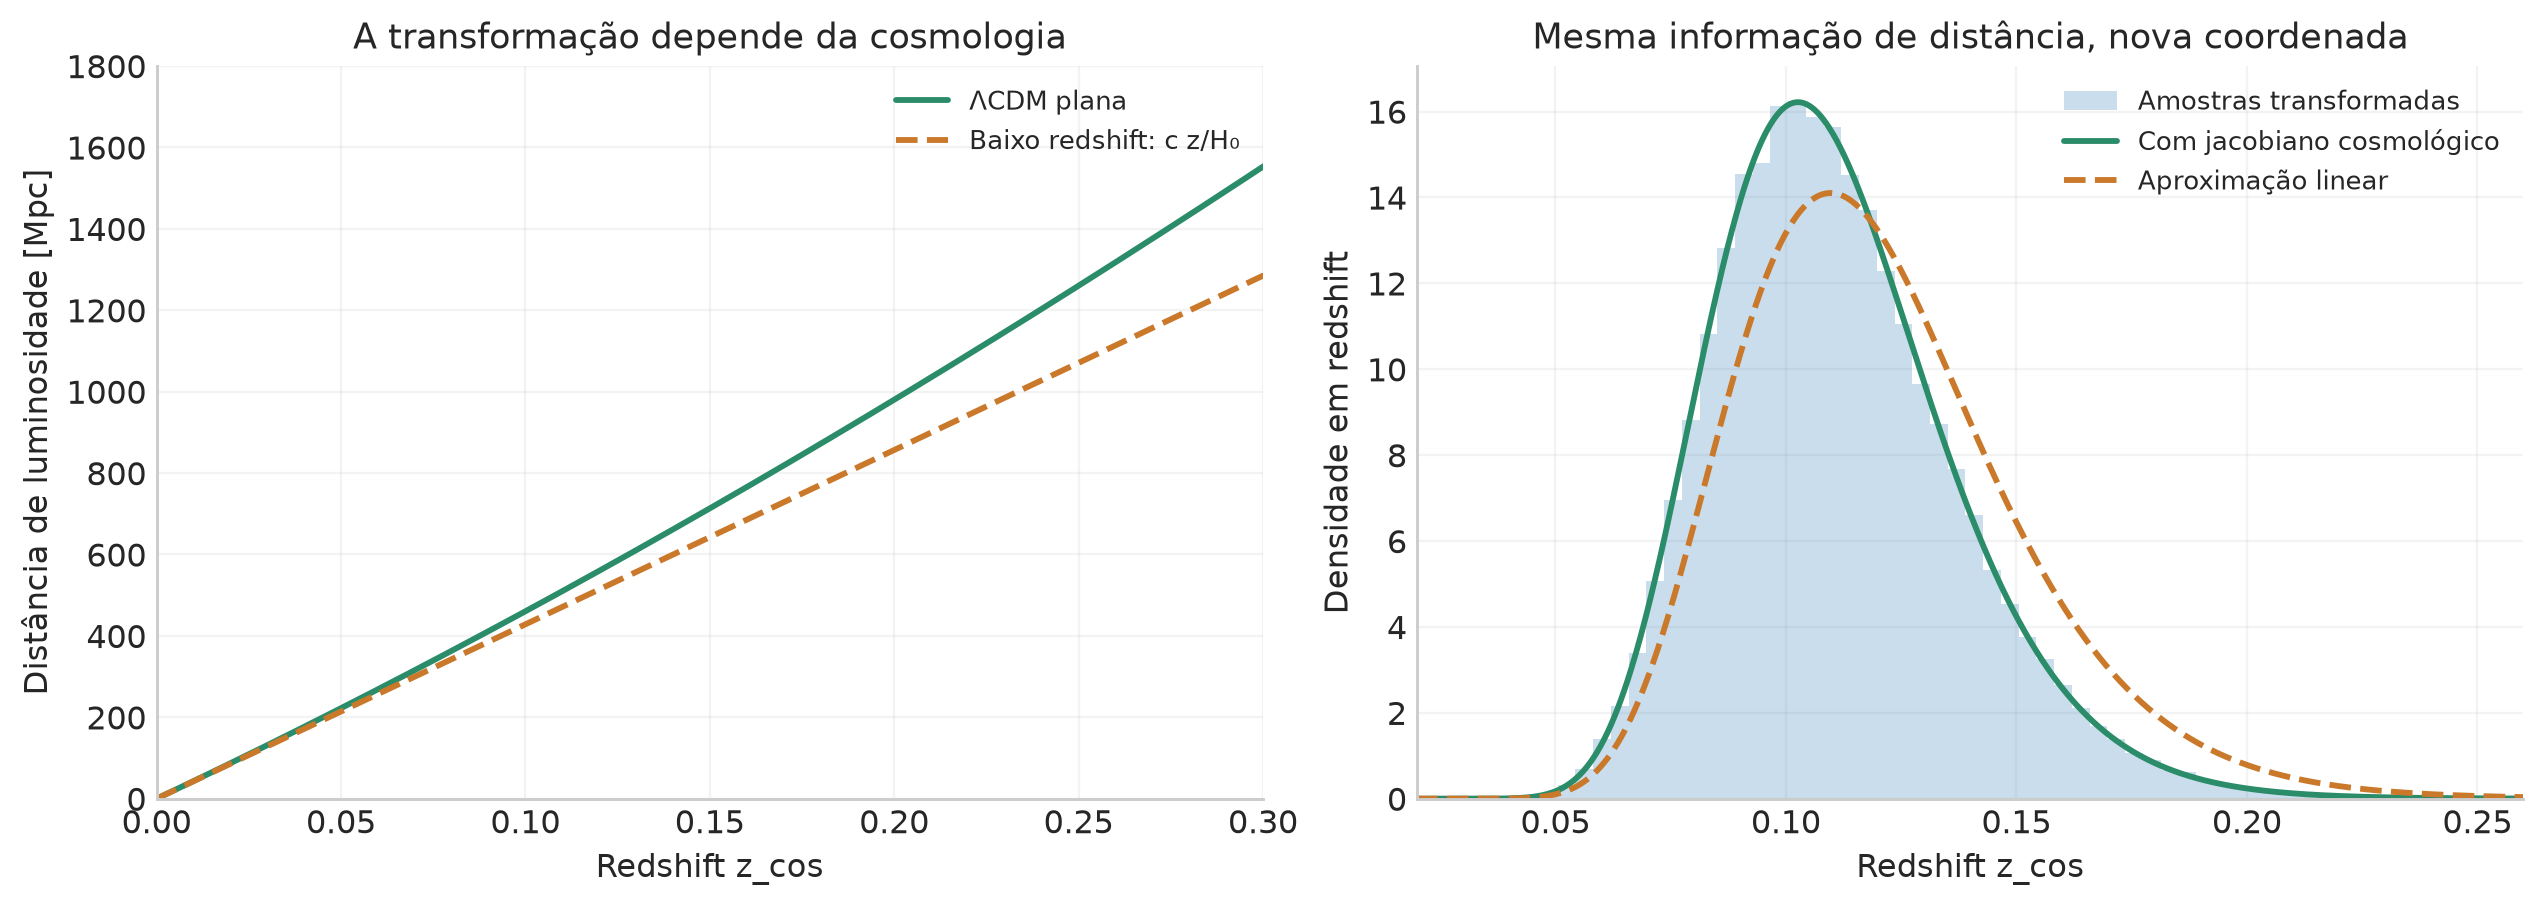

In [17]:
c_luz, H0_cos, Omega_m = 299792.458, 70.0, 0.3  # km/s; km/s/Mpc; adimensional.
z_cos_grade = np.linspace(0, 1.5, 6001)
E_cos = np.sqrt(Omega_m*(1+z_cos_grade)**3+1-Omega_m)
integral_cos = cumulative_trapezoid(1/E_cos, x=z_cos_grade, initial=0)
DL_cos = (c_luz/H0_cos)*(1+z_cos_grade)*integral_cos
dDL_dz = (c_luz/H0_cos)*(integral_cos+(1+z_cos_grade)/E_cos)

# Densidade de distância inventada apenas para este exemplo; não vem de um evento LVK.
dist_DL = lognorm(s=0.25, scale=500.0)
fz_cos = dist_DL.pdf(DL_cos)*dDL_dz
DL_linear = (c_luz/H0_cos)*z_cos_grade
fz_linear = dist_DL.pdf(DL_linear)*(c_luz/H0_cos)
norma_cos = simpson(fz_cos, x=z_cos_grade)
conferir('Cosmologia: massa preservada na faixa usada', norma_cos, dist_DL.cdf(DL_cos[-1]), rtol=2e-6)
# Uma distância também é conferida por quadratura adaptativa, independente da grade cumulativa.
z_ref = 0.2
DL_ref = (c_luz/H0_cos)*(1+z_ref)*quad(lambda z: 1/np.sqrt(Omega_m*(1+z)**3+1-Omega_m), 0, z_ref)[0]
conferir('Distância cosmológica: quadratura versus grade', np.interp(z_ref, z_cos_grade, DL_cos), DL_ref, rtol=2e-6)

rng_cos = np.random.default_rng(SEMENTE+7)
DL_amostras = dist_DL.rvs(size=100000, random_state=rng_cos)
assert DL_amostras.max() < DL_cos[-1]  # A interpolação inversa deve cobrir as amostras.
z_amostras = np.interp(DL_amostras, DL_cos, z_cos_grade)
z_med_exato = np.interp(500.0, DL_cos, z_cos_grade)
z_med_linear = 500.0*H0_cos/c_luz
tabela(['Mediana de redshift induzida por D_L mediana = 500 Mpc', 'Valor'], [
    ['ΛCDM fixa', f'{z_med_exato:.6f}'], ['Aproximação linear', f'{z_med_linear:.6f}'],
])

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2), layout='constrained')
ax[0].plot(z_cos_grade, DL_cos, color=VERDE, label='ΛCDM plana')
ax[0].plot(z_cos_grade, DL_linear, '--', color=LARANJA, label='Baixo redshift: c z/H₀')
ax[0].set(xlim=(0, 0.3), ylim=(0, 1800), xlabel='Redshift z_cos', ylabel='Distância de luminosidade [Mpc]', title='A transformação depende da cosmologia')
ax[0].legend()
ax[1].hist(z_amostras, bins=70, density=True, alpha=0.25, color=AZUL, label='Amostras transformadas')
ax[1].plot(z_cos_grade, fz_cos, color=VERDE, label='Com jacobiano cosmológico')
ax[1].plot(z_cos_grade, fz_linear, '--', color=LARANJA, label='Aproximação linear')
ax[1].set(xlim=(0.02, 0.26), xlabel='Redshift z_cos', ylabel='Densidade em redshift', title='Mesma informação de distância, nova coordenada')
ax[1].legend()
mostrar_figura(fig, '15_distancia_redshift')

## Parte 3 — Do modelo físico à likelihood

**Slides 127–135 / Gregory §4.8.** Vamos explicitar as condições que às vezes ficam ocultas em $f_Z(z_i)$:
$$f_{Z_i}(z\mid x_i,\theta,M,I).$$
Essa é a distribuição do sinal prevista pelo modelo **antes de incorporar $y_i$**, com seus parâmetros fixados. Não é automaticamente uma posterior. Para incorporar a medida, usamos $p(z_i\mid y_i,x_i,\theta)\propto p(y_i\mid z_i)f_{Z_i}(z_i\mid x_i,\theta)$.

| Quantidade | Papel | Exemplo de movimento |
|:--|:--|:--|
| $x_i$ | Entrada / coordenada verdadeira do modelo | Tempo em que a posição é medida |
| $x_{i0}$ | Entrada nominal ou estimativa informada | Instante nominal do disparo |
| $\theta$ | Parâmetros compartilhados do modelo | Posição inicial, velocidade, aceleração |
| $m(x_i;\theta)$ | Relação funcional adotada | $h_0+v_0x_i-gx_i^2/2$ |
| $z_i$ | Sinal antes do erro instrumental | Posição física na realização considerada |
| $\epsilon_i$ | Dispersão do sinal em torno de $m$ | Variação não resolvida pelo modelo idealizado |
| $e_i$ | Erro de medição | Diferença entre posição registrada e física |
| $y_i=z_i+e_i$ | Dado observado | Posição registrada pelo instrumento |

Um parâmetro de ruído ou calibração também pode pertencer a $\theta$ se for desconhecido. Nos três exemplos, as escalas de dispersão serão conhecidas, para isolar a construção da likelihood. Todos os conjuntos de dados desta parte são simulados.

### 3.1 A equação geral e o caso determinístico

Se $Z_i$ e $E_i$ são independentes condicionados ao modelo,
$$f_{Y_i}(y_i\mid x_i,\theta)=\iint dz_i\,de_i\,f_{Z_i}(z_i\mid x_i,\theta)f_{E_i}(e_i)\delta(y_i-z_i-e_i)$$
$$\boxed{=\int dz_i\, f_{Z_i}(z_i\mid x_i,\theta)f_{E_i}(y_i-z_i).}$$

Cada possível sinal exige um erro $e_i=y_i-z_i$ para explicar a medida. Somamos essas possibilidades ponderadas. A expressão é uma convolução, não uma avaliação da posterior em $z_i$.

Se o modelo é determinístico para $x_i,\theta$ fixos,
$$f_{Z_i}(z_i\mid x_i,\theta)=\delta[z_i-m(x_i;\theta)],\qquad f_{Y_i}(y_i\mid x_i,\theta)=f_{E_i}[y_i-m(x_i;\theta)].$$
Com erros gaussianos independentes, a likelihood é o produto das densidades gaussianas dos resíduos. O valor determinístico de $z_i$ não implica dados sem ruído. Além disso, incerteza em $\theta$ é tratada pela posterior dos parâmetros; não devemos contá-la novamente como um ruído adicional na likelihood.

### 3.2 Caso 1 — Dispersão do sinal: relação de Hubble com velocidades peculiares

Neste exemplo didático de baixo redshift, $x_i=d_i$ é uma distância conhecida em Mpc, $\theta=H_0$ tem unidades de km/s/Mpc, e o modelo médio é $m(d_i;H_0)=H_0d_i$. O sinal latente é a velocidade de recessão com uma contribuição peculiar:
$$z_i=H_0d_i+\epsilon_i,\quad \epsilon_i\sim\mathcal N(0,\sigma_v^2),$$
$$y_i=z_i+e_i,\quad e_i\sim\mathcal N(0,\sigma_{y,i}^2).$$
Usamos erros e velocidades peculiares independentes neste exercício. Correlações físicas de velocidades exigiriam uma matriz de covariância.

A convolução de duas gaussianas independentes é gaussiana. Podemos demonstrar isso multiplicando as funções características:
$$\phi_Y(t)=e^{itH_0d_i-\sigma_v^2t^2/2}\,e^{-\sigma_{y,i}^2t^2/2}
=e^{itH_0d_i-(\sigma_v^2+\sigma_{y,i}^2)t^2/2}.$$
Portanto,
$$\boxed{Y_i\mid d_i,H_0\sim\mathcal N(H_0d_i,\sigma_v^2+\sigma_{y,i}^2).}$$

Vamos inferir $H_0$ com prior uniforme em $[40,100]$ km/s/Mpc e comparar com uma análise que ignora $\sigma_v$. Não pretendemos estimar $H_0$ real: queremos ver como a hipótese sobre a dispersão afeta a precisão que atribuímos ao ajuste.

| Análise | Média H₀ | IC central 95% [km/s/Mpc] | Largura |
| --- | --- | --- | --- |
| Com dispersão peculiar | 69.737 | [68.458, 71.016] | 2.559 |
| Ignorando dispersão peculiar | 69.664 | [69.253, 70.074] | 0.821 |

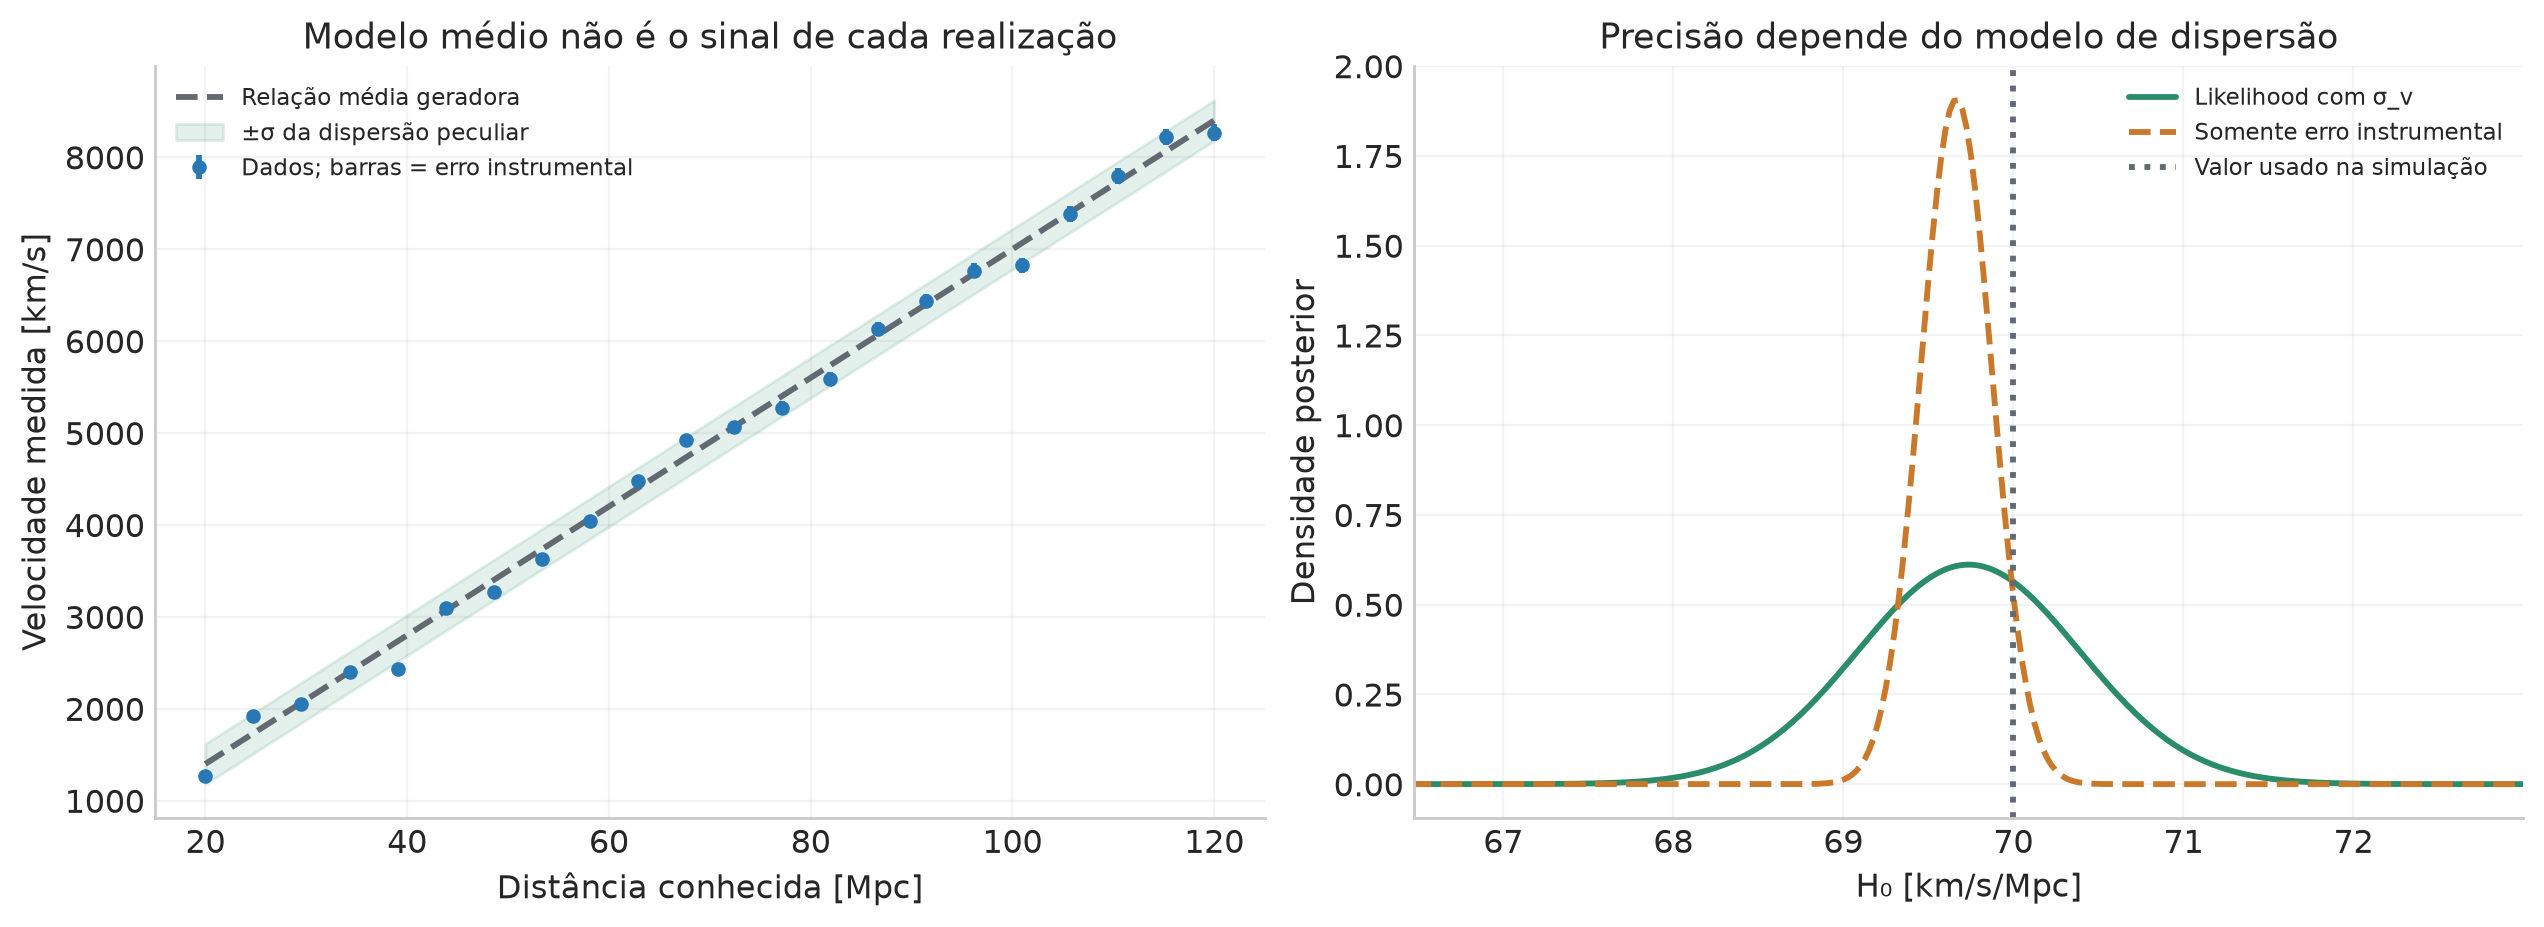

In [18]:
rng_h1 = np.random.default_rng(SEMENTE+8)
H0_verdade = 70.0
d_h1 = np.linspace(20, 120, 22)
sigma_y_h1 = np.linspace(45, 90, len(d_h1))
sigma_v_h1 = 220.0
z_h1 = H0_verdade*d_h1+rng_h1.normal(0, sigma_v_h1, len(d_h1))
y_h1 = z_h1+rng_h1.normal(0, sigma_y_h1)
H_grade = np.linspace(40, 100, 2401)

def loglike_hubble(H, distancia_nominal, velocidades, sigma_y, sigma_v=0.0, sigma_d=0.0):
    """Likelihood marginal para a relação linear, com escalas conhecidas e fontes independentes.

    H pode ser uma grade; a última dimensão identifica os dados. As unidades são
    km/s/Mpc, Mpc e km/s, de modo que todos os termos da variância são (km/s)².
    """
    H = np.asarray(H)
    media = H[..., None]*np.asarray(distancia_nominal)
    variancia = np.asarray(sigma_y)**2+np.asarray(sigma_v)**2+(H[..., None]*np.asarray(sigma_d))**2
    residuos = np.asarray(velocidades)-media
    return -0.5*np.sum(residuos**2/variancia+np.log(2*np.pi*variancia), axis=-1)

logL_h1 = loglike_hubble(H_grade, d_h1, y_h1, sigma_y_h1, sigma_v_h1)
logL_h1_sem = loglike_hubble(H_grade, d_h1, y_h1, sigma_y_h1)
post_h1 = normalizar_logdensidade(H_grade, logL_h1)
post_h1_sem = normalizar_logdensidade(H_grade, logL_h1_sem)

# Conferência analítica: como a variância é conhecida e não depende de H, a forma é gaussiana.
s2_h1 = sigma_y_h1**2+sigma_v_h1**2
H_pesado = np.sum(d_h1*y_h1/s2_h1)/np.sum(d_h1**2/s2_h1)
sig_H_pesado = 1/np.sqrt(np.sum(d_h1**2/s2_h1))
normalizacao_prior = norm.cdf((100-H_pesado)/sig_H_pesado)-norm.cdf((40-H_pesado)/sig_H_pesado)
post_h1_analitica = norm.pdf(H_grade, H_pesado, sig_H_pesado)/normalizacao_prior
conferir('Caso 1: posterior numérica versus solução gaussiana truncada', post_h1, post_h1_analitica, atol=1e-10)

linhas = []
for nome, post in [('Com dispersão peculiar', post_h1), ('Ignorando dispersão peculiar', post_h1_sem)]:
    media, moda, limites = resumo_densidade(H_grade, post)
    linhas.append([nome, f'{media:.3f}', f'[{limites[0]:.3f}, {limites[1]:.3f}]', f'{np.diff(limites)[0]:.3f}'])
tabela(['Análise', 'Média H₀', 'IC central 95% [km/s/Mpc]', 'Largura'], linhas)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.3), layout='constrained')
ax[0].errorbar(d_h1, y_h1, yerr=sigma_y_h1, fmt='o', ms=4, color=AZUL, label='Dados; barras = erro instrumental')
ax[0].plot(d_h1, H0_verdade*d_h1, '--', color=CINZA, label='Relação média geradora')
ax[0].fill_between(d_h1, H0_verdade*d_h1-sigma_v_h1, H0_verdade*d_h1+sigma_v_h1, color=VERDE, alpha=0.13, label='±σ da dispersão peculiar')
ax[0].set(xlabel='Distância conhecida [Mpc]', ylabel='Velocidade medida [km/s]', title='Modelo médio não é o sinal de cada realização')
ax[0].legend(fontsize=8)
ax[1].plot(H_grade, post_h1, color=VERDE, label='Likelihood com σ_v')
ax[1].plot(H_grade, post_h1_sem, '--', color=LARANJA, label='Somente erro instrumental')
ax[1].axvline(H0_verdade, color=CINZA, ls=':', label='Valor usado na simulação')
ax[1].set(xlim=(H_pesado-5*sig_H_pesado, H_pesado+5*sig_H_pesado), xlabel='H₀ [km/s/Mpc]', ylabel='Densidade posterior', title='Precisão depende do modelo de dispersão')
ax[1].legend(fontsize=8)
mostrar_figura(fig, '16_likelihood_caso1')

**Interpretação.** As barras instrumentais pequenas não explicam toda a dispersão dos pontos. Ignorar a componente peculiar tende a atribuir precisão excessiva à inferência. Isso não implica que, em toda simulação, o valor central fique necessariamente mais distante do verdadeiro; a comparação principal é a incerteza declarada.

Vamos também separar $f_Z$ da posterior em $Z$. Fixando $H_0$ no valor gerador e escolhendo um ponto, temos uma distribuição do sinal $Z\sim\mathcal N(\mu_z,s_z^2)$ e uma medida $y$ com variância $s_e^2$. A atualização gaussiana fornece
$$s_{z\mid y}^2=\left(s_z^{-2}+s_e^{-2}\right)^{-1},\qquad
\mu_{z\mid y}=s_{z\mid y}^2\left(\frac{\mu_z}{s_z^2}+\frac y{s_e^2}\right).$$
A posterior muda depois de observar $y$. Esta conta mantém $H_0$ fixo; se quiséssemos incluir sua incerteza, também teríamos de marginalizar $H_0$.

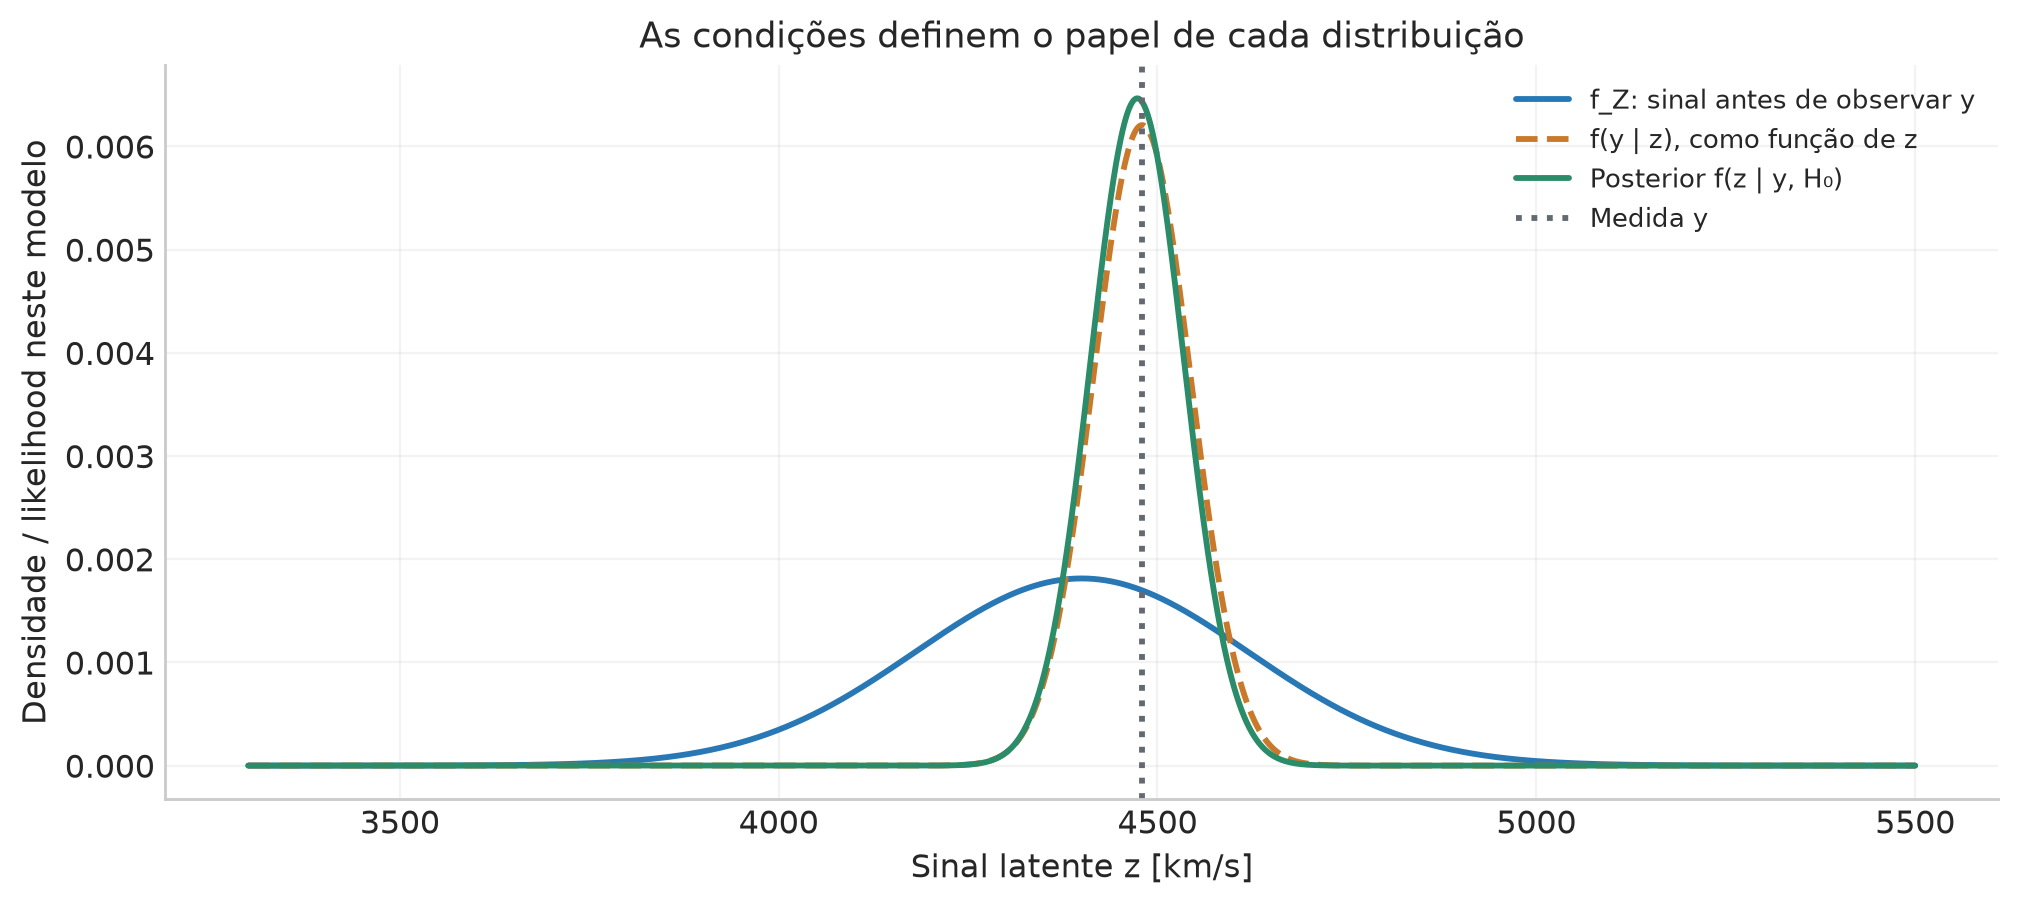

In [19]:
i_z = 9
mu_z = H0_verdade*d_h1[i_z]
s_z, s_e, y_z = sigma_v_h1, sigma_y_h1[i_z], y_h1[i_z]
s_post_z = 1/np.sqrt(1/s_z**2+1/s_e**2)
mu_post_z = s_post_z**2*(mu_z/s_z**2+y_z/s_e**2)
zg = np.linspace(min(mu_z-5*s_z, y_z-5*s_e), max(mu_z+5*s_z, y_z+5*s_e), 2001)
fz_modelo = norm.pdf(zg, mu_z, s_z)
like_y_dado_z = norm.pdf(y_z, zg, s_e)
post_z_numerica = normalizar_logdensidade(zg, norm.logpdf(zg, mu_z, s_z)+norm.logpdf(y_z, zg, s_e))
post_z_analitica = norm.pdf(zg, mu_post_z, s_post_z)
conferir('Sinal latente: produto normalizado versus atualização analítica', post_z_numerica, post_z_analitica)
conv_quadratura = quad(lambda z: norm.pdf(z, mu_z, s_z)*norm.pdf(y_z, z, s_e), mu_z-10*s_z, mu_z+10*s_z, epsabs=1e-12)[0]
conferir('Caso 1: convolução por quadratura', conv_quadratura, norm.pdf(y_z, mu_z, np.hypot(s_z, s_e)))
fig, ax = plt.subplots(figsize=(9.5, 4.2), layout='constrained')
ax.plot(zg, fz_modelo, color=AZUL, label='f_Z: sinal antes de observar y')
ax.plot(zg, like_y_dado_z, '--', color=LARANJA, label='f(y | z), como função de z')
ax.plot(zg, post_z_numerica, color=VERDE, label='Posterior f(z | y, H₀)')
ax.axvline(y_z, color=CINZA, ls=':', label='Medida y')
ax.set(xlabel='Sinal latente z [km/s]', ylabel='Densidade / likelihood neste modelo', title='As condições definem o papel de cada distribuição')
ax.legend()
mostrar_figura(fig, '17_sinal_latente_posterior')

Neste modelo de localização gaussiano, $f(y\mid z)$ também integra 1 em $z$, mas isso é uma propriedade particular dessa forma funcional, não uma exigência geral para likelihoods. A posterior é identificada pela atualização e pelo condicionamento, não pelo formato de sino da curva.

### 3.3 Caso 2 — Entrada incerta: calibração de uma relação tensão–corrente

Agora $x_i$ é a corrente verdadeira, em mA; $x_{i0}$ é o valor nominal ajustado na fonte; $y_i$ é a tensão medida, em V; $\theta=(A,B)$ reúne um offset de tensão e uma resistência, com $B$ em V/mA = kΩ. O sinal determinístico é
$$z_i=A+Bx_i.$$
O modelo da fonte fornece $X_i\mid x_{i0}\sim\mathcal N(x_{i0},\sigma_{x,i}^2)$. Essa é uma distribuição assumida para a corrente realizada ao redor do comando nominal. Não estamos invertendo automaticamente a distribuição de erro de uma medida de corrente.

Como $Z_i=A+BX_i$, a transformação linear dá média $A+Bx_{i0}$ e variância $B^2\sigma_{x,i}^2$. Somando o erro instrumental da tensão,
$$\boxed{Y_i\mid x_{i0},A,B\sim\mathcal N(A+Bx_{i0},\sigma_{y,i}^2+B^2\sigma_{x,i}^2).}$$

**Por que a inclinação aparece na variância?** Uma mesma variação horizontal $\delta x$ causa uma variação vertical $B\delta x$. Quanto maior a inclinação, maior a dispersão em tensão para o mesmo ruído de corrente.

Adotamos priors independentes uniformes em $A\in[-2,2]$ V e $B\in[0.8,2.8]$ kΩ. A log-likelihood, mantendo todos os termos que dependem dos parâmetros, é
$$\ln L(A,B)=-\frac12\sum_i\left[\frac{(y_i-A-Bx_{i0})^2}{s_i^2(B)}+\ln(2\pi s_i^2(B))\right].$$
Como $s_i^2(B)=\sigma_{y,i}^2+B^2\sigma_{x,i}^2$, o termo logarítmico **não é constante em $B$**. Minimizar apenas o resíduo ponderado favoreceria aumentar a dispersão sem pagar pela diminuição da altura da densidade.

| Função utilizada | Média A [V] | Média B [kΩ] | Intervalo central 95% de B |
| --- | --- | --- | --- |
| Completa | 0.3800 | 1.7831 | [1.6410, 1.9425] |
| Ignora σ_x | 0.3994 | 1.7766 | [1.7395, 1.8134] |
| Omite log da variância | 0.1354 | 1.8646 | [1.7075, 2.0428] |

A curva que omite a normalização é apenas uma função incorreta renormalizada na grade; não é a posterior do modelo declarado.


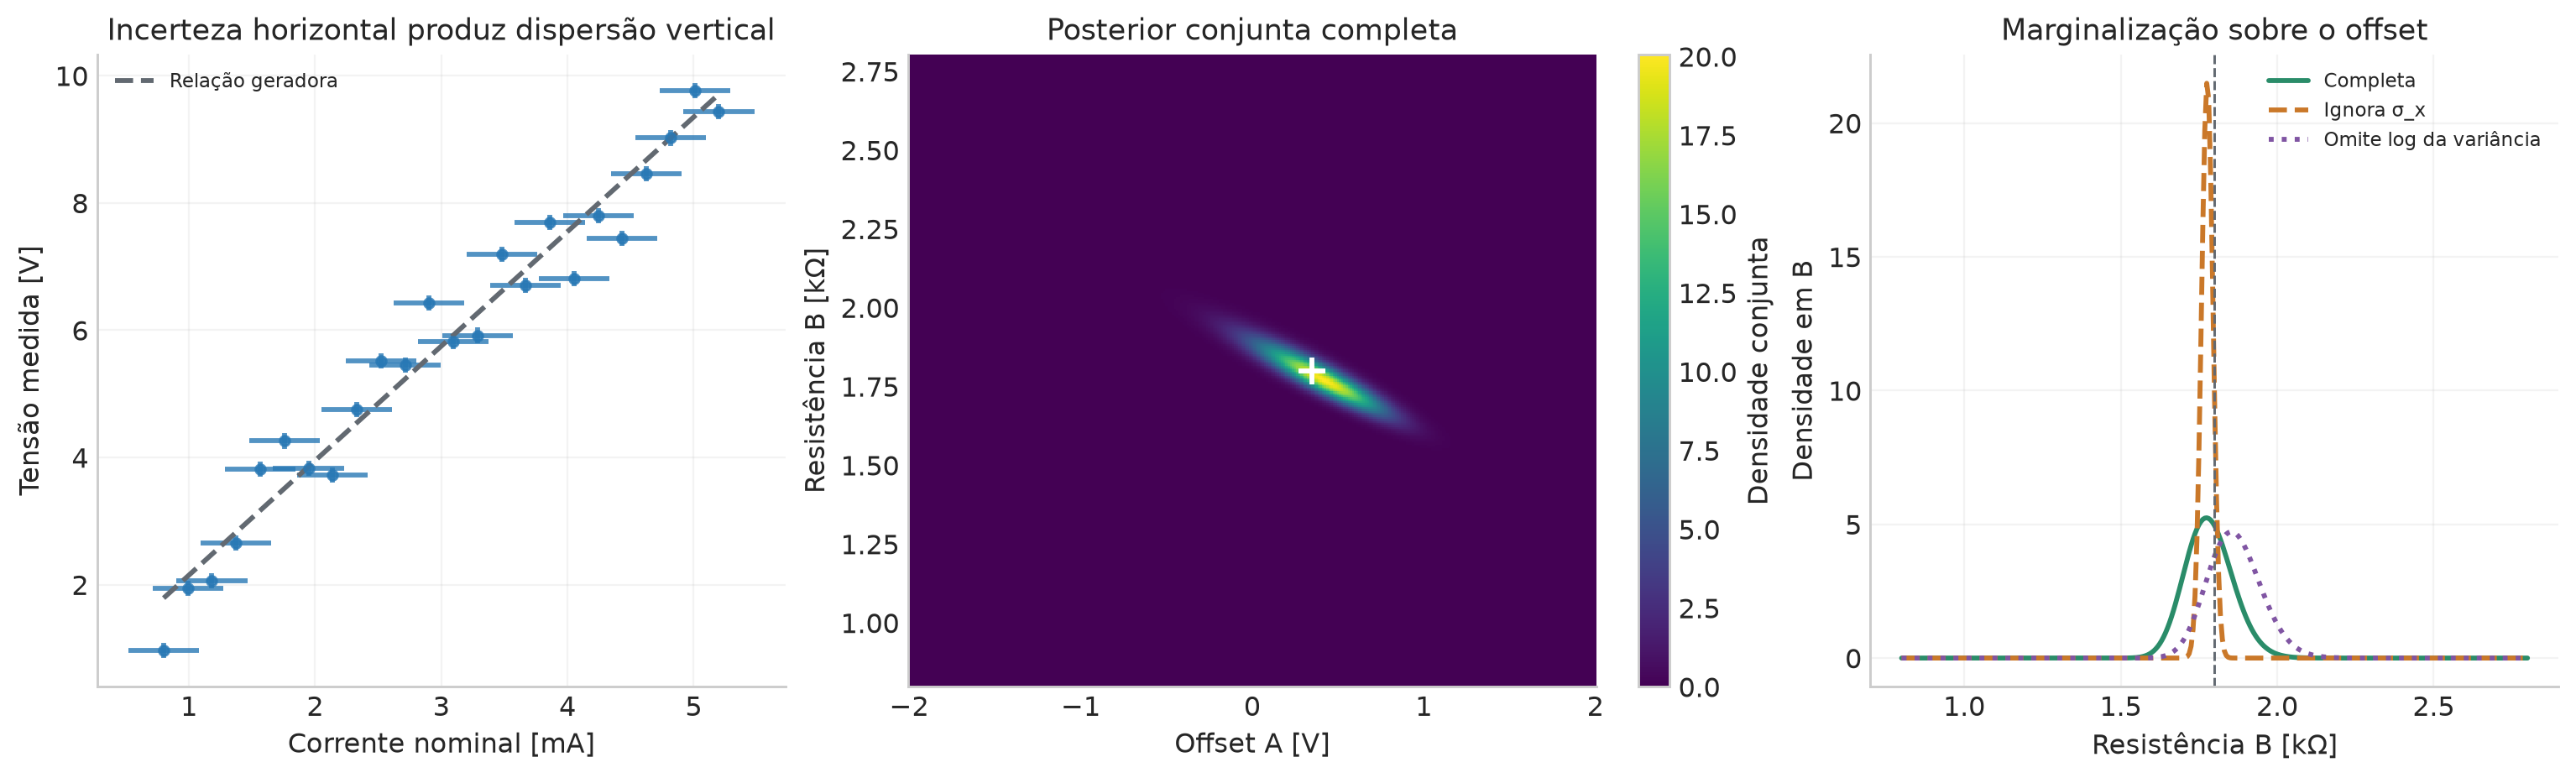

In [20]:
rng_ohm = np.random.default_rng(SEMENTE+9)
A_verdade, B_verdade = 0.35, 1.8
x0_ohm = np.linspace(0.8, 5.2, 24)  # Correntes nominais em mA.
sx_ohm = np.full(len(x0_ohm), 0.28)
sy_ohm = np.full(len(x0_ohm), 0.12)
x_real_ohm = rng_ohm.normal(x0_ohm, sx_ohm)
z_ohm = A_verdade+B_verdade*x_real_ohm
y_ohm = z_ohm+rng_ohm.normal(0, sy_ohm)

def loglike_reta(A, B, x0, y, sy, sx=0.0, sm=0.0, incluir_normalizacao=True):
    """Log-likelihood da reta depois de integrar entrada e dispersão latentes.

    A e B podem ser grades com broadcasting. A última dimensão corresponde aos dados.
    Desligar a normalização serve SOMENTE para demonstrar uma função de ajuste incorreta.
    """
    A, B = np.broadcast_arrays(np.asarray(A), np.asarray(B))
    residuos = np.asarray(y)-(A[..., None]+B[..., None]*np.asarray(x0))
    variancia = np.asarray(sy)**2+np.asarray(sm)**2+(B[..., None]*np.asarray(sx))**2
    termos = residuos**2/variancia
    if incluir_normalizacao:
        termos = termos+np.log(2*np.pi*variancia)
    return -0.5*np.sum(termos, axis=-1)

def posterior_reta_em_grade(A_grade, B_grade, logL):
    """Prior uniforme no retângulo informado; densidade 2D normalizada por integração."""
    relativa = np.exp(logL-np.max(logL))
    norma = simpson(simpson(relativa, x=A_grade, axis=1), x=B_grade)
    conjunta = relativa/norma
    marginal_A = simpson(conjunta, x=B_grade, axis=0)
    marginal_B = simpson(conjunta, x=A_grade, axis=1)
    return conjunta, marginal_A, marginal_B

A_grade = np.linspace(-2, 2, 321)
B_grade = np.linspace(0.8, 2.8, 321)
AA, BB = np.meshgrid(A_grade, B_grade)
analises_ohm = {}
for nome, sx, normalizar in [
    ('Completa', sx_ohm, True), ('Ignora σ_x', 0.0, True), ('Omite log da variância', sx_ohm, False)
]:
    ll = loglike_reta(AA, BB, x0_ohm, y_ohm, sy_ohm, sx, incluir_normalizacao=normalizar)
    analises_ohm[nome] = posterior_reta_em_grade(A_grade, B_grade, ll)

post_AB, post_A, post_B = analises_ohm['Completa']
conferir('Caso 2: marginal A normalizada', simpson(post_A, x=A_grade), 1)
conferir('Caso 2: marginal B normalizada', simpson(post_B, x=B_grade), 1)
linhas = []
for nome, (_, pa, pb) in analises_ohm.items():
    ma, _, ia = resumo_densidade(A_grade, pa)
    mb, _, ib = resumo_densidade(B_grade, pb)
    linhas.append([nome, f'{ma:.4f}', f'{mb:.4f}', f'[{ib[0]:.4f}, {ib[1]:.4f}]'])
tabela(['Função utilizada', 'Média A [V]', 'Média B [kΩ]', 'Intervalo central 95% de B'], linhas)
print('A curva que omite a normalização é apenas uma função incorreta renormalizada na grade; não é a posterior do modelo declarado.')

fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.3), layout='constrained')
ax[0].errorbar(x0_ohm, y_ohm, xerr=sx_ohm, yerr=sy_ohm, fmt='o', ms=4, color=AZUL, alpha=0.8)
ax[0].plot(x0_ohm, A_verdade+B_verdade*x0_ohm, '--', color=CINZA, label='Relação geradora')
ax[0].set(xlabel='Corrente nominal [mA]', ylabel='Tensão medida [V]', title='Incerteza horizontal produz dispersão vertical')
ax[0].legend(fontsize=8)
im = ax[1].pcolormesh(A_grade, B_grade, post_AB, shading='auto', cmap='viridis', rasterized=True)
ax[1].plot(A_verdade, B_verdade, '+', color='white', ms=11, mew=2, label='Parâmetros geradores')
ax[1].set(xlabel='Offset A [V]', ylabel='Resistência B [kΩ]', title='Posterior conjunta completa')
fig.colorbar(im, ax=ax[1], label='Densidade conjunta')
for (nome, (_, pa, pb)), cor, estilo in zip(analises_ohm.items(), [VERDE, LARANJA, ROXO], ['-', '--', ':']):
    ax[2].plot(B_grade, pb, linestyle=estilo, color=cor, label=nome)
ax[2].axvline(B_verdade, color=CINZA, ls='--', lw=1)
ax[2].set(xlabel='Resistência B [kΩ]', ylabel='Densidade em B', title='Marginalização sobre o offset')
ax[2].legend(fontsize=8)
mostrar_figura(fig, '18_likelihood_caso2')

**Interpretação.** A inclinação e o offset ficam correlacionados na posterior: uma mudança em um pode compensar parcialmente a mudança no outro dentro da faixa de correntes observada. O painel final integra sobre $A$; não escolhe apenas o melhor $A$ para cada $B$.

Vamos conferir a fórmula integrando explicitamente uma corrente latente. Essa verificação também mostra o que faríamos quando não houvesse uma solução analítica simples:
$$f(y_i\mid x_{i0},A,B)=\int dx_i\,\mathcal N(x_i;x_{i0},\sigma_{x,i}^2)\,
\mathcal N(y_i;A+Bx_i,\sigma_{y,i}^2).$$

Para um modelo geral $m(x;\theta)$, o desenvolvimento $m(x)\simeq m(x_0)+m'(x_0)\delta x$ dá $\sigma_z^2\simeq[m'(x_0)]^2\sigma_x^2$. Se a curvatura for relevante, há também deslocamento da média, começando por $\tfrac12m''(x_0)\sigma_x^2$, e a distribuição pode deixar de ser gaussiana. Nessa situação, substituir somente a variância não resolve o problema completo.

In [21]:
# Quadratura independente para alguns pontos e parâmetros; integração em ±10σ da corrente.
linhas = []
for i, A_teste, B_teste in [(0, 0.35, 1.8), (9, 0.2, 1.9), (18, 0.5, 1.7)]:
    val_quad = quad(
        lambda x: norm.pdf(x, x0_ohm[i], sx_ohm[i])*norm.pdf(y_ohm[i], A_teste+B_teste*x, sy_ohm[i]),
        x0_ohm[i]-10*sx_ohm[i], x0_ohm[i]+10*sx_ohm[i], epsabs=1e-11
    )[0]
    val_analitico = norm.pdf(y_ohm[i], A_teste+B_teste*x0_ohm[i], np.hypot(sy_ohm[i], B_teste*sx_ohm[i]))
    conferir(f'Caso 2: integral sobre x no ponto {i}', val_quad, val_analitico)
    linhas.append([i, f'{val_quad:.9f}', f'{val_analitico:.9f}'])
tabela(['Ponto', 'Quadratura [V⁻¹]', 'Fórmula analítica [V⁻¹]'], linhas)

# A prior precisa cobrir a região apoiada pelos dados; conferimos a massa junto às bordas.
faixa_A = (A_grade < A_grade[0]+0.1) | (A_grade > A_grade[-1]-0.1)
faixa_B = (B_grade < B_grade[0]+0.05) | (B_grade > B_grade[-1]-0.05)
print('Densidade máxima nas bordas / pico (A, B):',
      f'{post_A[faixa_A].max()/post_A.max():.3g},', f'{post_B[faixa_B].max()/post_B.max():.3g}')

| Ponto | Quadratura [V⁻¹] | Fórmula analítica [V⁻¹] |
| --- | --- | --- |
| 0 | 0.218143794 | 0.218143794 |
| 9 | 0.454801139 | 0.454801139 |
| 18 | 0.800969493 | 0.800969493 |

Densidade máxima nas bordas / pico (A, B): 4.76e-11, 4.93e-20


### 3.4 Caso 3 — Homework: entrada incerta e dispersão do sinal

**Slide 135 / Gregory, equação (4.61).** Vamos demonstrar a expressão em vez de apenas acrescentar termos por analogia. O modelo linear completo é
$$X_i=x_{i0}+\delta x_i,\qquad Z_i=A+BX_i+\epsilon_i,\qquad Y_i=Z_i+e_i,$$
com $\delta x_i\sim\mathcal N(0,\sigma_{x,i}^2)$, $\epsilon_i\sim\mathcal N(0,\sigma_{\rm mod,i}^2)$ e $e_i\sim\mathcal N(0,\sigma_{y,i}^2)$, todos independentes.

Substituindo,
$$Y_i=A+Bx_{i0}+B\delta x_i+\epsilon_i+e_i.$$
A média é $A+Bx_{i0}$. Como os termos aleatórios são independentes, as variâncias somam. A soma é exatamente gaussiana porque todos os termos são gaussianos e entram linearmente:
$$\boxed{s_i^2=\sigma_{y,i}^2+\sigma_{\rm mod,i}^2+B^2\sigma_{x,i}^2.}$$

Podemos ver a mesma coisa **na integral**. Primeiro integramos $\epsilon_i$ e $e_i$, obtendo $s_{0,i}^2=\sigma_{\rm mod,i}^2+\sigma_{y,i}^2$. Escrevendo $r_i=y_i-A-Bx_{i0}$ e $\delta=x_i-x_{i0}$,
$$f(y_i\mid\theta)=\frac{1}{2\pi\sigma_{x,i}s_{0,i}}\int_{-\infty}^{\infty}
\exp\left[-\frac12\left(\frac{\delta^2}{\sigma_{x,i}^2}+\frac{(r_i-B\delta)^2}{s_{0,i}^2}\right)\right]d\delta.$$
Definimos $K=\sigma_{x,i}^{-2}+B^2/s_{0,i}^2$ e $b=Br_i/s_{0,i}^2$. Completando o quadrado,
$$\frac{\delta^2}{\sigma_{x,i}^2}+\frac{(r_i-B\delta)^2}{s_{0,i}^2}
=K\left(\delta-\frac bK\right)^2+\frac{r_i^2}{s_{0,i}^2+B^2\sigma_{x,i}^2}.$$
A integral do primeiro fator é $\sqrt{2\pi/K}$. O prefator resultante é $1/\sqrt{2\pi s_i^2}$. Assim,
$$f(y_i\mid x_{i0},A,B)=\frac{1}{\sqrt{2\pi s_i^2}}\exp\left[-\frac{(y_i-A-Bx_{i0})^2}{2s_i^2}\right].$$
Para observações condicionalmente independentes,
$$\boxed{L(A,B;D)=(2\pi)^{-n/2}\prod_i s_i^{-1}\exp\left[-\frac12\sum_i\frac{(y_i-A-Bx_{i0})^2}{s_i^2}\right].}$$

O limite $\sigma_x\to0$ recupera o caso 1; $\sigma_{\rm mod}\to0$ recupera o caso 2. Se ambas somem, ficamos com o caso determinístico e erro de medição. Se houver correlações entre as fontes, aparecem termos de covariância: a soma simples de variâncias depende da hipótese de independência.

**Exemplo físico.** Voltaremos à relação de Hubble, agora com distâncias incertas, velocidades peculiares e erro na velocidade medida. Usaremos $A=0$, $B=H_0$, $x_i=d_i$, $z_i=$ velocidade latente e $y_i=$ velocidade registrada. Assumimos que a informação externa de cada distância já é descrita por $D_i\mid I_i\sim\mathcal N(d_{i0},\sigma_{d,i}^2)$. Na pesquisa real, essa distribuição precisa ser derivada com as priors e a seleção apropriadas; aqui ela é parte declarada do experimento simulado.

| Análise | Média H₀ | IC central 95% [km/s/Mpc] | Largura |
| --- | --- | --- | --- |
| Completa | 72.282 | [69.667, 75.002] | 5.335 |
| Ignora distância incerta | 72.073 | [70.748, 73.398] | 2.650 |
| Ignora dispersão peculiar | 72.627 | [70.377, 74.980] | 4.603 |
| Somente instrumento | 72.073 | [71.668, 72.478] | 0.809 |

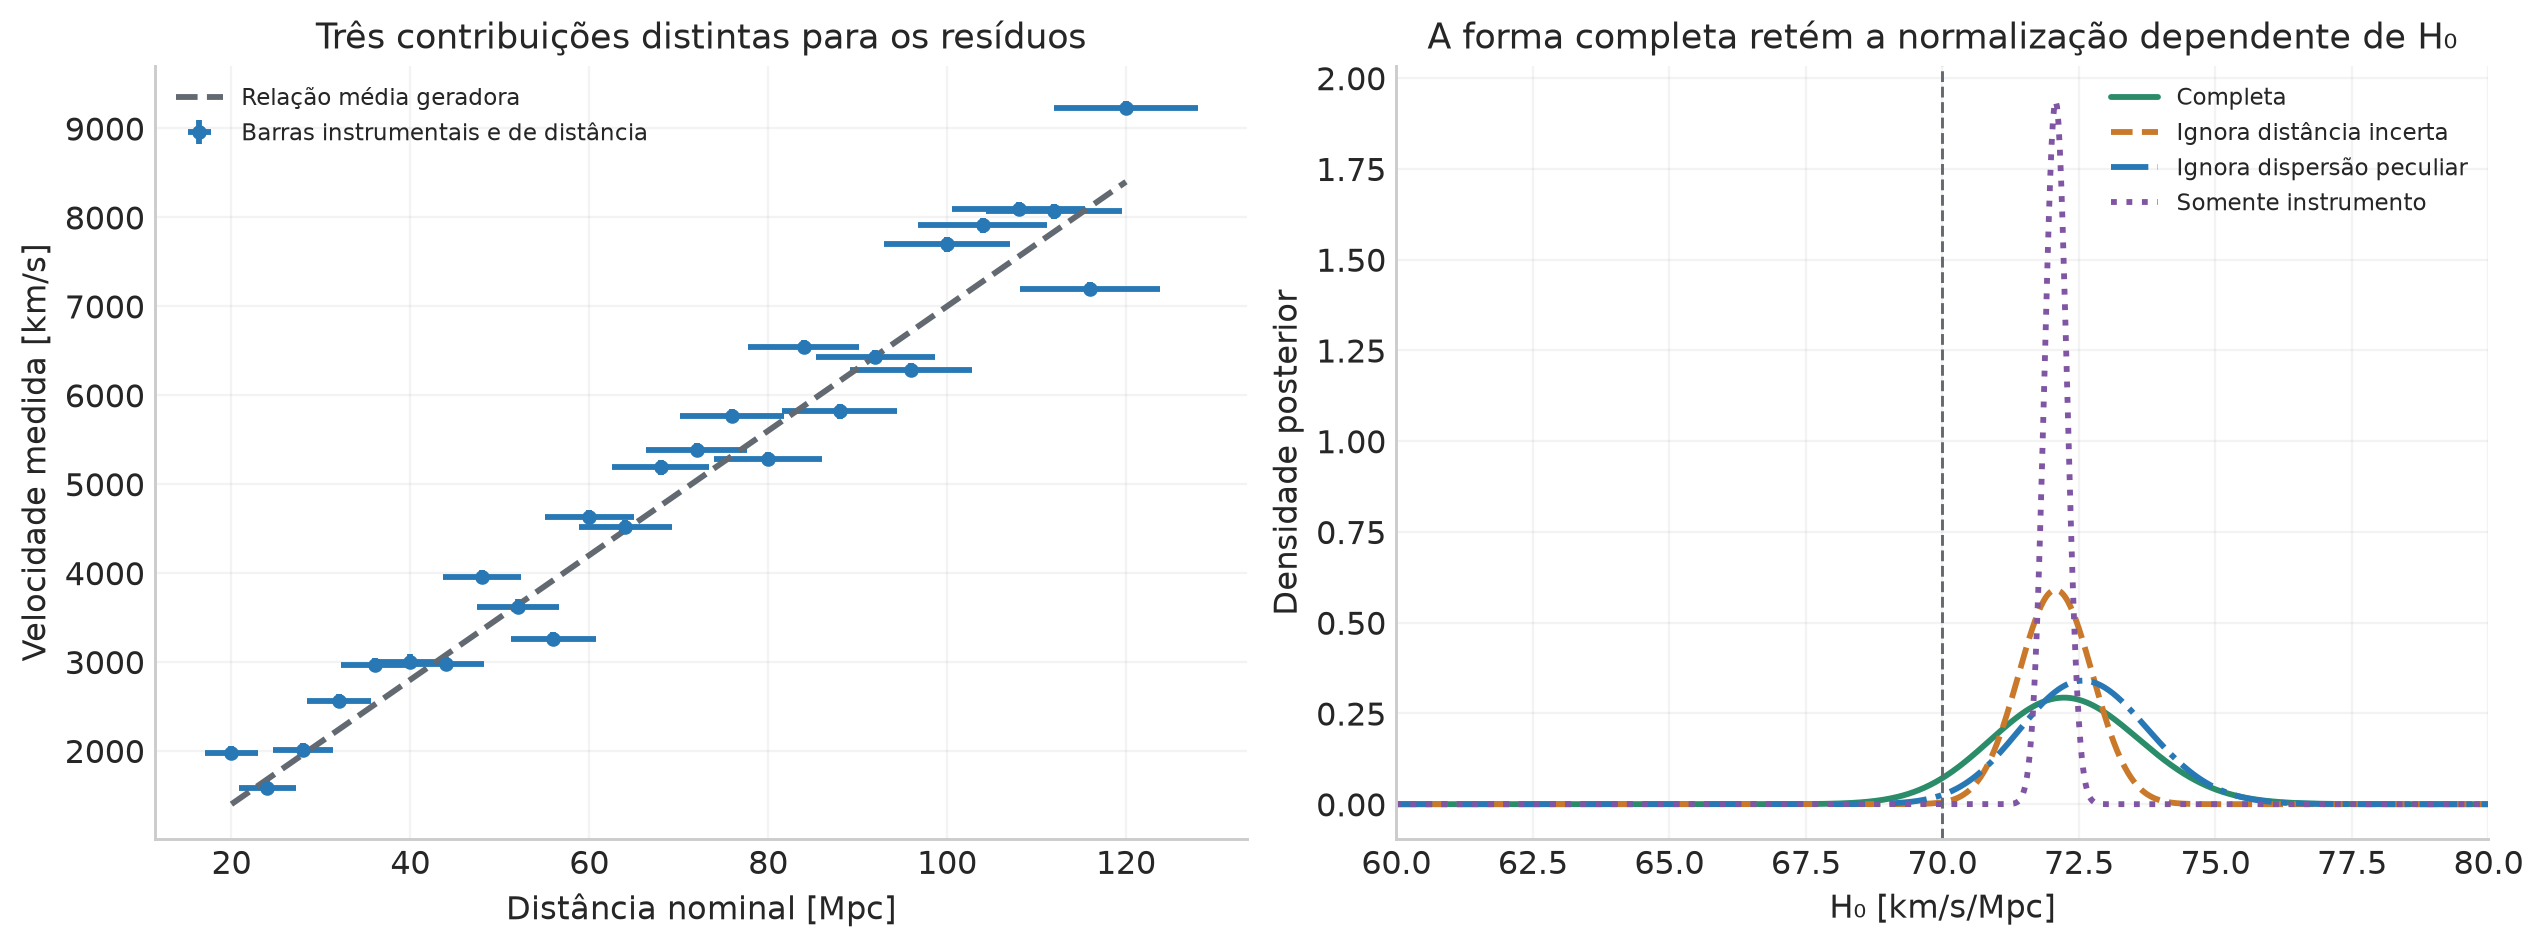

In [22]:
rng_h3 = np.random.default_rng(SEMENTE+10)
d0_h3 = np.linspace(20, 120, 26)
sd_h3 = np.linspace(3, 8, len(d0_h3))
sy_h3 = np.full(len(d0_h3), 80.0)
sv_h3 = 250.0
d_real_h3 = rng_h3.normal(d0_h3, sd_h3)
z_h3 = H0_verdade*d_real_h3+rng_h3.normal(0, sv_h3, len(d0_h3))
y_h3 = z_h3+rng_h3.normal(0, sy_h3)

posts_h3 = {}
for nome, sv, sd in [
    ('Completa', sv_h3, sd_h3),
    ('Ignora distância incerta', sv_h3, 0.0),
    ('Ignora dispersão peculiar', 0.0, sd_h3),
    ('Somente instrumento', 0.0, 0.0),
]:
    logl = loglike_hubble(H_grade, d0_h3, y_h3, sy_h3, sv, sd)
    posts_h3[nome] = normalizar_logdensidade(H_grade, logl)

linhas = []
for nome, post in posts_h3.items():
    media, moda, limites = resumo_densidade(H_grade, post)
    linhas.append([nome, f'{media:.3f}', f'[{limites[0]:.3f}, {limites[1]:.3f}]', f'{np.diff(limites)[0]:.3f}'])
tabela(['Análise', 'Média H₀', 'IC central 95% [km/s/Mpc]', 'Largura'], linhas)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4), layout='constrained')
ax[0].errorbar(d0_h3, y_h3, xerr=sd_h3, yerr=sy_h3, fmt='o', ms=4, color=AZUL, label='Barras instrumentais e de distância')
ax[0].plot(d0_h3, H0_verdade*d0_h3, '--', color=CINZA, label='Relação média geradora')
ax[0].set(xlabel='Distância nominal [Mpc]', ylabel='Velocidade medida [km/s]', title='Três contribuições distintas para os resíduos')
ax[0].legend(fontsize=8)
for (nome, post), cor, estilo in zip(posts_h3.items(), [VERDE, LARANJA, AZUL, ROXO], ['-', '--', '-.', ':']):
    ax[1].plot(H_grade, post, color=cor, ls=estilo, label=nome)
ax[1].axvline(H0_verdade, color=CINZA, ls='--', lw=1)
ax[1].set(xlim=(60, 80), xlabel='H₀ [km/s/Mpc]', ylabel='Densidade posterior', title='A forma completa retém a normalização dependente de H₀')
ax[1].legend(fontsize=8)
mostrar_figura(fig, '19_likelihood_caso3')

# Conferência da integral latente completa após integrar analiticamente os dois ruídos em y.
for i, H_teste in [(0, 67.0), (12, 70.0), (25, 73.0)]:
    s0 = np.hypot(sy_h3[i], sv_h3)
    quadratura = quad(
        lambda d: norm.pdf(d, d0_h3[i], sd_h3[i])*norm.pdf(y_h3[i], H_teste*d, s0),
        d0_h3[i]-10*sd_h3[i], d0_h3[i]+10*sd_h3[i], epsabs=1e-12
    )[0]
    analitica = norm.pdf(y_h3[i], H_teste*d0_h3[i], np.sqrt(s0**2+(H_teste*sd_h3[i])**2))
    conferir(f'Caso 3: integral sobre distância no ponto {i}', quadratura, analitica)

# Limites do homework: a função geral deve reduzir às outras construções.
ll_reta_h3 = loglike_reta(0, H_grade, d0_h3, y_h3, sy_h3, sd_h3, sv_h3)
conferir('Caso 3: duas implementações da likelihood', ll_reta_h3, loglike_hubble(H_grade, d0_h3, y_h3, sy_h3, sv_h3, sd_h3))
conferir('Limite σ_x=0', loglike_reta(0, H_grade, d_h1, y_h1, sigma_y_h1, 0, sigma_v_h1), logL_h1)

**Interpretação.** Na likelihood completa, a contribuição da distância é $H_0^2\sigma_{d,i}^2$. Por isso, variar $H_0$ muda simultaneamente a previsão média e a dispersão esperada. O dado não pode ser avaliado apenas pelo tamanho do resíduo; precisamos considerar quanta densidade o modelo atribui àquela região dos dados.


### 3.5 Previsão posterior: incerteza no parâmetro e dispersão de novos dados

Depois de construir a likelihood e inferir $H_0$, podemos prever uma **nova** medida em uma distância nominal $d_{*0}$, com incerteza $\sigma_{d,*}$. A densidade preditiva é
$$f(y_*\mid D)=\int f(y_*\mid H_0,I_*)\,\pi(H_0\mid D)\,dH_0.$$
Ela não é a posterior de $H_0$ e não é simplesmente a curva do modelo na média posterior. A lei da variância total mostra as duas contribuições:
$$\mathrm{Var}(Y_*\mid D)=\underbrace{\mathbb E[s_*^2(H_0)\mid D]}_{\text{dispersão de uma nova observação}}
+\underbrace{d_{*0}^2\mathrm{Var}(H_0\mid D)}_{\text{incerteza na relação média}}.$$

Vamos calcular a mistura por integração e conferir a variância por essa identidade. Isso evita adicionar a incerteza do parâmetro à likelihood original e contá-la duas vezes.

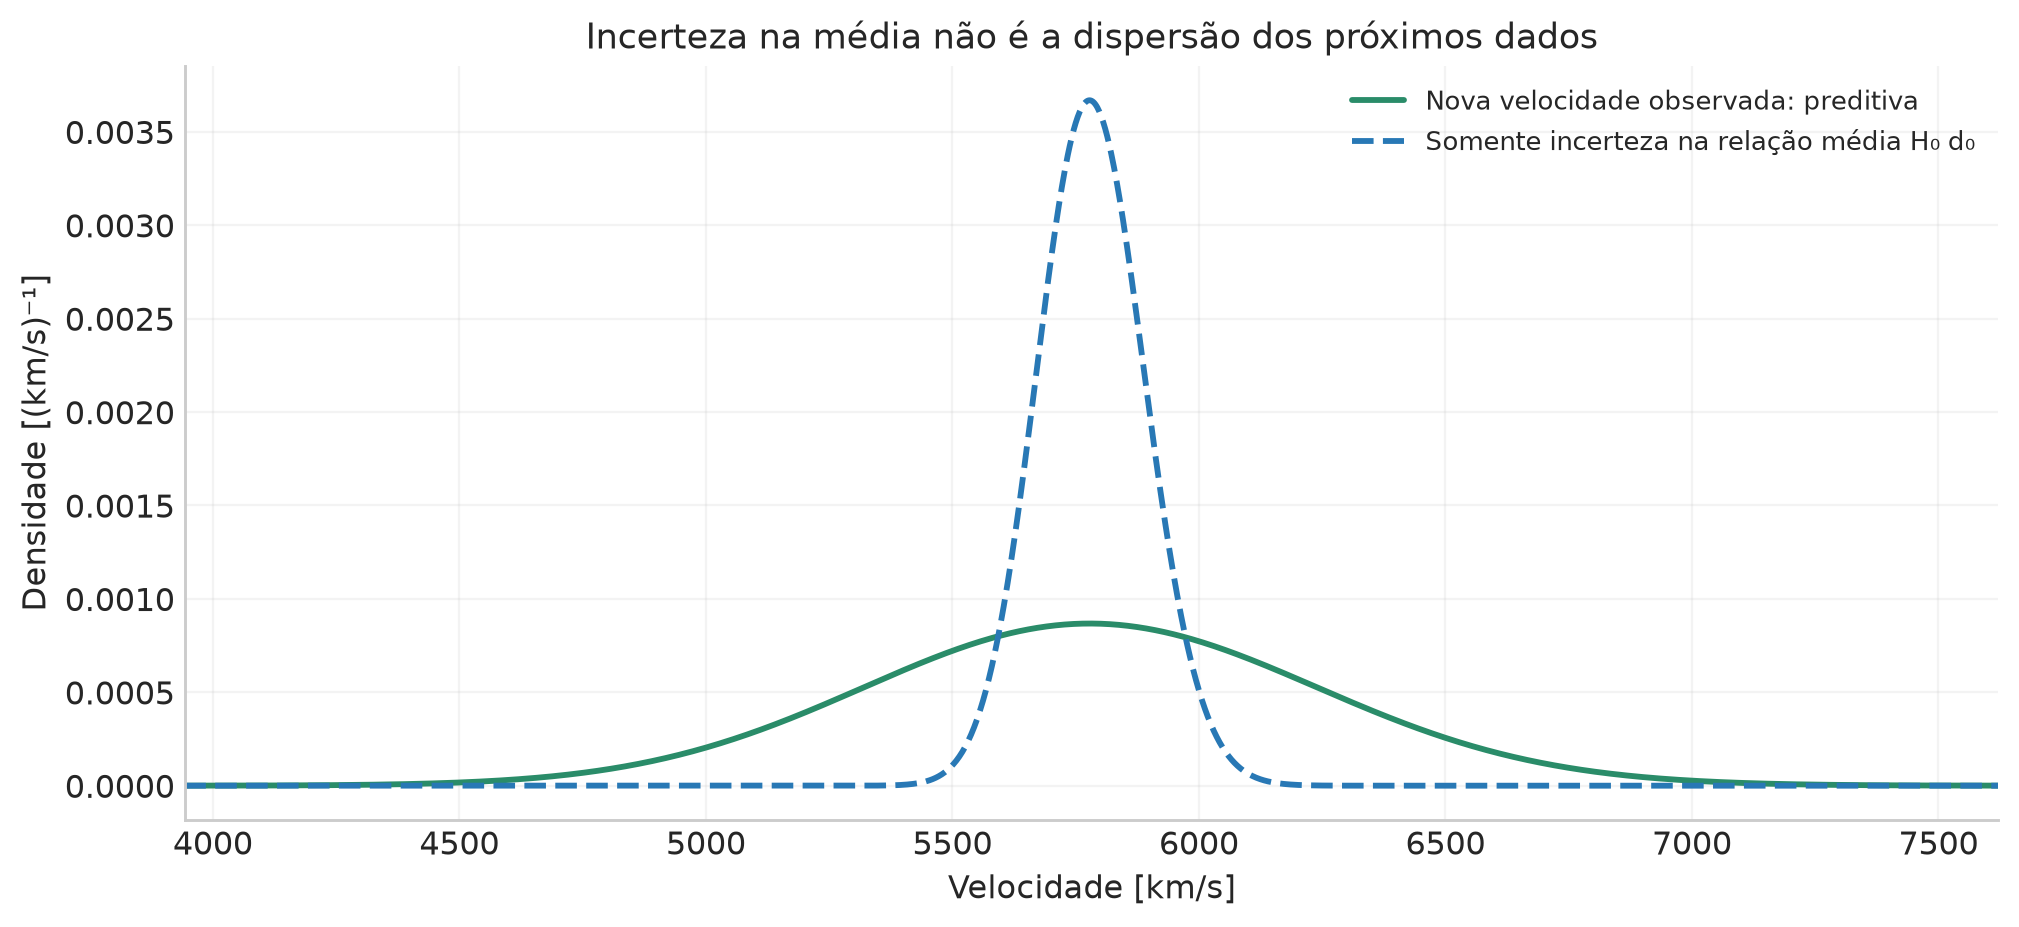

| Contribuição à variância preditiva | Valor [(km/s)²] |
| --- | --- |
| Dispersão média de nova observação | 199563.490 |
| Incerteza na relação média | 11853.679 |
| Total | 211417.168 |

In [23]:
post_h3 = posts_h3['Completa']
d_fut, sd_fut, sy_fut = 80.0, 5.0, 80.0
media_H = simpson(H_grade*post_h3, x=H_grade)
var_H = simpson((H_grade-media_H)**2*post_h3, x=H_grade)
s2_fut_H = sy_fut**2+sv_h3**2+(H_grade*sd_fut)**2
media_pred = d_fut*media_H
var_pred = simpson(s2_fut_H*post_h3, x=H_grade)+d_fut**2*var_H
y_fut_grade = np.linspace(media_pred-7*np.sqrt(var_pred), media_pred+7*np.sqrt(var_pred), 1401)
condicionais_fut = norm.pdf(y_fut_grade[:,None], d_fut*H_grade[None,:], np.sqrt(s2_fut_H)[None,:])
pred_fut = simpson(condicionais_fut*post_h3[None,:], x=H_grade, axis=1)
conferir('Preditiva: normalização', simpson(pred_fut, x=y_fut_grade), 1, atol=1e-7)
var_pred_integral = simpson((y_fut_grade-media_pred)**2*pred_fut, x=y_fut_grade)
conferir('Preditiva: lei da variância total', var_pred_integral, var_pred, rtol=2e-5)

# A distribuição da relação média g = d_fut H vem de outra mudança de variável.
media_relacao = d_fut*H_grade
pdf_relacao = post_h3/d_fut
fig, ax = plt.subplots(figsize=(9.5, 4.3), layout='constrained')
ax.plot(y_fut_grade, pred_fut, color=VERDE, label='Nova velocidade observada: preditiva')
ax.plot(media_relacao, pdf_relacao, color=AZUL, ls='--', label='Somente incerteza na relação média H₀ d₀')
ax.set(xlim=(media_pred-4*np.sqrt(var_pred), media_pred+4*np.sqrt(var_pred)), xlabel='Velocidade [km/s]', ylabel='Densidade [(km/s)⁻¹]', title='Incerteza na média não é a dispersão dos próximos dados')
ax.legend()
mostrar_figura(fig, '20_posterior_preditiva')
tabela(['Contribuição à variância preditiva', 'Valor [(km/s)²]'], [
    ['Dispersão média de nova observação', f'{simpson(s2_fut_H*post_h3, x=H_grade):.3f}'],
    ['Incerteza na relação média', f'{d_fut**2*var_H:.3f}'],
    ['Total', f'{var_pred:.3f}'],
])

### 3.6 Onde essas ideias aparecem em Peak Sirens e na análise de GW–galáxias?

No trabalho de Ferri et al. disponível no projeto, a informação cosmológica vem da correspondência entre faixas de distância de luminosidade de GW e faixas de redshift de galáxias, por meio da correlação angular. A seção 2.1 constrói a inferência a partir dos espectros e de sua covariância. O trabalho de Matos et al. aplica essa ideia a dados observacionais. Aqui estamos identificando as peças estatísticas que precisaremos dominar antes de reproduzir um pipeline desses.

| Conceito deste notebook | Conexão com a pesquisa | Hipótese que precisaremos verificar |
|:--|:--|:--|
| Poisson e seleção | Contagens e contribuição discreta (*shot noise*) | Intensidade, completude, máscaras e seleção; o campo possui estrutura |
| Binomial / multinomial condicionais | Alocação de um total entre regiões ou faixas | Probabilidades das regiões e efeito de fixar o total |
| $D_L\leftrightarrow z_{\rm cos}$ | Correspondência radial dependente da cosmologia | Modelo de expansão e distribuição de incertezas |
| Jacobianos e priors | Reparametrizar densidades ou reutilizar resultados de eventos | Uma posterior de evento inclui a prior usada na sua obtenção |
| Variável latente | Distâncias, posições ou propriedades não conhecidas exatamente | O que é marginalizado e quais distribuições descrevem essas quantidades |
| Likelihood e covariância | Comparar estatísticas observadas às previsões | Dependências entre faixas radiais e multipolos; validade da aproximação gaussiana |

Para visualizar a generalização dos exemplos escalares, empilhamos estatísticas observadas num vetor $\mathbf d$, por exemplo combinações selecionadas de $\widehat C_\ell^{\rm GW,g}(z_{\rm cos},D_L)$. Em uma aproximação gaussiana com covariância $C(\theta)$,
$$\ln L(\theta)=-\frac12[\mathbf d-\boldsymbol\mu(\theta)]^T C(\theta)^{-1}[\mathbf d-\boldsymbol\mu(\theta)]
-\frac12\ln\det C(\theta)-\frac{n_d}{2}\ln(2\pi).$$

O termo $\ln\det C$ é a versão matricial de $\sum_i\ln s_i^2$. Se a covariância for mantida fixa por uma aproximação explicitada, esse termo é constante na inferência dos parâmetros da média; se ela variar, não podemos descartá-lo automaticamente. A expressão acima é a forma gaussiana genérica, não uma transcrição de todas as convenções de índices e fatores do artigo.

Ferri et al. discutem correlações entre faixas radiais e o efeito da máscara sobre os modos angulares. Isso se conecta diretamente ao estudo de covariância do capítulo 3 e à transformação conjunta da Parte 2. Uma nova fonte de ruído pode exigir modificar uma matriz, não apenas aumentar um desvio padrão escalar.

## Fechamento do capítulo

O procedimento que levaremos adiante é: definir os dados e as hipóteses de geração; construir a distribuição condicional dos dados; marginalizar quantidades latentes; só então usar a prior para inferir os parâmetros. Quando transformamos variáveis, preservamos a probabilidade e acompanhamos o elemento de volume. Quando fazemos uma aproximação, declaramos seu regime de validade.

**Pontos para eu registrar com minhas palavras:**

1. Por que a binomial da moeda e a posterior do viés não são a mesma distribuição?
2. Por que fixar um total de Poisson muda o suporte e elimina a taxa da alocação temporal?
3. O que cada jacobiano corrige e por que o quadrado exige dois ramos?
4. Em cada exemplo físico, quem é $x_i$, quem é $z_i$, quem é $y_i$ e quais parâmetros estão em $\theta$?
5. Quando a incerteza deve entrar na likelihood e quando ela aparece apenas na posterior preditiva?

As células abaixo conferem as normalizações e resumem a execução. Os testes de identidades não substituem a leitura das hipóteses: uma fórmula pode estar numericamente correta e responder à pergunta errada.